In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os


In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as img

import cv2
import itertools
import pathlib
import warnings
from PIL import Image
from random import randint
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef as MCC
from sklearn.metrics import balanced_accuracy_score as BAS
from sklearn.metrics import classification_report, confusion_matrix


from tensorflow import keras
from keras import layers
import tensorflow as tf
#import tensorflow_addons as tfa
from tensorflow.keras.preprocessing import image_dataset_from_directory
##from keras.utils.vis_utils import plot_model
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv2D, Flatten
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IDG
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization, GlobalAveragePooling2D

from distutils.dir_util import copy_tree, remove_tree

import os
#print(os.listdir("../input/alzheimer-mri-dataset/Dataset"))

print("TensorFlow Version:", tf.__version__)

2026-05-15 05:44:49.185294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778823889.370638      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778823889.430044      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778823889.884097      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778823889.884136      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778823889.884139      57 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


In [3]:
import tensorflow as tf
from keras.datasets import mnist
import cv2
import os
import pathlib
from keras.layers import Conv2D, Conv2DTranspose, Dropout, Dense, Reshape, LayerNormalization, LeakyReLU
from keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import f1_score, recall_score, precision_score

In [4]:
class ReadDataset:
    def __init__(self, datasetpath, labels, image_shape):
        self.datasetpath = datasetpath
        self.labels = labels
        self.image_shape = image_shape
    def returListImages(self,):
        self.images = []
        for label in self.labels:
            self.images.append(list(pathlib.Path(os.path.join(self.datasetpath,
                                                              label)).glob('*.*')))
    def readImages(self,):
        self.returListImages()
        self.finalImages = []
        labels = []
        for label in range(len(self.labels)):
            for img in self.images[label]:
                img = cv2.imread(str(img))
                img = cv2.resize(img , self.image_shape)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img  = img/255
                self.finalImages.append(img)
                labels.append(label)
        images = np.array(self.finalImages)
        labels = np.array(labels)
        return images, labels
#/kaggle/input/alzheimer-mri-dataset/Dataset
readDatasetObject = ReadDataset('/kaggle/input/datasets/plameneduardo/sarscov2-ctscan-dataset',
                               ['COVID', 'non-COVID'],
                               (128,128))
images, labels = readDatasetObject.readImages()

images.shape, labels.shape

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)
X_train.shape,X_test.shape, y_train.shape,y_test.shape

((1984, 128, 128, 3), (497, 128, 128, 3), (1984,), (497,))

In [5]:
images_train = X_train
images_test = X_test

labels_train = y_train
labels_test = y_test

images_train.shape,images_test.shape, labels_train.shape,labels_test.shape

((1984, 128, 128, 3), (497, 128, 128, 3), (1984,), (497,))

In [6]:
import tensorflow as tf
from keras.datasets import mnist
import cv2
import os
import pathlib
from keras.layers import Conv2D, Conv2DTranspose, Dropout, Dense, Reshape, LayerNormalization, LeakyReLU
from keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import f1_score, recall_score, precision_score

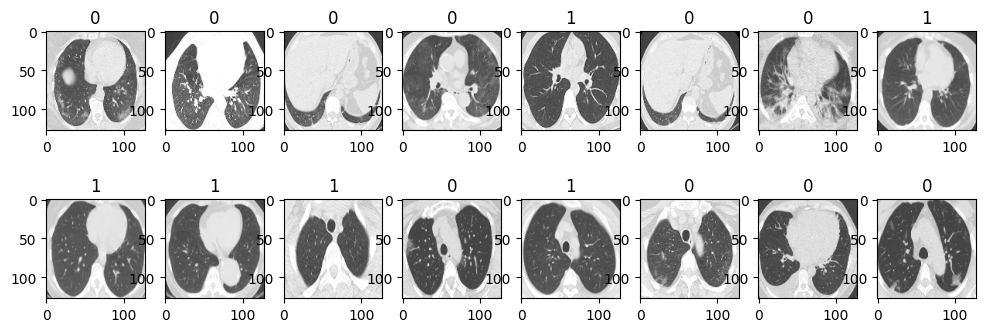

In [7]:
plt.figure(figsize = (12, 4))
for i in range(16):
    plt.subplot(2, 8, (i + 1))
    plt.imshow(images_train[i], cmap = 'gray')
    plt.title(labels_train[i])
plt.show()

In [8]:
from tensorflow.keras.utils import to_categorical
y_train_one_hot = to_categorical(labels_train)
y_train_one_hot.shape

(1984, 2)

In [9]:
from tensorflow.keras.utils import to_categorical
y_test_one_hot = to_categorical(labels_test)
y_test_one_hot.shape

(497, 2)

In [10]:
y_test_one_hot.shape, X_test.shape

((497, 2), (497, 128, 128, 3))

In [11]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Input shape
input_shape = (128, 128, 3)

# Load pre-trained MobileNet model
mobilenet_base = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Freeze MobileNet layers
mobilenet_base.trainable = False

# Define input
input_data = Input(shape=input_shape, name='input_data')

# Do NOT rescale here because preprocessing is already done
x = mobilenet_base(input_data, training=False)

# Classification head
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='selu')(x)

# Since y_train_one_hot is one-hot encoded, use softmax
output_layer = Dense(2, activation='softmax')(x)

# Create model
model1 = Model(inputs=input_data, outputs=output_layer)

# Compile model
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Checkpoint callback
checkpoint_callback = ModelCheckpoint(
    filepath='best_models1.keras',
    save_weights_only=False,
    save_freq='epoch',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Early stopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint_callback, early_stopping_callback]

# Train model
history = model1.fit(
    images_train,
    y_train_one_hot,
    epochs=100,
    callbacks=callbacks,
    validation_split=0.2,
    shuffle=True
)

I0000 00:00:1778823957.460129      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/100


I0000 00:00:1778823964.396864     110 service.cc:152] XLA service 0x7ca90c024140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778823964.396912     110 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778823965.080451     110 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778823969.500340     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6451 - loss: 1.2316
Epoch 1: val_loss improved from inf to 0.31327, saving model to best_models1.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - accuracy: 0.6469 - loss: 1.2228 - val_accuracy: 0.8741 - val_loss: 0.3133
Epoch 2/100
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8953 - loss: 0.2657
Epoch 2: val_loss improved from 0.31327 to 0.26064, saving model to best_models1.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8951 - loss: 0.2655 - val_accuracy: 0.9018 - val_loss: 0.2606
Epoch 3/100
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9258 - loss: 0.1932
Epoch 3: val_loss did not improve from 0.26064
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9256 - loss: 0.1934 - val_accuracy: 0.9043 - val_loss: 0.2690
Epoch 4/100
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9443 - loss: 0.1567
Epoch 4: val_loss improved from 0.26064 to 0.20839, saving model to best_models1.keras
50/50 ━━━━━━━━━━━

In [ ]:
# ============================================================
# TAC-CONCORD + pretrained ResNet50 for CIFAR-10
# Certified-only randomized defense across (sigma, radius)
#
# Assumes you already have:
#   X_train, y_train, X_test, y_test
#
# Uses your classifier:
#   ResNet50(weights='imagenet', include_top=False, input_shape=(96,96,3))
#   GlobalAveragePooling2D
#   Dense(256, relu)
#   Dropout(0.3)
#   Dense(10)
#
# Main outputs:
#   - trained TAC-CONCORD-ResNet50 model
#   - certified accuracy table across sigma and radius
#
# ============================================================

import os
import math
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.stats import beta as beta_dist
from scipy.stats import norm as normal_dist

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


# ============================================================
# 0. Reproducibility and data preparation
# ============================================================

SEED = 123
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

NUM_CLASSES = 2

'''def normalize_images_if_needed(X):
    X = X.astype("float32")
    if np.max(X) > 2.0:
        X = X / 255.0
    return X

def to_onehot(y, num_classes=10):
    y = np.asarray(y)
    if y.ndim == 2:
        return y.astype("float32")
    return tf.keras.utils.to_categorical(y.reshape(-1), num_classes).astype("float32")
'''

def labels_from_y(y):
    y = np.asarray(y)
    if y.ndim == 2:
        return np.argmax(y, axis=1).astype("int64")
    return y.reshape(-1).astype("int64")

X_train = images_train
    #normalize_images_if_needed(X_train)
X_test = X_test #normalize_images_if_needed(X_test)

y_train_oh = y_train_one_hot #to_onehot(y_train, NUM_CLASSES)
y_test_oh = y_test_one_hot  ##to_onehot(y_test, NUM_CLASSES)
y_test_labels = labels_from_y(y_test_one_hot)

INPUT_SHAPE = X_train.shape[1:]
TRAIN_MEAN = np.mean(X_train, axis=0, keepdims=True).astype("float32")

#print("X_train:", X_train.shape, X_train.dtype, "range:", float(X_train.min()), float(X_train.max()))
#print("X_test :", X_test.shape, X_test.dtype, "range:", float(X_test.min()), float(X_test.max()))
#print("y_train:", y_train_oh.shape)
#print("Input shape:", INPUT_SHAPE)


# ============================================================
# 1. Exact orthogonal color-tangent layer
# ============================================================

class OrthogonalColorTangent(layers.Layer):
    """
    Learnable 3x3 orthogonal color transformation using Cayley transform.

    If A is skew-symmetric:
        O = (I + A)^(-1)(I - A)

    is orthogonal, so it preserves L2 distances exactly.
    """

    def __init__(self, channels=3, init_scale=0.0, **kwargs):
        super().__init__(**kwargs)
        self.channels = int(channels)
        self.init_scale = float(init_scale)

    def build(self, input_shape):
        self.raw_A = self.add_weight(
            name="raw_skew_color_matrix",
            shape=(self.channels, self.channels),
            initializer=tf.keras.initializers.RandomNormal(stddev=self.init_scale),
            trainable=True,
        )

    def get_orthogonal_matrix(self):
        A = self.raw_A - tf.transpose(self.raw_A)
        I = tf.eye(self.channels, dtype=A.dtype)
        O = tf.linalg.solve(I + A, I - A)
        return O

    def call(self, x):
        O = self.get_orthogonal_matrix()
        return tf.einsum("bhwc,cd->bhwd", x, O)


# ============================================================
# 2. Certified stochastic coalescent flow
# ============================================================

class TACCoalescentFlow(layers.Layer):
    """
    Certified OU-style stochastic coalescent flow.

    Per step:
        x_{k+1} = mean + a * (x_k - mean) + step_noise * eps

    with:
        a = exp(-lambda_cert * dt)

    Then an optional orthogonal color-tangent map is applied.
    This preserves L2 distances and therefore does not weaken the certificate.

    The terminal distribution is Gaussian around a contracted version of x.
    The certified radius later uses the exact coalescence/TV formula.
    """

    def __init__(
        self,
        train_mean,
        T=1.0,
        steps=8,
        lambda_cert=1.0,
        use_color_tangent=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.T = float(T)
        self.steps = int(steps)
        self.lambda_cert = float(lambda_cert)
        self.use_color_tangent = bool(use_color_tangent)

        self.dt = self.T / self.steps
        self.train_mean_np = train_mean.astype("float32")
        self.train_mean = tf.constant(self.train_mean_np, dtype=tf.float32)

        if self.use_color_tangent:
            self.color_tangent = OrthogonalColorTangent(
                channels=int(train_mean.shape[-1]),
                init_scale=0.0,
                name="orthogonal_color_tangent",
            )
        else:
            self.color_tangent = None

    def step_noise_std_and_a(self, sigma):
        sigma = tf.cast(sigma, tf.float32)

        if self.lambda_cert > 0:
            a = tf.exp(tf.constant(-self.lambda_cert * self.dt, dtype=tf.float32))
            var = sigma ** 2 * (1.0 - a ** 2) / (2.0 * self.lambda_cert)
            return tf.sqrt(tf.maximum(var, 1e-12)), a

        a = tf.constant(1.0, dtype=tf.float32)
        var = sigma ** 2 * self.dt
        return tf.sqrt(tf.maximum(var, 1e-12)), a

    def call(self, x, sigma, training=False):
        x = tf.cast(x, tf.float32)
        sigma = tf.cast(sigma, tf.float32)

        step_std, a = self.step_noise_std_and_a(sigma)

        z = x
        for _ in range(self.steps):
            eps = tf.random.normal(tf.shape(z), dtype=z.dtype)

            z = self.train_mean + a * (z - self.train_mean) + step_std * eps

            if self.color_tangent is not None:
                centered = z - self.train_mean
                centered = self.color_tangent(centered)
                z = self.train_mean + centered

        return z


# ============================================================
# 3. Your pretrained ResNet50 classifier
# ============================================================

class ResNet50CIFARClassifier(tf.keras.Model):
    """
    Your requested classifier:

        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(96,96,3)
        )

        GlobalAveragePooling2D()
        Dense(256, activation='relu')
        Dropout(0.3)
        Dense(10)

    This model returns logits. TAC-CONCORD applies softmax outside.

    If your X_train is 32x32, this internally resizes to 96x96.
    If your X_train is already 96x96, this still works.
    """

    def __init__(
        self,
        num_classes=2,
        resnet_input_shape=(128, 128, 3),
        dense_units=256,
        dropout_rate=0.3,
        train_backbone=False,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.num_classes = int(num_classes)
        self.resnet_input_shape = tuple(resnet_input_shape)
        self.dense_units = int(dense_units)
        self.dropout_rate = float(dropout_rate)
        self.train_backbone = bool(train_backbone)

        self.base_model = ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=self.resnet_input_shape,
        )

        self.base_model.trainable = self.train_backbone

        self.gap = layers.GlobalAveragePooling2D(name="global_average_pooling")
        self.fc = layers.Dense(256, activation="relu", name="dense_256")
        self.dropout = layers.Dropout(0.3, name="dropout_03")
        self.logits_layer = layers.Dense(num_classes, activation="sigmoid", name="class_logits")

    def call(self, x, training=False):
        x = tf.cast(x, tf.float32)

        # Classifier-side deterministic post-processing.
        x = tf.clip_by_value(x, 0.0, 1.0)

        # Your ResNet50 expects 96x96 input.
        x = tf.image.resize(x, (96, 96), method="bilinear")

        # ImageNet ResNet50 preprocessing.
        x = x * 255.0
        x = preprocess_input(x)

        backbone_training = bool(training and self.base_model.trainable)

        x = self.base_model(x, training=backbone_training)
        x = self.gap(x)
        x = self.fc(x)
        x = self.dropout(x, training=training)

        logits = self.logits_layer(x)
        return logits


# ============================================================
# 4. TAC-CONCORD model with pretrained ResNet50
# ============================================================

class TACConcordResNet50Model(tf.keras.Model):
    """
    Full model:

        image x
          -> TAC stochastic coalescent flow
          -> pretrained ResNet50 classifier
          -> class probabilities

    This model uses custom train_step/test_step to train with:
        - CE loss
        - consistency loss across two stochastic trajectories
        - probability-gap loss for certification
    """

    def __init__(
        self,
        input_shape,
        train_mean,
        num_classes=10,
        T=1.0,
        steps=8,
        lambda_cert=1.0,
        sigma_train_values=(0.12, 0.25, 0.50),
        eval_sigma=0.25,
        consistency_weight=0.10,
        gap_weight=0.25,
        target_gap=0.50,
        train_backbone=False,
        use_color_tangent=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.num_classes = int(num_classes)
        self.T = float(T)
        self.steps = int(steps)
        self.lambda_cert = float(lambda_cert)

        self.consistency_weight = float(consistency_weight)
        self.gap_weight = float(gap_weight)
        self.target_gap = float(target_gap)

        self.sigma_train_values = tf.constant(sigma_train_values, dtype=tf.float32)
        self.eval_sigma = tf.Variable(float(eval_sigma), trainable=False, dtype=tf.float32)

        self.flow = TACCoalescentFlow(
            train_mean=train_mean,
            T=T,
            steps=steps,
            lambda_cert=lambda_cert,
            use_color_tangent=use_color_tangent,
            name="tac_coalescent_flow",
        )

        self.classifier = ResNet50CIFARClassifier(
            num_classes=num_classes,
            resnet_input_shape=(96, 96, 3),
            dense_units=256,
            dropout_rate=0.3,
            train_backbone=train_backbone,
            name="pretrained_resnet50_classifier",
        )

        # Custom metrics
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.ce_tracker = tf.keras.metrics.Mean(name="ce")
        self.consistency_tracker = tf.keras.metrics.Mean(name="consistency")
        self.margin_tracker = tf.keras.metrics.Mean(name="margin_loss")
        self.acc_metric = tf.keras.metrics.CategoricalAccuracy(name="accuracy")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.ce_tracker,
            self.consistency_tracker,
            self.margin_tracker,
            self.acc_metric,
        ]

    def set_eval_sigma(self, sigma):
        self.eval_sigma.assign(float(sigma))

    def sample_training_sigma(self):
        idx = tf.random.uniform(
            shape=[],
            minval=0,
            maxval=tf.shape(self.sigma_train_values)[0],
            dtype=tf.int32,
        )
        return tf.gather(self.sigma_train_values, idx)

    def call(self, inputs, training=False, sigma=None):
        if sigma is None:
            if training:
                sigma = self.sample_training_sigma()
            else:
                sigma = self.eval_sigma

        x_t = self.flow(inputs, sigma=sigma, training=training)
        logits = self.classifier(x_t, training=training)
        probs = tf.nn.softmax(logits, axis=-1)
        return probs

    def _margin_loss(self, y_true, probs):
        true_prob = tf.reduce_sum(y_true * probs, axis=-1)

        other_probs = probs - 1e6 * y_true
        max_other = tf.reduce_max(other_probs, axis=-1)

        gap = true_prob - max_other
        return tf.reduce_mean(tf.nn.relu(self.target_gap - gap))

    def train_step(self, data):
        x, y, sample_weight = tf.keras.utils.unpack_x_y_sample_weight(data)
        y = tf.cast(y, tf.float32)

        # Use same sigma for both trajectories in this batch.
        sigma = self.sample_training_sigma()

        with tf.GradientTape() as tape:
            p1 = self(x, training=True, sigma=sigma)
            p2 = self(x, training=True, sigma=sigma)

            ce1 = tf.keras.losses.categorical_crossentropy(y, p1)
            ce2 = tf.keras.losses.categorical_crossentropy(y, p2)
            ce = tf.reduce_mean(0.5 * (ce1 + ce2))

            consistency = tf.reduce_mean(tf.square(p1 - p2))

            margin_loss = 0.5 * (
                self._margin_loss(y, p1) +
                self._margin_loss(y, p2)
            )

            loss = (
                ce
                + self.consistency_weight * consistency
                + self.gap_weight * margin_loss
            )

            if self.losses:
                loss += tf.add_n(self.losses)

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.ce_tracker.update_state(ce)
        self.consistency_tracker.update_state(consistency)
        self.margin_tracker.update_state(margin_loss)
        self.acc_metric.update_state(y, p1, sample_weight=sample_weight)

        return {
            "loss": self.loss_tracker.result(),
            "ce": self.ce_tracker.result(),
            "consistency": self.consistency_tracker.result(),
            "margin_loss": self.margin_tracker.result(),
            "accuracy": self.acc_metric.result(),
            "sigma": sigma,
        }

    def test_step(self, data):
        x, y, sample_weight = tf.keras.utils.unpack_x_y_sample_weight(data)
        y = tf.cast(y, tf.float32)

        p = self(x, training=False, sigma=self.eval_sigma)

        ce = tf.keras.losses.categorical_crossentropy(y, p)
        ce = tf.reduce_mean(ce)

        margin_loss = self._margin_loss(y, p)

        loss = ce + self.gap_weight * margin_loss

        self.loss_tracker.update_state(loss)
        self.ce_tracker.update_state(ce)
        self.consistency_tracker.update_state(0.0)
        self.margin_tracker.update_state(margin_loss)
        self.acc_metric.update_state(y, p, sample_weight=sample_weight)

        return {
            "loss": self.loss_tracker.result(),
            "ce": self.ce_tracker.result(),
            "consistency": self.consistency_tracker.result(),
            "margin_loss": self.margin_tracker.result(),
            "accuracy": self.acc_metric.result(),
        }


# ============================================================
# 5. Build and train TAC-CONCORD-ResNet50
# ============================================================

tf.keras.backend.clear_session()

# Certified-flow hyperparameters
T_FLOW = 1.0
FLOW_STEPS = 8
LAMBDA_CERT = 1.0

# Noise levels used during training.
SIGMA_TRAIN_VALUES = (0.12, 0.25, 0.50)

# ResNet50 is heavy. Use batch size 8 like your original code.
BATCH_SIZE = 8

model = TACConcordResNet50Model(
    input_shape=INPUT_SHAPE,
    train_mean=TRAIN_MEAN,
    num_classes=NUM_CLASSES,
    T=T_FLOW,
    steps=FLOW_STEPS,
    lambda_cert=LAMBDA_CERT,
    sigma_train_values=SIGMA_TRAIN_VALUES,
    eval_sigma=0.25,
    consistency_weight=0.10,
    gap_weight=0.25,
    target_gap=0.50,
    train_backbone=False,
    use_color_tangent=True,
    name="TAC_CONCORD_RESNET50",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5)
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    mode="min",
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=15,
    mode="min",
    min_lr=1e-6,
    verbose=1,
)

checkpoint_path = "/kaggle/working/best_tac_concord_resnet50.weights.h5"

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1,
)

history = model.fit(
    X_train,
    y_train_oh,
    epochs=200,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint, reduce_lr, early_stop],
    verbose=1,
)

if os.path.exists(checkpoint_path):
    model.load_weights(checkpoint_path)
    print("Loaded best weights:", checkpoint_path)


# ============================================================
# 6. Optional fine-tuning of ResNet50 backbone
# ============================================================

RUN_FINE_TUNING = False

if RUN_FINE_TUNING:
    model.classifier.base_model.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6)
    )

    fine_tune_checkpoint_path = "/kaggle/working/best_tac_concord_resnet50_finetuned.weights.h5"

    fine_tune_checkpoint = ModelCheckpoint(
        filepath=fine_tune_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1,
    )

    history_ft = model.fit(
        X_train,
        y_train_oh,
        epochs=50,
        validation_split=0.2,
        batch_size=BATCH_SIZE,
        callbacks=[fine_tune_checkpoint, reduce_lr, early_stop],
        verbose=1,
    )

    if os.path.exists(fine_tune_checkpoint_path):
        model.load_weights(fine_tune_checkpoint_path)
        print("Loaded best fine-tuned weights:", fine_tune_checkpoint_path)


# ============================================================
# 7. Certified coalescence radius utilities
# ============================================================

def S_T_lambda(T, lambda_cert):
    T = float(T)
    lambda_cert = float(lambda_cert)

    if lambda_cert > 0:
        return (math.exp(2.0 * lambda_cert * T) - 1.0) / (2.0 * lambda_cert)

    return T

def q_tac_noncoalescence(r, sigma, T, lambda_cert):
    """
    q(r) = upper bound on probability that two coupled trajectories
    may fail to coalesce by time T.

    q(r) = 2 Phi( r / [2 sigma sqrt(S_T)] ) - 1
    """
    S = S_T_lambda(T, lambda_cert)
    denom = 2.0 * float(sigma) * math.sqrt(S)
    val = float(r) / max(denom, 1e-12)
    return 2.0 * normal_dist.cdf(val) - 1.0

def tac_certified_radius_from_gap(gap, sigma, T, lambda_cert):
    """
    Certified radius from probability gap:

        gap = pA_lower - pB_upper

    Certificate condition:

        gap > 2 q(r)

    Closed form:

        R = 2 sigma sqrt(S_T) Phi^{-1}(0.5 + gap/4)
    """
    gap = float(gap)

    if gap <= 0:
        return 0.0

    gap = min(max(gap, 0.0), 0.999999)
    arg = 0.5 + gap / 4.0

    S = S_T_lambda(T, lambda_cert)
    R = 2.0 * float(sigma) * math.sqrt(S) * normal_dist.ppf(arg)

    if not np.isfinite(R):
        return 0.0

    return max(0.0, float(R))

def binom_lower_confidence(k, n, alpha):
    """
    One-sided Clopper-Pearson lower bound.
    """
    k = int(k)
    n = int(n)

    if k <= 0:
        return 0.0

    return float(beta_dist.ppf(alpha, k, n - k + 1))

def binom_upper_confidence(k, n, alpha):
    """
    One-sided Clopper-Pearson upper bound.
    """
    k = int(k)
    n = int(n)

    if k >= n:
        return 1.0

    return float(beta_dist.ppf(1.0 - alpha, k + 1, n - k))


# ============================================================
# 8. Monte Carlo prediction counts
# ============================================================

def collect_mc_counts(
    model,
    X,
    sigma,
    n_samples,
    batch_size=16,
    num_classes=10,
    verbose=True,
):
    """
    Collect class counts under TAC-CONCORD stochastic trajectories.

    For each MC sample:
        X -> stochastic flow at sigma -> ResNet50 classifier -> predicted class

    Returns:
        counts: int array [N, num_classes]
    """
    X = X.astype("float32")
    n = len(X)

    counts = np.zeros((n, num_classes), dtype=np.int32)

    model.set_eval_sigma(sigma)

    for s in range(n_samples):
        if verbose and ((s + 1) % max(1, n_samples // 10) == 0 or s == 0):
            print(f"  MC sample {s + 1}/{n_samples} for sigma={sigma}")

        all_preds = []

        for start in range(0, n, batch_size):
            xb = X[start:start + batch_size]

            probs = model(
                tf.convert_to_tensor(xb, dtype=tf.float32),
                training=False,
                sigma=tf.constant(float(sigma), dtype=tf.float32),
            ).numpy()

            preds = np.argmax(probs, axis=1)
            all_preds.append(preds)

        all_preds = np.concatenate(all_preds, axis=0)

        rows = np.arange(n)
        counts[rows, all_preds] += 1

    return counts


# ============================================================
# 9. Certified accuracy evaluation
# ============================================================

def certify_dataset_tac_concord(
    model,
    X,
    y,
    sigma,
    radii_grid=(0.25, 0.50, 0.75, 1.00, 1.25, 1.50),
    N0=100,
    N=1000,
    alpha=0.001,
    batch_size=16,
    num_classes=10,
    T=1.0,
    lambda_cert=1.0,
    verbose=True,
):
    """
    Certified-only evaluation.

    1. N0 samples select top class A.
    2. N fresh samples estimate pA and pB.
    3. Clopper-Pearson confidence bounds.
    4. Convert probability gap into certified radius.
    5. Report certified robust accuracy at each radius.

    alpha is per-example failure probability.
    """

    X = X.astype("float32")
    labels = labels_from_y(y)
    n = len(X)

    print("\n================================================")
    print(f"Certifying sigma={sigma}, N0={N0}, N={N}, alpha={alpha}")
    print("================================================")

    print("Selection sampling...")
    counts_select = collect_mc_counts(
        model=model,
        X=X,
        sigma=sigma,
        n_samples=N0,
        batch_size=batch_size,
        num_classes=num_classes,
        verbose=verbose,
    )

    selected_class = np.argmax(counts_select, axis=1)

    print("Certification sampling...")
    counts_cert = collect_mc_counts(
        model=model,
        X=X,
        sigma=sigma,
        n_samples=N,
        batch_size=batch_size,
        num_classes=num_classes,
        verbose=verbose,
    )

    preds = selected_class.copy()
    radii = np.zeros(n, dtype=np.float64)
    pA_lowers = np.zeros(n, dtype=np.float64)
    pB_uppers = np.zeros(n, dtype=np.float64)
    gaps = np.zeros(n, dtype=np.float64)

    # Bonferroni split:
    # alpha/2 for pA lower,
    # alpha/(2*(K-1)) for each competitor upper.
    alpha_A = alpha / 2.0
    alpha_B_each = alpha / (2.0 * max(1, num_classes - 1))

    for i in range(n):
        A = int(selected_class[i])
        kA = int(counts_cert[i, A])

        pA_lower = binom_lower_confidence(kA, N, alpha_A)

        pB_upper = 0.0

        for c in range(num_classes):
            if c == A:
                continue

            kc = int(counts_cert[i, c])
            pB_upper_c = binom_upper_confidence(kc, N, alpha_B_each)
            pB_upper = max(pB_upper, pB_upper_c)

        gap = pA_lower - pB_upper

        R = tac_certified_radius_from_gap(
            gap=gap,
            sigma=sigma,
            T=T,
            lambda_cert=lambda_cert,
        )

        pA_lowers[i] = pA_lower
        pB_uppers[i] = pB_upper
        gaps[i] = gap
        radii[i] = R

    correct = preds == labels
    mc_clean_acc = float(np.mean(correct))

    cert_acc = {}

    for r in radii_grid:
        cert_acc[float(r)] = float(np.mean(correct & (radii >= float(r))))

    result = {
        "sigma": float(sigma),
        "T": float(T),
        "lambda_cert": float(lambda_cert),
        "N0": int(N0),
        "N": int(N),
        "alpha": float(alpha),
        "preds": preds,
        "radii": radii,
        "pA_lowers": pA_lowers,
        "pB_uppers": pB_uppers,
        "gaps": gaps,
        "mc_clean_accuracy": mc_clean_acc,
        "certified_accuracy": cert_acc,
    }

    print("\nResult for sigma =", sigma)
    print("MC clean accuracy:", mc_clean_acc)

    for r, acc in cert_acc.items():
        print(f"  CertAcc radius {r:.2f}: {acc:.4f}")

    return result

def make_cert_table(results, radii_grid):
    rows = []

    for res in results:
        row = {
            "sigma": res["sigma"],
            "T": res["T"],
            "lambda": res["lambda_cert"],
            "MC_clean_acc": res["mc_clean_accuracy"],
        }

        for r in radii_grid:
            row[f"CertAcc@{r}"] = res["certified_accuracy"][float(r)]

        rows.append(row)

    return pd.DataFrame(rows)

def best_over_sigma_table(results, radii_grid):
    row = {}

    for r in radii_grid:
        row[f"BestCertAcc@{r}"] = max(
            res["certified_accuracy"][float(r)] for res in results
        )

    return pd.DataFrame([row])


# ============================================================
# 10. Run certified evaluation
# ============================================================

RADIUS_GRID = (0.25, 0.50, 0.75, 1.00, 1.25, 1.50)
SIGMAS_TO_EVAL = (0.12, 0.25, 0.50, 1.00)

# ------------------------------------------------------------
# Pilot setting for Kaggle speed.
# For final paper-style results, use full X_test and larger N.
# ------------------------------------------------------------

CERT_SUBSET = min(1000, len(X_test))
CERT_X = X_test[:CERT_SUBSET]
CERT_Y = y_test_labels[:CERT_SUBSET]

N0_CERT = 100
N_CERT = 1000
ALPHA_CERT = 0.001

# For final stronger numbers, use:
#
# CERT_X = X_test
# CERT_Y = y_test_labels
# N0_CERT = 100
# N_CERT = 10000
# ALPHA_CERT = 0.001

all_results = []

for sig in SIGMAS_TO_EVAL:
    res = certify_dataset_tac_concord(
        model=model,
        X=CERT_X,
        y=CERT_Y,
        sigma=sig,
        radii_grid=RADIUS_GRID,
        N0=N0_CERT,
        N=N_CERT,
        alpha=ALPHA_CERT,
        batch_size=16,
        num_classes=NUM_CLASSES,
        T=T_FLOW,
        lambda_cert=LAMBDA_CERT,
        verbose=True,
    )

    all_results.append(res)

cert_table = make_cert_table(all_results, RADIUS_GRID)
best_table = best_over_sigma_table(all_results, RADIUS_GRID)

print("\n==============================")
print("TAC-CONCORD-ResNet50 certified table")
print("==============================")
display(cert_table)

print("\n==============================")
print("Best over sigma")
print("==============================")
display(best_table)

cert_table_path = "/kaggle/working/tac_concord_resnet50_cert_table.csv"
best_table_path = "/kaggle/working/tac_concord_resnet50_best_over_sigma.csv"

cert_table.to_csv(cert_table_path, index=False)
best_table.to_csv(best_table_path, index=False)

print("Saved:")
print(cert_table_path)
print(best_table_path)


# ============================================================
# 11. Optional radius distribution inspection
# ============================================================

for res in all_results:
    sig = res["sigma"]
    radii = res["radii"]

    print(f"\nSigma={sig}")
    print("Mean radius:", float(np.mean(radii)))
    print("Median radius:", float(np.median(radii)))
    print("90th percentile radius:", float(np.percentile(radii, 90)))
    print("Max radius:", float(np.max(radii)))

In [12]:
import math
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import tensorflow as tf

TensorLike = Union[tf.Tensor, np.ndarray]


# ============================================================
# CA-NCHA helpers
# ============================================================

def labels_to_int(labels: TensorLike) -> tf.Tensor:
    """
    Accept sparse labels [B] or one-hot labels [B,C].
    Return integer labels [B].
    """
    y = tf.convert_to_tensor(labels)

    if y.shape.rank is not None and y.shape.rank >= 2:
        return tf.cast(tf.argmax(y, axis=-1), tf.int32)

    return tf.cast(tf.reshape(y, [-1]), tf.int32)


def _flat(x: tf.Tensor) -> tf.Tensor:
    return tf.reshape(x, [tf.shape(x)[0], -1])


def _flat_dot(a: tf.Tensor, b: tf.Tensor) -> tf.Tensor:
    return tf.reduce_sum(_flat(a * b), axis=1)


def _flat_l2_sq(x: tf.Tensor) -> tf.Tensor:
    return tf.reduce_sum(tf.square(_flat(x)), axis=1)


def _flat_l2_norm(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    return tf.sqrt(tf.maximum(_flat_l2_sq(x), tf.cast(eps, x.dtype)))


def _normalize_l2(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    n = _flat_l2_norm(x, eps)
    return x / tf.reshape(n, [-1, 1, 1, 1])


def _rms_scale(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    """
    Per-sample RMS scale for image-like tensors [B,H,W,C].
    """
    return tf.sqrt(
        tf.maximum(
            tf.reduce_mean(tf.square(x), axis=[1, 2, 3], keepdims=True),
            tf.cast(eps, x.dtype)
        )
    )


def _normalize_rms(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    return x / _rms_scale(x, eps)


def _smooth_box_direction(x: tf.Tensor) -> tf.Tensor:
    """
    Smooth bounded direction in [-1,1].
    This avoids directly using sign(direction).
    """
    return tf.tanh(_normalize_rms(x))


def _safe_float(x: Any, default: float = float("nan")) -> float:
    try:
        if isinstance(x, tf.Tensor):
            return float(x.numpy())
        return float(x)
    except Exception:
        return default


def project_perturbation(
    x0: tf.Tensor,
    x: tf.Tensor,
    eps: float,
    norm: str = "linf",
    input_min: float = -1.0,
    input_max: float = 1.0,
) -> tf.Tensor:
    """
    Project x into an eps-ball around x0, then clip to the valid input domain.
    """
    x0 = tf.cast(x0, tf.float32)
    x = tf.cast(x, tf.float32)

    eps_t = tf.cast(eps, x.dtype)
    delta = x - x0
    n = norm.lower()

    if n in ("linf", "l_inf", "inf"):
        delta = tf.clip_by_value(delta, -eps_t, eps_t)

    elif n in ("l2", "2"):
        dnorm = _flat_l2_norm(delta)
        factor = tf.minimum(
            tf.ones_like(dnorm),
            eps_t / tf.maximum(dnorm, tf.cast(1e-12, x.dtype))
        )
        delta = delta * tf.reshape(factor, [-1, 1, 1, 1])

    else:
        raise ValueError(f"Unsupported norm: {norm}. Use 'linf' or 'l2'.")

    return tf.clip_by_value(
        x0 + delta,
        tf.cast(input_min, x.dtype),
        tf.cast(input_max, x.dtype)
    )


def model_scores_and_probs(
    model_outputs: tf.Tensor,
    outputs_are_probabilities: bool = True,
    eps: float = 1e-8,
) -> Tuple[tf.Tensor, tf.Tensor]:
    """
    Return differentiable scores and probabilities.

    If model output is softmax probabilities:
        scores = log(probabilities)

    If model output is logits:
        scores = logits
    """
    out = tf.cast(model_outputs, tf.float32)

    if outputs_are_probabilities:
        probs = tf.clip_by_value(out, eps, 1.0)
        probs = probs / tf.reduce_sum(probs, axis=1, keepdims=True)
        scores = tf.math.log(probs)
        return scores, probs

    scores = out
    probs = tf.nn.softmax(scores, axis=1)
    return scores, probs


def _masked_scores_except(
    scores: tf.Tensor,
    labels: tf.Tensor,
    fill: float = -1e9
) -> tf.Tensor:
    labels = tf.cast(tf.reshape(labels, [-1]), tf.int32)
    c = tf.shape(scores)[-1]

    mask = tf.one_hot(
        labels,
        c,
        dtype=tf.bool,
        on_value=True,
        off_value=False
    )

    return tf.where(
        mask,
        tf.cast(fill, scores.dtype) * tf.ones_like(scores),
        scores
    )


def _topk_excluding_adaptive(
    scores: tf.Tensor,
    excluded: tf.Tensor,
    k: int = 5,
    num_classes: Optional[int] = None
) -> tf.Tensor:
    """
    Return top-k class indices excluding one class per sample.

    Untargeted:
        excluded = true label

    Targeted:
        excluded = target label

    Output:
        [B, K_eff]

    Binary case:
        returns [rival, rival], because only one valid rival exists.
    """
    if num_classes is None:
        c_static = scores.shape[-1]
        if c_static is None:
            raise ValueError(
                "Number of classes is unknown. Make sure model.output_shape[-1] is fixed."
            )
        num_classes = int(c_static)

    masked = _masked_scores_except(scores, excluded, fill=-1e9)

    valid_count = max(int(num_classes) - 1, 1)

    if valid_count <= 1:
        idx = tf.argmax(masked, axis=1, output_type=tf.int32)
        return tf.stack([idx, idx], axis=1)

    k_eff = max(2, min(int(k), valid_count))

    _, inds = tf.math.top_k(masked, k=k_eff, sorted=True)
    return tf.cast(inds, tf.int32)


def _candidate_pair_positions(k_eff: int, max_pairs: int = 6) -> List[Tuple[int, int]]:
    """
    Candidate pair positions among top-k classes.

    Example k_eff=4:
        (0,1), (0,2), (0,3), (1,2), (1,3), (2,3)
    """
    pairs: List[Tuple[int, int]] = []

    for i in range(k_eff):
        for j in range(i + 1, k_eff):
            pairs.append((i, j))

    if len(pairs) == 0:
        pairs = [(0, 1)]

    if max_pairs is not None and int(max_pairs) > 0:
        pairs = pairs[:int(max_pairs)]

    return pairs


def attack_margin_from_scores(
    scores: tf.Tensor,
    labels: tf.Tensor,
    targeted: bool = False,
    targets: Optional[tf.Tensor] = None,
) -> tf.Tensor:
    """
    Positive margin means the attack condition is satisfied.

    Untargeted:
        max_other_score - true_score

    Targeted:
        target_score - max_non_target_score
    """
    labels = tf.cast(labels, tf.int32)

    if targeted:
        if targets is None:
            raise ValueError("targets must be provided when targeted=True")

        targets = tf.cast(targets, tf.int32)

        target_score = tf.gather(
            scores,
            targets,
            axis=1,
            batch_dims=1
        )

        other = tf.reduce_max(
            _masked_scores_except(scores, targets),
            axis=1
        )

        return target_score - other

    true_score = tf.gather(
        scores,
        labels,
        axis=1,
        batch_dims=1
    )

    other = tf.reduce_max(
        _masked_scores_except(scores, labels),
        axis=1
    )

    return other - true_score


def _remove_components(
    direction: tf.Tensor,
    u: tf.Tensor,
    v: tf.Tensor
) -> tf.Tensor:
    """
    Remove L2 components along u and v.
    This keeps the final direction closer to bracket-only drift.
    """
    u_hat = _normalize_l2(u)

    v_tmp = v - tf.reshape(
        _flat_dot(v, u_hat),
        [-1, 1, 1, 1]
    ) * u_hat

    v_hat = _normalize_l2(v_tmp)

    d = direction

    d = d - tf.reshape(
        _flat_dot(d, u_hat),
        [-1, 1, 1, 1]
    ) * u_hat

    d = d - tf.reshape(
        _flat_dot(d, v_hat),
        [-1, 1, 1, 1]
    ) * v_hat

    return d

In [13]:
# ============================================================
# CA-NCHA configuration
# ============================================================

@dataclass
class CANCHAConfig:
    # Threat model
    eps: float = 16.0 / 255.0
    norm: str = "linf"
    steps: int = 60
    alpha: float = 0.65
    restarts: int = 2
    random_start: bool = True
    targeted: bool = False

    # Input/model output
    input_min: float = -1.0
    input_max: float = 1.0
    model_outputs_are_probabilities: bool = True

    # Non-commutative primitive
    bracket_probe_scale: float = 0.35
    use_commutator_loop: bool = False
    loop_probe_scale: float = 0.25
    orthogonalize_bracket_against_first_order_fields: bool = True

    # Pure mode
    pure_bracket_mode: bool = True
    first_order_leak_start: float = 0.0
    first_order_leak_end: float = 0.0

    # Search/update stability
    try_both_bracket_signs: bool = True
    line_search_factors: Tuple[float, ...] = (1.0, 0.5, 0.25)
    fallback_to_active_field_if_bracket_degenerate: bool = True
    degenerate_bracket_rms: float = 1e-8

    # Class-adaptive pair selection
    active_pair_strategy: str = "adaptive_topk"
    active_top_k: int = 5

    # active_max_pairs:
    #   0  = use all top-k pairs
    #   6  = faster default
    #   10 = all pairs for top_k=5
    active_max_pairs: int = 6

    # active_pair_score options:
    #   "bracket_margin"   -> balanced default
    #   "lookahead_margin" -> strongest but slower
    #   "bracket_rms"      -> choose largest bracket RMS
    #   "margin"           -> choose largest active margin pressure
    active_pair_score: str = "bracket_margin"

    # Schedules/diagnostics
    step_schedule: str = "cosine"
    keep_history: bool = True


# ============================================================
# CA-NCHA attack class
# ============================================================

class ClassAdaptiveNCHA:
    """
    CA-NCHA: Class-Adaptive Non-Commutative Holonomy Attack.

    For each image and each step:
        1. Build a top-k active class set.
        2. Form candidate rival pairs from that set.
        3. Compute the finite-difference Lie bracket / commutator direction.
        4. Select the best pair adaptively.
        5. Use line search over +/- bracket direction.
    """

    def __init__(
        self,
        model: tf.keras.Model,
        config: Optional[CANCHAConfig] = None,
        **kwargs: Any
    ) -> None:
        self.model = model

        if config is None:
            config = CANCHAConfig(**kwargs)

        elif kwargs:
            data = dict(config.__dict__)
            data.update(kwargs)
            config = CANCHAConfig(**data)

        self.cfg = config

    def _num_classes(self) -> int:
        c = self.model.output_shape[-1]

        if c is None:
            raise ValueError(
                "model.output_shape[-1] is None. The number of classes must be fixed."
            )

        return int(c)

    def _scores_probs(self, x: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
        out = self.model(x, training=False)

        return model_scores_and_probs(
            out,
            self.cfg.model_outputs_are_probabilities
        )

    def _success(
        self,
        scores: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor]
    ) -> tf.Tensor:
        pred = tf.argmax(scores, axis=1, output_type=tf.int32)

        if self.cfg.targeted:
            if targets is None:
                raise ValueError("targets must be provided for targeted attack")

            return tf.equal(pred, tf.cast(targets, tf.int32))

        return tf.not_equal(pred, tf.cast(labels, tf.int32))

    def _active_topk_classes(
        self,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor]
    ) -> tf.Tensor:
        scores, _ = self._scores_probs(x)

        if self.cfg.targeted:
            if targets is None:
                raise ValueError("targets must be provided when targeted=True")

            excluded = tf.cast(targets, tf.int32)

        else:
            excluded = tf.cast(labels, tf.int32)

        return _topk_excluding_adaptive(
            scores=scores,
            excluded=excluded,
            k=self.cfg.active_top_k,
            num_classes=self._num_classes()
        )

    def _margin_value_for_rival(
        self,
        scores: tf.Tensor,
        labels: tf.Tensor,
        rival: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> tf.Tensor:
        """
        Untargeted margin:
            score[rival] - score[true]

        Targeted margin:
            score[target] - score[rival]
        """
        if self.cfg.targeted:
            if targets is None:
                raise ValueError("targets must be provided when targeted=True")

            target_score = tf.gather(
                scores,
                tf.cast(targets, tf.int32),
                axis=1,
                batch_dims=1
            )

            rival_score = tf.gather(
                scores,
                tf.cast(rival, tf.int32),
                axis=1,
                batch_dims=1
            )

            return target_score - rival_score

        true_score = tf.gather(
            scores,
            tf.cast(labels, tf.int32),
            axis=1,
            batch_dims=1
        )

        rival_score = tf.gather(
            scores,
            tf.cast(rival, tf.int32),
            axis=1,
            batch_dims=1
        )

        return rival_score - true_score

    def _raw_margin_gradient(
        self,
        x: tf.Tensor,
        labels: tf.Tensor,
        rival: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> Tuple[tf.Tensor, tf.Tensor]:
        """
        Gradient of one active class-boundary margin wrt input x.
        """
        x = tf.cast(x, tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(x)

            scores, _ = self._scores_probs(x)

            margin = self._margin_value_for_rival(
                scores=scores,
                labels=labels,
                rival=rival,
                targets=targets
            )

            scalar = tf.reduce_sum(margin)

        g = tape.gradient(scalar, x)

        if g is None:
            g = tf.zeros_like(x)

        return tf.stop_gradient(g), tf.stop_gradient(margin)

    def _unit_field(
        self,
        x: tf.Tensor,
        labels: tf.Tensor,
        rival: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> Tuple[tf.Tensor, tf.Tensor]:
        g, margin = self._raw_margin_gradient(
            x=x,
            labels=labels,
            rival=rival,
            targets=targets
        )

        return _normalize_rms(g), margin

    def _finite_difference_lie_bracket(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        labels: tf.Tensor,
        rival_a: tf.Tensor,
        rival_b: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> Tuple[tf.Tensor, Dict[str, tf.Tensor]]:
        """
        Approximate:

            [U_a, U_b](x) = D U_b(x) U_a(x) - D U_a(x) U_b(x)

        using finite differences of white-box class-margin gradients.
        """
        cfg = self.cfg

        h = max(float(cfg.bracket_probe_scale) * float(cfg.eps), 1e-7)
        h_t = tf.cast(h, x.dtype)

        u0, margin_a = self._unit_field(
            x=x,
            labels=labels,
            rival=rival_a,
            targets=targets
        )

        v0, margin_b = self._unit_field(
            x=x,
            labels=labels,
            rival=rival_b,
            targets=targets
        )

        xu = project_perturbation(
            x0=x0,
            x=x + h_t * _smooth_box_direction(u0),
            eps=cfg.eps,
            norm=cfg.norm,
            input_min=cfg.input_min,
            input_max=cfg.input_max
        )

        xv = project_perturbation(
            x0=x0,
            x=x + h_t * _smooth_box_direction(v0),
            eps=cfg.eps,
            norm=cfg.norm,
            input_min=cfg.input_min,
            input_max=cfg.input_max
        )

        v_at_xu, _ = self._unit_field(
            x=xu,
            labels=labels,
            rival=rival_b,
            targets=targets
        )

        u_at_xv, _ = self._unit_field(
            x=xv,
            labels=labels,
            rival=rival_a,
            targets=targets
        )

        bracket = (v_at_xu - v0) / h_t - (u_at_xv - u0) / h_t

        if cfg.orthogonalize_bracket_against_first_order_fields:
            bracket = _remove_components(bracket, u0, v0)

        info = {
            "u0": u0,
            "v0": v0,
            "margin_a": margin_a,
            "margin_b": margin_b,
            "bracket_rms": tf.reshape(_rms_scale(bracket), [-1]),
            "rival_a": rival_a,
            "rival_b": rival_b,
        }

        return tf.stop_gradient(bracket), info

    def _commutator_loop_displacement(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        labels: tf.Tensor,
        rival_a: tf.Tensor,
        rival_b: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> Tuple[tf.Tensor, Dict[str, tf.Tensor]]:
        """
        Four-step commutator loop:

            U_a, U_b, -U_a, -U_b

        Net displacement approximates commutator drift.
        """
        cfg = self.cfg

        h = max(float(cfg.loop_probe_scale) * float(cfg.eps), 1e-7)
        h_t = tf.cast(h, x.dtype)

        u0, margin_a = self._unit_field(
            x=x,
            labels=labels,
            rival=rival_a,
            targets=targets
        )

        x1 = project_perturbation(
            x0=x0,
            x=x + h_t * _smooth_box_direction(u0),
            eps=cfg.eps,
            norm=cfg.norm,
            input_min=cfg.input_min,
            input_max=cfg.input_max
        )

        v1, margin_b = self._unit_field(
            x=x1,
            labels=labels,
            rival=rival_b,
            targets=targets
        )

        x2 = project_perturbation(
            x0=x0,
            x=x1 + h_t * _smooth_box_direction(v1),
            eps=cfg.eps,
            norm=cfg.norm,
            input_min=cfg.input_min,
            input_max=cfg.input_max
        )

        u2, _ = self._unit_field(
            x=x2,
            labels=labels,
            rival=rival_a,
            targets=targets
        )

        x3 = project_perturbation(
            x0=x0,
            x=x2 - h_t * _smooth_box_direction(u2),
            eps=cfg.eps,
            norm=cfg.norm,
            input_min=cfg.input_min,
            input_max=cfg.input_max
        )

        v3, _ = self._unit_field(
            x=x3,
            labels=labels,
            rival=rival_b,
            targets=targets
        )

        x4 = project_perturbation(
            x0=x0,
            x=x3 - h_t * _smooth_box_direction(v3),
            eps=cfg.eps,
            norm=cfg.norm,
            input_min=cfg.input_min,
            input_max=cfg.input_max
        )

        displacement = (x4 - x) / tf.maximum(
            h_t * h_t,
            tf.cast(1e-12, x.dtype)
        )

        if cfg.orthogonalize_bracket_against_first_order_fields:
            displacement = _remove_components(displacement, u0, v1)

        info = {
            "u0": u0,
            "v0": v1,
            "margin_a": margin_a,
            "margin_b": margin_b,
            "bracket_rms": tf.reshape(_rms_scale(displacement), [-1]),
            "rival_a": rival_a,
            "rival_b": rival_b,
        }

        return tf.stop_gradient(displacement), info

    def _step_size(self, step: int) -> float:
        cfg = self.cfg

        if cfg.steps <= 1:
            return float(cfg.alpha)

        if cfg.step_schedule == "constant":
            return float(cfg.alpha)

        if cfg.step_schedule == "sqrt":
            return float(cfg.alpha) / math.sqrt(1.0 + step)

        return float(cfg.alpha) * (
            0.10
            + 0.90
            * 0.5
            * (1.0 + math.cos(math.pi * step / max(cfg.steps - 1, 1)))
        )

    def _first_order_leak_weight(self, step: int) -> float:
        cfg = self.cfg

        if cfg.pure_bracket_mode:
            return 0.0

        if cfg.steps <= 1:
            return float(cfg.first_order_leak_end)

        p = float(step) / float(cfg.steps - 1)

        return (
            (1.0 - p) * float(cfg.first_order_leak_start)
            + p * float(cfg.first_order_leak_end)
        )

    def _direction_from_pair(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        step: int,
        rival_a: tf.Tensor,
        rival_b: tf.Tensor,
    ) -> Tuple[tf.Tensor, Dict[str, tf.Tensor]]:
        """
        Compute CA-NCHA direction for one candidate class pair.
        """
        cfg = self.cfg

        if cfg.use_commutator_loop:
            bracket, info = self._commutator_loop_displacement(
                x0=x0,
                x=x,
                labels=labels,
                rival_a=rival_a,
                rival_b=rival_b,
                targets=targets
            )
        else:
            bracket, info = self._finite_difference_lie_bracket(
                x0=x0,
                x=x,
                labels=labels,
                rival_a=rival_a,
                rival_b=rival_b,
                targets=targets
            )

        leak = self._first_order_leak_weight(step)

        if leak > 0:
            active = 0.5 * (info["u0"] + info["v0"])
            direction = (
                (1.0 - leak) * _normalize_rms(bracket)
                + leak * _normalize_rms(active)
            )
        else:
            direction = bracket

        if cfg.fallback_to_active_field_if_bracket_degenerate:
            active = 0.5 * (info["u0"] + info["v0"])

            deg = tf.reshape(
                info["bracket_rms"] < tf.cast(cfg.degenerate_bracket_rms, x.dtype),
                [-1, 1, 1, 1]
            )

            direction = tf.where(deg, active, direction)
            info["fallback_used"] = tf.reshape(tf.cast(deg, tf.float32), [-1])

        else:
            info["fallback_used"] = tf.zeros(
                [tf.shape(x)[0]],
                dtype=tf.float32
            )

        info["direction_rms"] = tf.reshape(_rms_scale(direction), [-1])

        return tf.stop_gradient(direction), info

    def _pair_score(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        direction: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        step: int,
        info: Dict[str, tf.Tensor]
    ) -> tf.Tensor:
        """
        Score a candidate class pair.

        The score is not used as a gradient.
        It only selects which pair's bracket direction to use.
        """
        mode = self.cfg.active_pair_score

        bracket_rms = info["bracket_rms"]
        margin_pressure = tf.maximum(info["margin_a"], info["margin_b"])
        fallback_used = info["fallback_used"]

        if mode == "bracket_rms":
            return bracket_rms

        if mode == "margin":
            return margin_pressure

        if mode == "lookahead_margin":
            alpha_t = self._step_size(step)

            _, lookahead_margin = self._line_search_update(
                x0=x0,
                x=x,
                direction=direction,
                labels=labels,
                targets=targets,
                alpha_t=alpha_t
            )

            return lookahead_margin

        # Balanced default:
        #   prefer non-degenerate brackets near active class boundaries.
        nonfallback_bonus = 1.0 - fallback_used

        return (
            tf.math.log1p(tf.maximum(bracket_rms, 0.0))
            + 0.15 * tf.nn.tanh(margin_pressure)
            + 0.05 * nonfallback_bonus
        )

    def _proposal_direction(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        step: int,
    ) -> Tuple[tf.Tensor, Dict[str, tf.Tensor]]:
        """
        Top-k class-adaptive pair selection.

        For every sample:
            top-k active classes are selected.
            candidate class pairs are built.
            a bracket direction is computed for each pair.
            the best pair is selected adaptively.
        """
        cfg = self.cfg

        topk_classes = self._active_topk_classes(
            x=x,
            labels=labels,
            targets=targets
        )

        k_eff = int(topk_classes.shape[1])

        if cfg.active_pair_strategy in ("top2", "original"):
            pair_positions = [(0, 1)]
        else:
            pair_positions = _candidate_pair_positions(
                k_eff=k_eff,
                max_pairs=cfg.active_max_pairs
            )

        candidate_directions: List[tf.Tensor] = []
        candidate_scores: List[tf.Tensor] = []
        candidate_infos: List[Dict[str, tf.Tensor]] = []

        for pos_a, pos_b in pair_positions:
            rival_a = topk_classes[:, pos_a]
            rival_b = topk_classes[:, pos_b]

            direction, info = self._direction_from_pair(
                x0=x0,
                x=x,
                labels=labels,
                targets=targets,
                step=step,
                rival_a=rival_a,
                rival_b=rival_b
            )

            score = self._pair_score(
                x0=x0,
                x=x,
                direction=direction,
                labels=labels,
                targets=targets,
                step=step,
                info=info
            )

            candidate_directions.append(direction)
            candidate_scores.append(score)
            candidate_infos.append(info)

        direction_stack = tf.stack(candidate_directions, axis=1)
        score_stack = tf.stack(candidate_scores, axis=1)

        best_pair_index = tf.argmax(
            score_stack,
            axis=1,
            output_type=tf.int32
        )

        chosen_direction = tf.gather(
            direction_stack,
            best_pair_index,
            axis=1,
            batch_dims=1
        )

        def gather_vector_info(key: str) -> tf.Tensor:
            stacked = tf.stack([inf[key] for inf in candidate_infos], axis=1)

            return tf.gather(
                stacked,
                best_pair_index,
                axis=1,
                batch_dims=1
            )

        chosen_info: Dict[str, tf.Tensor] = {}

        for key in [
            "margin_a",
            "margin_b",
            "bracket_rms",
            "rival_a",
            "rival_b",
            "fallback_used",
            "direction_rms",
        ]:
            chosen_info[key] = gather_vector_info(key)

        chosen_info["candidate_pair_score"] = tf.gather(
            score_stack,
            best_pair_index,
            axis=1,
            batch_dims=1
        )

        chosen_info["candidate_pair_index"] = best_pair_index

        chosen_info["num_candidate_pairs"] = tf.fill(
            [tf.shape(x)[0]],
            tf.cast(len(pair_positions), tf.int32)
        )

        chosen_info["active_top_k"] = tf.fill(
            [tf.shape(x)[0]],
            tf.cast(k_eff, tf.int32)
        )

        return tf.stop_gradient(chosen_direction), chosen_info

    def _apply_direction(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        direction: tf.Tensor,
        signed_alpha: float
    ) -> tf.Tensor:
        cfg = self.cfg

        a = tf.cast(signed_alpha, x.dtype)
        eps_t = tf.cast(cfg.eps, x.dtype)

        if cfg.norm.lower() in ("linf", "l_inf", "inf"):
            dx = eps_t * a * _smooth_box_direction(direction)

        elif cfg.norm.lower() in ("l2", "2"):
            dx = eps_t * a * _normalize_l2(direction)

        else:
            raise ValueError(f"Unsupported norm: {cfg.norm}")

        return project_perturbation(
            x0=x0,
            x=x + dx,
            eps=cfg.eps,
            norm=cfg.norm,
            input_min=cfg.input_min,
            input_max=cfg.input_max
        )

    def _line_search_update(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        direction: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        alpha_t: float,
    ) -> Tuple[tf.Tensor, tf.Tensor]:
        """
        Try +/- bracket direction and several step factors.
        Keep the candidate with best attack margin.
        """
        scores, _ = self._scores_probs(x)

        best_margin = attack_margin_from_scores(
            scores=scores,
            labels=labels,
            targeted=self.cfg.targeted,
            targets=targets
        )

        best_x = x

        signed_steps: List[float] = []

        for f in list(self.cfg.line_search_factors):
            signed_steps.append(float(alpha_t) * float(f))

            if self.cfg.try_both_bracket_signs:
                signed_steps.append(-float(alpha_t) * float(f))

        for s in signed_steps:
            cand = self._apply_direction(
                x0=x0,
                x=x,
                direction=direction,
                signed_alpha=s
            )

            cand_scores, _ = self._scores_probs(cand)

            cand_margin = attack_margin_from_scores(
                scores=cand_scores,
                labels=labels,
                targeted=self.cfg.targeted,
                targets=targets
            )

            better = cand_margin > best_margin

            best_x = tf.where(
                tf.reshape(better, [-1, 1, 1, 1]),
                cand,
                best_x
            )

            best_margin = tf.where(
                better,
                cand_margin,
                best_margin
            )

        return tf.stop_gradient(best_x), tf.stop_gradient(best_margin)

    def _initial_adv(self, x0: tf.Tensor) -> tf.Tensor:
        cfg = self.cfg

        if not cfg.random_start:
            return tf.identity(x0)

        eps_t = tf.cast(cfg.eps, x0.dtype)

        if cfg.norm.lower() in ("linf", "l_inf", "inf"):
            delta = tf.random.uniform(
                tf.shape(x0),
                minval=-eps_t,
                maxval=eps_t,
                dtype=x0.dtype
            )

        elif cfg.norm.lower() in ("l2", "2"):
            delta = tf.random.normal(tf.shape(x0), dtype=x0.dtype)
            delta = _normalize_l2(delta)

            dim = tf.cast(
                tf.reduce_prod(tf.shape(x0)[1:]),
                x0.dtype
            )

            radius = eps_t * tf.pow(
                tf.random.uniform([tf.shape(x0)[0]], dtype=x0.dtype),
                1.0 / dim
            )

            delta = delta * tf.reshape(radius, [-1, 1, 1, 1])

        else:
            raise ValueError(f"Unsupported norm: {cfg.norm}")

        return project_perturbation(
            x0=x0,
            x=x0 + delta,
            eps=cfg.eps,
            norm=cfg.norm,
            input_min=cfg.input_min,
            input_max=cfg.input_max
        )

    def __call__(
        self,
        images: TensorLike,
        labels: TensorLike,
        targets: Optional[TensorLike] = None,
        return_info: bool = False,
    ) -> Union[tf.Tensor, Tuple[tf.Tensor, Dict[str, Any]]]:
        cfg = self.cfg

        x_base = tf.cast(tf.convert_to_tensor(images), tf.float32)
        y_base = labels_to_int(labels)
        t_base = None if targets is None else labels_to_int(targets)

        if cfg.targeted and t_base is None:
            raise ValueError("targets must be provided when targeted=True")

        b = tf.shape(x_base)[0]
        h = tf.shape(x_base)[1]
        w = tf.shape(x_base)[2]
        c = tf.shape(x_base)[3]

        r = max(int(cfg.restarts), 1)

        clean_scores, _ = self._scores_probs(x_base)
        clean_pred = tf.argmax(clean_scores, axis=1, output_type=tf.int32)
        clean_correct = tf.equal(clean_pred, y_base)

        x0 = tf.repeat(x_base, repeats=r, axis=0)
        labels_rep = tf.repeat(y_base, repeats=r, axis=0)
        targets_rep = None if t_base is None else tf.repeat(t_base, repeats=r, axis=0)

        adv = self._initial_adv(x0)
        best_adv = tf.identity(adv)
        best_margin = tf.fill([tf.shape(adv)[0]], tf.cast(-1e9, adv.dtype))

        margin_history: List[float] = []
        bracket_rms_history: List[float] = []
        direction_rms_history: List[float] = []
        fallback_rate_history: List[float] = []
        pair_score_history: List[float] = []
        active_top_k_history: List[float] = []
        num_candidate_pairs_history: List[float] = []

        rival_a_history: List[np.ndarray] = []
        rival_b_history: List[np.ndarray] = []
        pair_index_history: List[np.ndarray] = []

        for step in range(max(int(cfg.steps), 1)):
            direction, step_info = self._proposal_direction(
                x0=x0,
                x=adv,
                labels=labels_rep,
                targets=targets_rep,
                step=step
            )

            alpha_t = self._step_size(step)

            adv, margin_after = self._line_search_update(
                x0=x0,
                x=adv,
                direction=direction,
                labels=labels_rep,
                targets=targets_rep,
                alpha_t=alpha_t
            )

            better = margin_after > best_margin

            best_adv = tf.where(
                tf.reshape(better, [-1, 1, 1, 1]),
                adv,
                best_adv
            )

            best_margin = tf.where(
                better,
                margin_after,
                best_margin
            )

            if cfg.keep_history:
                margin_history.append(_safe_float(tf.reduce_mean(margin_after)))
                bracket_rms_history.append(_safe_float(tf.reduce_mean(step_info["bracket_rms"])))
                direction_rms_history.append(_safe_float(tf.reduce_mean(step_info["direction_rms"])))
                fallback_rate_history.append(_safe_float(tf.reduce_mean(step_info["fallback_used"])))
                pair_score_history.append(_safe_float(tf.reduce_mean(step_info["candidate_pair_score"])))
                active_top_k_history.append(_safe_float(tf.reduce_mean(tf.cast(step_info["active_top_k"], tf.float32))))
                num_candidate_pairs_history.append(_safe_float(tf.reduce_mean(tf.cast(step_info["num_candidate_pairs"], tf.float32))))

                try:
                    rival_a_history.append(step_info["rival_a"].numpy())
                    rival_b_history.append(step_info["rival_b"].numpy())
                    pair_index_history.append(step_info["candidate_pair_index"].numpy())
                except Exception:
                    pass

        best_adv_r = tf.reshape(best_adv, [b, r, h, w, c])
        best_margin_r = tf.reshape(best_margin, [b, r])

        best_idx = tf.argmax(
            best_margin_r,
            axis=1,
            output_type=tf.int32
        )

        chosen_adv = tf.gather(
            best_adv_r,
            best_idx,
            axis=1,
            batch_dims=1
        )

        chosen_adv = tf.stop_gradient(chosen_adv)

        final_scores, final_probs = self._scores_probs(chosen_adv)
        final_pred = tf.argmax(final_scores, axis=1, output_type=tf.int32)

        final_margin = attack_margin_from_scores(
            scores=final_scores,
            labels=y_base,
            targeted=cfg.targeted,
            targets=t_base
        )

        success = self._success(
            scores=final_scores,
            labels=y_base,
            targets=t_base
        )

        delta = chosen_adv - x_base

        if cfg.norm.lower() in ("linf", "l_inf", "inf"):
            norm_used = tf.reduce_max(tf.abs(delta), axis=[1, 2, 3])
        else:
            norm_used = _flat_l2_norm(delta)

        if not return_info:
            return chosen_adv

        clean_correct_f = tf.cast(clean_correct, tf.float32)

        denom = tf.maximum(
            tf.reduce_sum(clean_correct_f),
            1.0
        )

        success_clean_correct = (
            tf.reduce_sum(tf.cast(success, tf.float32) * clean_correct_f)
            / denom
        )

        info: Dict[str, Any] = {
            "attack_name": "CA-NCHA",
            "full_name": "Class-Adaptive Non-Commutative Holonomy Attack",
            "principle": "top-k adaptive Lie bracket / holonomy drift of active class-margin vector fields",
            "active_pair_strategy": cfg.active_pair_strategy,
            "active_top_k": cfg.active_top_k,
            "active_max_pairs": cfg.active_max_pairs,
            "active_pair_score": cfg.active_pair_score,

            "success": success.numpy(),
            "success_rate_all": _safe_float(tf.reduce_mean(tf.cast(success, tf.float32))),
            "success_rate_clean_correct": _safe_float(success_clean_correct),

            "clean_correct": clean_correct.numpy(),
            "clean_pred": clean_pred.numpy(),
            "adv_pred": final_pred.numpy(),

            "margin": final_margin.numpy(),
            "mean_margin": _safe_float(tf.reduce_mean(final_margin)),
            "norm_used": norm_used.numpy(),

            "best_restart_index": best_idx.numpy(),
            "restart_margins": best_margin_r.numpy(),
            "final_probabilities": final_probs.numpy(),

            "margin_history": margin_history,
            "bracket_rms_history": bracket_rms_history,
            "direction_rms_history": direction_rms_history,
            "fallback_rate_history": fallback_rate_history,
            "pair_score_history": pair_score_history,
            "active_top_k_history": active_top_k_history,
            "num_candidate_pairs_history": num_candidate_pairs_history,

            "rival_a_history": rival_a_history,
            "rival_b_history": rival_b_history,
            "pair_index_history": pair_index_history,

            "config": dict(cfg.__dict__),
        }

        return chosen_adv, info

    def attack_numpy(
        self,
        images: np.ndarray,
        labels: np.ndarray,
        targets: Optional[np.ndarray] = None,
        return_info: bool = True,
    ) -> Union[np.ndarray, Tuple[np.ndarray, Dict[str, Any]]]:
        result = self(
            images=images,
            labels=labels,
            targets=targets,
            return_info=return_info
        )

        if return_info:
            adv, info = result
            return adv.numpy(), info

        return result.numpy()

In [14]:
# ============================================================
# Keras utilities
# ============================================================

def make_logits_model_from_softmax_model(model: tf.keras.Model) -> tf.keras.Model:
    """
    Convert a final Dense softmax model into an equivalent logits model.

    Works for models ending with:
        Dense(num_classes, activation='softmax')
    """
    last = model.layers[-1]

    if not isinstance(last, tf.keras.layers.Dense):
        raise ValueError("Expected final layer to be tf.keras.layers.Dense.")

    weights = last.get_weights()

    if not weights:
        raise ValueError("Final Dense layer has no weights. Build/load the model first.")

    logits_layer = tf.keras.layers.Dense(
        last.units,
        activation=None,
        use_bias=last.use_bias,
        name=f"{last.name}_linear_logits",
    )

    logits = logits_layer(last.input)

    logits_model = tf.keras.Model(
        model.inputs,
        logits,
        name=f"{model.name}_linear_logits"
    )

    logits_layer.set_weights(weights)
    logits_model.trainable = False

    return logits_model


def choose_input_domain_and_budget(
    x: np.ndarray,
    mode: str = "mobilenet_preprocessed",
    raw_eps: float = 8 / 255
) -> Tuple[float, float, float, str]:
    """
    Choose valid input range and eps.

    For MobileNet preprocess_input:
        raw [0,1] eps 8/255 becomes [-1,1] eps 16/255.
    """
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    mode = mode.lower().strip()

    if mode == "zero_one":
        return 0.0, 1.0, raw_eps, "[0, 1]"

    if mode == "zero_255":
        return 0.0, 255.0, raw_eps * 255.0, "[0, 255]"

    if mode == "mobilenet_preprocessed":
        return -1.0, 1.0, 2.0 * raw_eps, "MobileNet [-1, 1]"

    if mode != "auto":
        raise ValueError(
            "mode must be 'auto', 'zero_one', 'zero_255', or 'mobilenet_preprocessed'."
        )

    if x_min >= -1.05 and x_max <= 1.05:
        if x_min < -0.05:
            return -1.0, 1.0, 2.0 * raw_eps, "auto: MobileNet [-1, 1]"

        return 0.0, 1.0, raw_eps, "auto: [0, 1]"

    if x_min >= -1.0 and x_max <= 255.5:
        return 0.0, 255.0, raw_eps * 255.0, "auto: [0, 255]"

    rng = max(x_max - x_min, 1.0)
    return x_min, x_max, raw_eps * rng, "auto: custom range"


def choose_least_likely_targets(
    model: tf.keras.Model,
    x: np.ndarray,
    labels: np.ndarray,
    batch_size: int = 64
) -> np.ndarray:
    """
    For targeted attack:
    choose least-likely class different from true label.
    """
    probs = model.predict(x, batch_size=batch_size, verbose=0)

    targets = np.argmin(probs, axis=1).astype("int32")
    labels = labels.astype("int32")

    pred_order = np.argsort(probs, axis=1)

    for i in range(len(targets)):
        if targets[i] == labels[i]:
            for cand in pred_order[i]:
                if cand != labels[i]:
                    targets[i] = int(cand)
                    break

    return targets


# ============================================================
# Kaggle runner for CA-NCHA
# ============================================================

def run_ca_ncha_on_kaggle_variables(
    model1: tf.keras.Model,
    X_test: np.ndarray,
    y_test_one_hot: np.ndarray,

    attack_n: int = 16,
    adv_batch_size: int = 1,

    targeted_attack: bool = False,

    input_domain_mode: str = "mobilenet_preprocessed",
    raw_pixel_eps: float = 8 / 255,

    use_logits_conversion: bool = True,
    pred_batch_size: int = 32,

    strong_mode: bool = True,
    pure_bracket_mode: bool = True,

    # Top-k adaptive controls
    active_top_k: int = 5,
    active_max_pairs: int = 6,
    active_pair_score: str = "bracket_margin",

    # For very strict bracket-only experiments, set this False.
    # For practical success, True is safer.
    fallback_to_active_field_if_bracket_degenerate: bool = True,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    Drop-in Kaggle runner.

    Expected:
        model1
        X_test
        y_test_one_hot

    For multi-class:
        model1.output_shape[-1] should be num_classes.
    """
    x_all = np.asarray(X_test).astype("float32")
    y_raw = np.asarray(y_test_one_hot)

    if y_raw.ndim >= 2:
        y_all = np.argmax(y_raw, axis=1).astype("int32")
    else:
        y_all = y_raw.reshape(-1).astype("int32")

    if x_all.shape[0] != y_all.shape[0]:
        raise ValueError(
            f"X/y size mismatch: {x_all.shape[0]} images vs {y_all.shape[0]} labels"
        )

    num_classes = int(model1.output_shape[-1])

    n_attack = min(int(attack_n), x_all.shape[0])

    x_attack = x_all[:n_attack]
    y_attack = y_all[:n_attack]

    input_min, input_max, eps, domain_name = choose_input_domain_and_budget(
        x=x_attack,
        mode=input_domain_mode,
        raw_eps=raw_pixel_eps
    )

    attack_model = model1
    outputs_are_probs = True
    logits_status = "using original softmax outputs as probabilities"

    if use_logits_conversion:
        try:
            attack_model = make_logits_model_from_softmax_model(model1)
            outputs_are_probs = False
            logits_status = "using logits-converted model"
        except Exception as exc:
            logits_status = f"logits conversion failed; using original softmax outputs: {repr(exc)}"

    valid_rivals = max(num_classes - 1, 1)

    if valid_rivals <= 1:
        effective_top_k = 2
    else:
        effective_top_k = min(max(2, int(active_top_k)), valid_rivals)

    if strong_mode:
        cfg = CANCHAConfig(
            eps=eps,
            norm="linf",
            input_min=input_min,
            input_max=input_max,
            model_outputs_are_probabilities=outputs_are_probs,
            targeted=targeted_attack,

            steps=80,
            restarts=3,
            alpha=0.72,
            random_start=True,

            bracket_probe_scale=0.35,
            use_commutator_loop=False,
            loop_probe_scale=0.25,
            orthogonalize_bracket_against_first_order_fields=True,

            pure_bracket_mode=pure_bracket_mode,
            first_order_leak_start=0.0,
            first_order_leak_end=0.0 if pure_bracket_mode else 0.12,

            try_both_bracket_signs=True,
            line_search_factors=(1.0, 0.5, 0.25),

            fallback_to_active_field_if_bracket_degenerate=fallback_to_active_field_if_bracket_degenerate,
            degenerate_bracket_rms=1e-8,

            active_pair_strategy="adaptive_topk",
            active_top_k=effective_top_k,
            active_max_pairs=int(active_max_pairs),
            active_pair_score=active_pair_score,

            step_schedule="cosine",
            keep_history=True,
        )

    else:
        cfg = CANCHAConfig(
            eps=eps,
            norm="linf",
            input_min=input_min,
            input_max=input_max,
            model_outputs_are_probabilities=outputs_are_probs,
            targeted=targeted_attack,

            steps=35,
            restarts=1,
            alpha=0.60,
            random_start=True,

            bracket_probe_scale=0.30,
            use_commutator_loop=False,
            orthogonalize_bracket_against_first_order_fields=True,

            pure_bracket_mode=pure_bracket_mode,

            try_both_bracket_signs=True,
            line_search_factors=(1.0, 0.5),

            fallback_to_active_field_if_bracket_degenerate=fallback_to_active_field_if_bracket_degenerate,
            degenerate_bracket_rms=1e-8,

            active_pair_strategy="adaptive_topk",
            active_top_k=effective_top_k,
            active_max_pairs=int(active_max_pairs),
            active_pair_score=active_pair_score,

            step_schedule="cosine",
            keep_history=True,
        )

    target_all = None

    if targeted_attack:
        target_all = choose_least_likely_targets(
            model=model1,
            x=x_attack,
            labels=y_attack,
            batch_size=pred_batch_size
        )

    attack = ClassAdaptiveNCHA(attack_model, cfg)

    adv_batches: List[np.ndarray] = []
    info_batches: List[Dict[str, Any]] = []

    batch_size = max(1, int(adv_batch_size))

    print("\nStarting CA-NCHA attack")
    print("num_classes:", num_classes)
    print("domain:", domain_name)
    print("input min/max detected:", float(np.min(x_attack)), float(np.max(x_attack)))
    print("eps:", eps)
    print("logits:", logits_status)
    print("steps:", cfg.steps)
    print("restarts:", cfg.restarts)
    print("pure_bracket_mode:", cfg.pure_bracket_mode)
    print("fallback_if_degenerate:", cfg.fallback_to_active_field_if_bracket_degenerate)
    print("active_top_k:", cfg.active_top_k)
    print("active_max_pairs:", cfg.active_max_pairs)
    print("active_pair_score:", cfg.active_pair_score)
    print("principle: top-k adaptive Lie bracket / holonomy drift of active class-margin fields")

    if num_classes <= 2:
        print("\nBinary-class note:")
        print("Only one rival class exists, so strict pairwise brackets can degenerate.")
        print("For true top-k adaptive behavior, use a model with 3 or more classes.\n")

    for start in range(0, n_attack, batch_size):
        end = min(start + batch_size, n_attack)

        xb = x_attack[start:end]
        yb = y_attack[start:end]
        tb = None if target_all is None else target_all[start:end]

        adv_b, info_b = attack.attack_numpy(
            images=xb,
            labels=yb,
            targets=tb,
            return_info=True
        )

        adv_batches.append(adv_b)
        info_batches.append(info_b)

        fallback_hist = info_b.get("fallback_rate_history", [])
        bracket_hist = info_b.get("bracket_rms_history", [])
        pair_score_hist = info_b.get("pair_score_history", [])

        fallback_mean = float(np.mean(fallback_hist)) if len(fallback_hist) else 0.0
        bracket_mean = float(np.mean(bracket_hist)) if len(bracket_hist) else 0.0
        pair_score_mean = float(np.mean(pair_score_hist)) if len(pair_score_hist) else 0.0

        print(
            f"batch {start:04d}:{end:04d} | "
            f"success_all={info_b['success_rate_all']:.4f} | "
            f"success_clean_correct={info_b['success_rate_clean_correct']:.4f} | "
            f"mean_margin={info_b['mean_margin']:.4f} | "
            f"mean_norm={float(np.mean(info_b['norm_used'])):.6f} | "
            f"bracket_rms={bracket_mean:.4e} | "
            f"fallback={fallback_mean:.3f} | "
            f"pair_score={pair_score_mean:.4f}"
        )

    adv_images = np.concatenate(adv_batches, axis=0)

    clean_probs = model1.predict(
        x_attack,
        batch_size=pred_batch_size,
        verbose=0
    )

    adv_probs = model1.predict(
        adv_images,
        batch_size=pred_batch_size,
        verbose=0
    )

    clean_pred = np.argmax(clean_probs, axis=1)
    adv_pred = np.argmax(adv_probs, axis=1)

    clean_correct = clean_pred == y_attack

    if targeted_attack:
        success_all = adv_pred == target_all
    else:
        success_all = adv_pred != y_attack

    delta = adv_images - x_attack
    linf = np.max(np.abs(delta), axis=(1, 2, 3))

    all_fallback_values: List[float] = []
    all_bracket_values: List[float] = []
    all_pair_score_values: List[float] = []
    all_num_pairs_values: List[float] = []

    for info_b in info_batches:
        all_fallback_values.extend(info_b.get("fallback_rate_history", []))
        all_bracket_values.extend(info_b.get("bracket_rms_history", []))
        all_pair_score_values.extend(info_b.get("pair_score_history", []))
        all_num_pairs_values.extend(info_b.get("num_candidate_pairs_history", []))

    mean_fallback_rate = float(np.mean(all_fallback_values)) if len(all_fallback_values) else 0.0
    mean_bracket_rms = float(np.mean(all_bracket_values)) if len(all_bracket_values) else 0.0
    mean_pair_score = float(np.mean(all_pair_score_values)) if len(all_pair_score_values) else 0.0
    mean_num_candidate_pairs = float(np.mean(all_num_pairs_values)) if len(all_num_pairs_values) else 0.0

    final_info: Dict[str, Any] = {
        "attack_name": "CA-NCHA",
        "full_name": "Class-Adaptive Non-Commutative Holonomy Attack",
        "principle": "top-k adaptive Lie bracket / holonomy drift of active class-margin vector fields",

        "n_attack": int(n_attack),
        "num_classes": int(num_classes),
        "targeted": bool(targeted_attack),
        "target_labels": target_all,

        "input_domain": domain_name,
        "eps": float(eps),

        "steps": int(cfg.steps),
        "restarts": int(cfg.restarts),
        "pure_bracket_mode": bool(cfg.pure_bracket_mode),

        "active_pair_strategy": cfg.active_pair_strategy,
        "active_top_k": int(cfg.active_top_k),
        "active_max_pairs": int(cfg.active_max_pairs),
        "active_pair_score": cfg.active_pair_score,
        "mean_num_candidate_pairs": mean_num_candidate_pairs,

        "fallback_to_active_field_if_bracket_degenerate": bool(cfg.fallback_to_active_field_if_bracket_degenerate),
        "mean_fallback_rate": mean_fallback_rate,
        "mean_bracket_rms": mean_bracket_rms,
        "mean_pair_score": mean_pair_score,

        "clean_accuracy_on_subset": float(np.mean(clean_correct)),
        "adversarial_accuracy_on_subset": float(np.mean(adv_pred == y_attack)),
        "attack_success_all_samples": float(np.mean(success_all)),
        "attack_success_clean_correct_only": (
            float(np.mean(success_all[clean_correct]))
            if np.any(clean_correct)
            else float("nan")
        ),

        "max_linf_perturbation": float(np.max(linf)),
        "mean_linf_perturbation": float(np.mean(linf)),

        "clean_pred": clean_pred,
        "adv_pred": adv_pred,
        "true_labels": y_attack,
        "success_per_sample": success_all,
        "linf_per_sample": linf,
        "batch_infos": info_batches,
        "config": dict(cfg.__dict__),
    }

    np.save("/kaggle/working/ca_ncha_adv_X_test.npy", adv_images)
    np.save("/kaggle/working/ca_ncha_clean_X_test_subset.npy", x_attack)
    np.save("/kaggle/working/ca_ncha_true_labels_subset.npy", y_attack)
    np.save("/kaggle/working/ca_ncha_clean_pred_subset.npy", clean_pred)
    np.save("/kaggle/working/ca_ncha_adv_pred_subset.npy", adv_pred)

    print("\n================ CA-NCHA RESULTS ================")
    print("Clean accuracy on attacked subset:", final_info["clean_accuracy_on_subset"])
    print("Adversarial accuracy on attacked subset:", final_info["adversarial_accuracy_on_subset"])
    print("Attack success, all samples:", final_info["attack_success_all_samples"])
    print("Attack success, clean-correct only:", final_info["attack_success_clean_correct_only"])
    print("Max Linf perturbation:", final_info["max_linf_perturbation"])
    print("Mean Linf perturbation:", final_info["mean_linf_perturbation"])
    print("Mean bracket RMS:", final_info["mean_bracket_rms"])
    print("Mean fallback rate:", final_info["mean_fallback_rate"])
    print("Mean candidate pair score:", final_info["mean_pair_score"])
    print("Mean number of candidate pairs:", final_info["mean_num_candidate_pairs"])
    print("Saved: /kaggle/working/ca_ncha_adv_X_test.npy")
    print("=================================================")

    return adv_images, final_info

In [15]:
adv_images, ca_ncha_info = run_ca_ncha_on_kaggle_variables(
    model1=model1,
    X_test=X_test,
    y_test_one_hot=y_test_one_hot,

    attack_n=16,
    adv_batch_size=1,

    targeted_attack=False,

    input_domain_mode="mobilenet_preprocessed",
    raw_pixel_eps=8 / 255,

    use_logits_conversion=True,
    pred_batch_size=32,

    strong_mode=True,
    pure_bracket_mode=True,

    # Top-k class-adaptive pair selection
    active_top_k=5,

    # 0 means all top-k pairs.
    # For top_k=5, all pairs = 10.
    # Start with 6 for speed, then use 0 or 10 for stronger experiments.
    active_max_pairs=6,

    # Good default:
    active_pair_score="bracket_margin",

    fallback_to_active_field_if_bracket_degenerate=True,
)


Starting CA-NCHA attack
num_classes: 2
domain: MobileNet [-1, 1]
input min/max detected: 0.1725490242242813 1.0
eps: 0.06274509803921569
logits: using logits-converted model
steps: 80
restarts: 3
pure_bracket_mode: True
fallback_if_degenerate: True
active_top_k: 2
active_max_pairs: 6
active_pair_score: bracket_margin
principle: top-k adaptive Lie bracket / holonomy drift of active class-margin fields

Binary-class note:
Only one rival class exists, so strict pairwise brackets can degenerate.
For true top-k adaptive behavior, use a model with 3 or more classes.

batch 0000:0001 | success_all=1.0000 | success_clean_correct=1.0000 | mean_margin=28.0348 | mean_norm=0.062745 | bracket_rms=6.3973e-03 | fallback=0.000 | pair_score=0.1993
batch 0001:0002 | success_all=1.0000 | success_clean_correct=1.0000 | mean_margin=19.8664 | mean_norm=0.062745 | bracket_rms=9.2956e-04 | fallback=0.000 | pair_score=0.2003
batch 0002:0003 | success_all=1.0000 | success_clean_correct=1.0000 | mean_margin=50.

In [16]:
adv_images, ca_ncha_info = run_ca_ncha_on_kaggle_variables(
    model1=model1,
    X_test=X_test,
    y_test_one_hot=y_test_one_hot,

    attack_n=16,
    adv_batch_size=1,

    targeted_attack=False,
    input_domain_mode="mobilenet_preprocessed",
    raw_pixel_eps=8 / 255,

    use_logits_conversion=True,
    strong_mode=True,
    pure_bracket_mode=True,

    active_top_k=5,
    active_max_pairs=0,
    active_pair_score="lookahead_margin",

    fallback_to_active_field_if_bracket_degenerate=True,
)


Starting CA-NCHA attack
num_classes: 2
domain: MobileNet [-1, 1]
input min/max detected: 0.1725490242242813 1.0
eps: 0.06274509803921569
logits: using logits-converted model
steps: 80
restarts: 3
pure_bracket_mode: True
fallback_if_degenerate: True
active_top_k: 2
active_max_pairs: 0
active_pair_score: lookahead_margin
principle: top-k adaptive Lie bracket / holonomy drift of active class-margin fields

Binary-class note:
Only one rival class exists, so strict pairwise brackets can degenerate.
For true top-k adaptive behavior, use a model with 3 or more classes.

batch 0000:0001 | success_all=1.0000 | success_clean_correct=1.0000 | mean_margin=34.7026 | mean_norm=0.062745 | bracket_rms=1.1020e-03 | fallback=0.000 | pair_score=24.9809
batch 0001:0002 | success_all=1.0000 | success_clean_correct=1.0000 | mean_margin=20.5544 | mean_norm=0.062745 | bracket_rms=5.2217e-02 | fallback=0.000 | pair_score=9.7403
batch 0002:0003 | success_all=1.0000 | success_clean_correct=1.0000 | mean_margin=

In [ ]:
################ New code for adaptive EOT style Attack which can outperform other atttacks 

################ New code for adaptive EOT style Attack which can outperform other atttacks 

In [12]:
import math
from dataclasses import dataclass
from typing import Any, Callable, Dict, List, Optional, Tuple, Union

import numpy as np
import tensorflow as tf

TensorLike = Union[tf.Tensor, np.ndarray]


# ============================================================
# Combined stochastic + quantization defense transform
# ============================================================

def stochastic_quantization_defense_transform(
    x,
    noise_std: float = 0.01,
    levels: int = 256,
    input_min: float = -1.0,
    input_max: float = 1.0,
    noise_first: bool = True,
):
    """
    Combined stochastic + non-differentiable quantization defense.

    Designed for MobileNet-style preprocessed input in [-1, 1].

    noise_first=True:
        x -> add Gaussian noise -> clip -> quantize

    noise_first=False:
        x -> quantize -> add Gaussian noise -> clip
    """
    x = tf.cast(x, tf.float32)

    def quantize(z):
        z01 = (z - input_min) / (input_max - input_min)
        z01 = tf.clip_by_value(z01, 0.0, 1.0)

        zq = tf.round(z01 * float(levels - 1)) / float(levels - 1)

        return zq * (input_max - input_min) + input_min

    if noise_first:
        noise = tf.random.normal(tf.shape(x), stddev=noise_std, dtype=x.dtype)
        x_noisy = tf.clip_by_value(x + noise, input_min, input_max)
        x_out = quantize(x_noisy)
    else:
        x_quantized = quantize(x)
        noise = tf.random.normal(tf.shape(x_quantized), stddev=noise_std, dtype=x_quantized.dtype)
        x_out = tf.clip_by_value(x_quantized + noise, input_min, input_max)

    return tf.clip_by_value(x_out, input_min, input_max)


def combined_defense_transform(x):
    """
    Default combined defense for MobileNet [-1,1] input.
    Pass this as transform_fn in the runner.
    """
    return stochastic_quantization_defense_transform(
        x,
        noise_std=0.01,
        levels=256,
        input_min=-1.0,
        input_max=1.0,
        noise_first=True,
    )


# ============================================================
# DONA-CA-NCHA helpers
# ============================================================

def dona_labels_to_int(labels: TensorLike) -> tf.Tensor:
    y = tf.convert_to_tensor(labels)

    if y.shape.rank is not None and y.shape.rank >= 2:
        return tf.cast(tf.argmax(y, axis=-1), tf.int32)

    return tf.cast(tf.reshape(y, [-1]), tf.int32)


def dona_flat(x: tf.Tensor) -> tf.Tensor:
    return tf.reshape(x, [tf.shape(x)[0], -1])


def dona_l2_norm(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    return tf.sqrt(
        tf.maximum(
            tf.reduce_sum(tf.square(dona_flat(x)), axis=1),
            tf.cast(eps, x.dtype)
        )
    )


def dona_normalize_l2(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    n = dona_l2_norm(x, eps)
    return x / tf.reshape(n, [-1, 1, 1, 1])


def dona_rms(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    return tf.sqrt(
        tf.maximum(
            tf.reduce_mean(tf.square(x), axis=[1, 2, 3], keepdims=True),
            tf.cast(eps, x.dtype)
        )
    )


def dona_normalize_rms(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    return x / dona_rms(x, eps)


def dona_smooth_box_direction(x: tf.Tensor) -> tf.Tensor:
    return tf.tanh(dona_normalize_rms(x))


def dona_flat_dot(a: tf.Tensor, b: tf.Tensor) -> tf.Tensor:
    return tf.reduce_sum(dona_flat(a * b), axis=1)


def dona_remove_components(direction: tf.Tensor, u: tf.Tensor, v: tf.Tensor) -> tf.Tensor:
    """
    Remove components parallel to u and v.
    This keeps the direction closer to non-commutative drift.
    """
    u_hat = dona_normalize_l2(u)

    v_tmp = v - tf.reshape(
        dona_flat_dot(v, u_hat),
        [-1, 1, 1, 1]
    ) * u_hat

    v_hat = dona_normalize_l2(v_tmp)

    d = direction

    d = d - tf.reshape(
        dona_flat_dot(d, u_hat),
        [-1, 1, 1, 1]
    ) * u_hat

    d = d - tf.reshape(
        dona_flat_dot(d, v_hat),
        [-1, 1, 1, 1]
    ) * v_hat

    return d


def dona_project(
    x0: tf.Tensor,
    x: tf.Tensor,
    eps: float,
    norm: str = "linf",
    input_min: float = -1.0,
    input_max: float = 1.0,
) -> tf.Tensor:
    """
    Project x into eps-ball around x0 and clip to valid input range.
    """
    x0 = tf.cast(x0, tf.float32)
    x = tf.cast(x, tf.float32)

    delta = x - x0
    eps_t = tf.cast(eps, x.dtype)

    n = norm.lower()

    if n in ("linf", "l_inf", "inf"):
        delta = tf.clip_by_value(delta, -eps_t, eps_t)

    elif n in ("l2", "2"):
        dnorm = dona_l2_norm(delta)

        factor = tf.minimum(
            tf.ones_like(dnorm),
            eps_t / tf.maximum(dnorm, tf.cast(1e-12, x.dtype))
        )

        delta = delta * tf.reshape(factor, [-1, 1, 1, 1])

    else:
        raise ValueError("norm must be 'linf' or 'l2'.")

    return tf.clip_by_value(
        x0 + delta,
        tf.cast(input_min, x.dtype),
        tf.cast(input_max, x.dtype)
    )


def dona_scores_and_probs(
    model_outputs: tf.Tensor,
    outputs_are_probabilities: bool = True,
    eps: float = 1e-8,
) -> Tuple[tf.Tensor, tf.Tensor]:
    """
    Convert model outputs to attack scores and probabilities.

    If model outputs softmax probabilities:
        scores = log(probabilities)

    If model outputs logits:
        scores = logits
    """
    out = tf.cast(model_outputs, tf.float32)

    if outputs_are_probabilities:
        probs = tf.clip_by_value(out, eps, 1.0)
        probs = probs / tf.reduce_sum(probs, axis=1, keepdims=True)
        scores = tf.math.log(probs)
        return scores, probs

    scores = out
    probs = tf.nn.softmax(scores, axis=1)
    return scores, probs


def dona_mask_scores_except(
    scores: tf.Tensor,
    labels: tf.Tensor,
    fill: float = -1e9
) -> tf.Tensor:
    labels = tf.cast(tf.reshape(labels, [-1]), tf.int32)
    c = tf.shape(scores)[-1]

    mask = tf.one_hot(
        labels,
        c,
        dtype=tf.bool,
        on_value=True,
        off_value=False
    )

    return tf.where(
        mask,
        tf.cast(fill, scores.dtype) * tf.ones_like(scores),
        scores
    )


def dona_attack_margin_from_scores(
    scores: tf.Tensor,
    labels: tf.Tensor,
    targeted: bool = False,
    targets: Optional[tf.Tensor] = None,
) -> tf.Tensor:
    """
    Positive margin means attack success.

    Untargeted:
        max_non_true_score - true_score

    Targeted:
        target_score - max_non_target_score
    """
    labels = tf.cast(labels, tf.int32)

    if targeted:
        if targets is None:
            raise ValueError("targets must be provided for targeted attack.")

        targets = tf.cast(targets, tf.int32)

        target_score = tf.gather(
            scores,
            targets,
            axis=1,
            batch_dims=1
        )

        other_score = tf.reduce_max(
            dona_mask_scores_except(scores, targets),
            axis=1
        )

        return target_score - other_score

    true_score = tf.gather(
        scores,
        labels,
        axis=1,
        batch_dims=1
    )

    other_score = tf.reduce_max(
        dona_mask_scores_except(scores, labels),
        axis=1
    )

    return other_score - true_score


def dona_quantile_axis0(values: tf.Tensor, q: float) -> tf.Tensor:
    """
    Quantile over first axis.

    values shape:
        [S, B]
        or [S, B, C]
    """
    s = int(values.shape[0])

    if s <= 1:
        return values[0]

    q = float(np.clip(q, 0.0, 1.0))
    idx = int(round(q * (s - 1)))

    sorted_values = tf.sort(values, axis=0)

    return sorted_values[idx]


def dona_safe_float(x: Any, default: float = float("nan")) -> float:
    try:
        if isinstance(x, tf.Tensor):
            return float(x.numpy())
        return float(x)
    except Exception:
        return default


def dona_make_logits_model_from_softmax_model(model: tf.keras.Model) -> tf.keras.Model:
    """
    Convert final Dense softmax model into equivalent Dense logits model.

    Works for:
        Dense(num_classes, activation='softmax')
    """
    last = model.layers[-1]

    if not isinstance(last, tf.keras.layers.Dense):
        raise ValueError("Expected the final layer to be tf.keras.layers.Dense.")

    weights = last.get_weights()

    if not weights:
        raise ValueError("Final Dense layer has no weights.")

    logits_layer = tf.keras.layers.Dense(
        last.units,
        activation=None,
        use_bias=last.use_bias,
        name=f"{last.name}_linear_logits"
    )

    logits = logits_layer(last.input)

    logits_model = tf.keras.Model(
        model.inputs,
        logits,
        name=f"{model.name}_linear_logits"
    )

    logits_layer.set_weights(weights)
    logits_model.trainable = False

    return logits_model


def dona_choose_input_domain_and_budget(
    x: np.ndarray,
    mode: str = "mobilenet_preprocessed",
    raw_eps: float = 8 / 255,
) -> Tuple[float, float, float, str]:
    """
    Choose input range and eps.

    For MobileNet [-1,1]:
        raw eps 8/255 becomes 16/255.
    """
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    mode = mode.lower().strip()

    if mode == "zero_one":
        return 0.0, 1.0, raw_eps, "[0, 1]"

    if mode == "zero_255":
        return 0.0, 255.0, raw_eps * 255.0, "[0, 255]"

    if mode == "mobilenet_preprocessed":
        return -1.0, 1.0, 2.0 * raw_eps, "MobileNet [-1, 1]"

    if mode != "auto":
        raise ValueError(
            "mode must be 'auto', 'zero_one', 'zero_255', or 'mobilenet_preprocessed'."
        )

    if x_min >= -1.05 and x_max <= 1.05:
        if x_min < -0.05:
            return -1.0, 1.0, 2.0 * raw_eps, "auto: MobileNet [-1, 1]"

        return 0.0, 1.0, raw_eps, "auto: [0, 1]"

    if x_min >= -1.0 and x_max <= 255.5:
        return 0.0, 255.0, raw_eps * 255.0, "auto: [0, 255]"

    rng = max(x_max - x_min, 1.0)

    return x_min, x_max, raw_eps * rng, "auto: custom range"


def dona_choose_targets_for_sweep(
    model: tf.keras.Model,
    x: np.ndarray,
    y: np.ndarray,
    num_classes: int,
    max_targets_per_sample: int,
    batch_size: int = 32,
) -> np.ndarray:
    """
    Choose target classes for targeted sweep.
    Uses strongest non-true predictions first.
    """
    probs = model.predict(x, batch_size=batch_size, verbose=0)
    order = np.argsort(-probs, axis=1)

    targets = []

    for i in range(len(y)):
        row = []

        for c in order[i]:
            c = int(c)

            if c != int(y[i]):
                row.append(c)

            if len(row) >= max_targets_per_sample:
                break

        while len(row) < max_targets_per_sample:
            for c in range(num_classes):
                if c != int(y[i]) and c not in row:
                    row.append(c)

                if len(row) >= max_targets_per_sample:
                    break

        targets.append(row)

    return np.asarray(targets, dtype="int32")

In [13]:
# ============================================================
# DONA-CA-NCHA configuration
# ============================================================

@dataclass
class DONACANCHAConfig:
    # Threat model
    eps: float = 16.0 / 255.0
    norm: str = "linf"
    steps: int = 80
    alpha: float = 0.65
    restarts: int = 2
    random_start: bool = True
    targeted: bool = False

    # Input/output
    input_min: float = -1.0
    input_max: float = 1.0
    model_outputs_are_probabilities: bool = True

    # Defense-orbit observable field
    orbit_samples: int = 3
    eval_orbit_samples: int = 5
    orbit_quantile: float = 0.35
    class_score_quantile: float = 0.50

    # Score-pulse field estimation
    field_probes: int = 20
    field_sigma_scale: float = 0.10

    # Top-k adaptive pair search
    active_top_k: int = 6
    active_max_pairs: int = 0

    # Non-commutative bracket search
    bracket_probe_scales: Tuple[float, ...] = (0.08, 0.15, 0.28, 0.50)
    bracket_modes: Tuple[str, ...] = ("central", "loop", "reverse_loop")

    # Candidate scoring
    candidate_score: str = "lookahead"  # lookahead | hybrid | bracket_rms
    line_search_factors: Tuple[float, ...] = (1.50, 1.25, 1.00, 0.75, 0.50, 0.25, 0.10)
    try_both_bracket_signs: bool = True

    # Geometry
    orthogonalize: bool = True
    repair_degenerate: bool = True
    degenerate_rms: float = 1e-8
    repair_difference_weight: float = 1.00
    repair_active_weight: float = 0.20

    # Holonomy memory
    use_holonomy_memory: bool = True
    memory_beta: float = 0.35
    memory_weight: float = 0.12

    # Schedule
    step_schedule: str = "cosine"

    # Diagnostics
    keep_history: bool = True

In [14]:
# ============================================================
# DONA-CA-NCHA attack class
# ============================================================

class DefenseOrbitAdaptiveCANCHA:
    """
    DONA-CA-NCHA:
    Defense-Orbit Non-Commutative Adaptive CA-NCHA.

    Novel adaptive mechanism:
        It builds observable class-boundary transport fields from robust
        defense-orbit score pulses, then constructs non-commutative holonomy
        directions from those fields.

    It does not use:
        PGD gradient step,
        APGD/DLR update,
        BPDA surrogate backward pass,
        EOT gradient averaging,
        FAB boundary projection,
        Square Attack search.
    """

    def __init__(
        self,
        model: tf.keras.Model,
        config: DONACANCHAConfig,
        transform_fn: Optional[Callable[[tf.Tensor], tf.Tensor]] = None,
    ) -> None:
        self.model = model
        self.cfg = config
        self.transform_fn = transform_fn

    def _num_classes(self) -> int:
        c = self.model.output_shape[-1]

        if c is None:
            raise ValueError("model.output_shape[-1] must be known.")

        return int(c)

    def _apply_transform(self, x: tf.Tensor) -> tf.Tensor:
        if self.transform_fn is None:
            return x

        return self.transform_fn(x)

    def _scores_once(self, x: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
        xt = self._apply_transform(x)
        out = self.model(xt, training=False)

        return dona_scores_and_probs(
            out,
            outputs_are_probabilities=self.cfg.model_outputs_are_probabilities
        )

    def _scores_samples(self, x: tf.Tensor, samples: int) -> tf.Tensor:
        scores_list = []

        for _ in range(max(1, int(samples))):
            scores, _ = self._scores_once(x)
            scores_list.append(scores)

        return tf.stack(scores_list, axis=0)

    def _score_stat(self, x: tf.Tensor) -> tf.Tensor:
        score_samples = self._scores_samples(
            x,
            samples=self.cfg.eval_orbit_samples
        )

        return dona_quantile_axis0(
            score_samples,
            self.cfg.class_score_quantile
        )

    def _margin_samples_for_rival(
        self,
        x: tf.Tensor,
        labels: tf.Tensor,
        rival: tf.Tensor,
        targets: Optional[tf.Tensor],
        samples: int,
    ) -> tf.Tensor:
        margin_list = []

        for _ in range(max(1, int(samples))):
            scores, _ = self._scores_once(x)

            if self.cfg.targeted:
                if targets is None:
                    raise ValueError("targets must be supplied for targeted mode.")

                target_score = tf.gather(
                    scores,
                    tf.cast(targets, tf.int32),
                    axis=1,
                    batch_dims=1
                )

                rival_score = tf.gather(
                    scores,
                    tf.cast(rival, tf.int32),
                    axis=1,
                    batch_dims=1
                )

                margin = target_score - rival_score

            else:
                true_score = tf.gather(
                    scores,
                    tf.cast(labels, tf.int32),
                    axis=1,
                    batch_dims=1
                )

                rival_score = tf.gather(
                    scores,
                    tf.cast(rival, tf.int32),
                    axis=1,
                    batch_dims=1
                )

                margin = rival_score - true_score

            margin_list.append(margin)

        return tf.stack(margin_list, axis=0)

    def _margin_stat_for_rival(
        self,
        x: tf.Tensor,
        labels: tf.Tensor,
        rival: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> tf.Tensor:
        samples = self._margin_samples_for_rival(
            x=x,
            labels=labels,
            rival=rival,
            targets=targets,
            samples=self.cfg.orbit_samples
        )

        return dona_quantile_axis0(
            samples,
            self.cfg.orbit_quantile
        )

    def _robust_attack_margin(
        self,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> tf.Tensor:
        """
        Robust attack margin over defense orbit.

        This is score-statistic evaluation, not gradient averaging.
        """
        margin_list = []

        for _ in range(max(1, int(self.cfg.eval_orbit_samples))):
            scores, _ = self._scores_once(x)

            margin = dona_attack_margin_from_scores(
                scores=scores,
                labels=labels,
                targeted=self.cfg.targeted,
                targets=targets
            )

            margin_list.append(margin)

        margins = tf.stack(margin_list, axis=0)

        return dona_quantile_axis0(
            margins,
            self.cfg.orbit_quantile
        )

    def _success(
        self,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> tf.Tensor:
        score_stat = self._score_stat(x)
        pred = tf.argmax(score_stat, axis=1, output_type=tf.int32)

        if self.cfg.targeted:
            if targets is None:
                raise ValueError("targets required for targeted attack.")

            return tf.equal(pred, tf.cast(targets, tf.int32))

        return tf.not_equal(pred, tf.cast(labels, tf.int32))

    def _active_topk_classes(
        self,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> tf.Tensor:
        scores = self._score_stat(x)

        if self.cfg.targeted:
            if targets is None:
                raise ValueError("targets required for targeted attack.")
            excluded = tf.cast(targets, tf.int32)
        else:
            excluded = tf.cast(labels, tf.int32)

        masked = dona_mask_scores_except(scores, excluded, fill=-1e9)

        valid_rivals = max(self._num_classes() - 1, 1)

        if valid_rivals <= 1:
            idx = tf.argmax(masked, axis=1, output_type=tf.int32)
            return tf.stack([idx, idx], axis=1)

        k_eff = max(2, min(int(self.cfg.active_top_k), valid_rivals))

        _, inds = tf.math.top_k(masked, k=k_eff, sorted=True)

        return tf.cast(inds, tf.int32)

    def _pair_positions(self, k_eff: int) -> List[Tuple[int, int]]:
        pairs = []

        for i in range(k_eff):
            for j in range(i + 1, k_eff):
                pairs.append((i, j))

        if len(pairs) == 0:
            pairs = [(0, 1)]

        if self.cfg.active_max_pairs is not None and int(self.cfg.active_max_pairs) > 0:
            pairs = pairs[:int(self.cfg.active_max_pairs)]

        return pairs

    def _make_probe_bank(self, x: tf.Tensor) -> tf.Tensor:
        """
        Random tangent probe bank.

        Shape:
            [K, B, H, W, C]
        """
        k = max(1, int(self.cfg.field_probes))

        probes = []

        for _ in range(k):
            p = tf.random.normal(tf.shape(x), dtype=x.dtype)
            p = dona_normalize_rms(p)
            probes.append(p)

        return tf.stack(probes, axis=0)

    def _observable_transport_field(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        labels: tf.Tensor,
        rival: tf.Tensor,
        targets: Optional[tf.Tensor],
        probe_bank: tf.Tensor,
    ) -> Tuple[tf.Tensor, tf.Tensor]:
        """
        Observable defense-orbit field.

        It estimates a class-boundary transport field using score pulses:
            margin(x + sigma r) - margin(x - sigma r)

        This does not differentiate through the defense.
        """
        sigma = max(float(self.cfg.field_sigma_scale) * float(self.cfg.eps), 1e-7)
        sigma_t = tf.cast(sigma, x.dtype)

        field = tf.zeros_like(x)

        base_margin = self._margin_stat_for_rival(
            x=x,
            labels=labels,
            rival=rival,
            targets=targets
        )

        k = int(probe_bank.shape[0])

        for i in range(k):
            p = probe_bank[i]
            d = dona_smooth_box_direction(p)

            xp = dona_project(
                x0=x0,
                x=x + sigma_t * d,
                eps=self.cfg.eps,
                norm=self.cfg.norm,
                input_min=self.cfg.input_min,
                input_max=self.cfg.input_max
            )

            xm = dona_project(
                x0=x0,
                x=x - sigma_t * d,
                eps=self.cfg.eps,
                norm=self.cfg.norm,
                input_min=self.cfg.input_min,
                input_max=self.cfg.input_max
            )

            mp = self._margin_stat_for_rival(
                x=xp,
                labels=labels,
                rival=rival,
                targets=targets
            )

            mm = self._margin_stat_for_rival(
                x=xm,
                labels=labels,
                rival=rival,
                targets=targets
            )

            coeff = (mp - mm) / (2.0 * sigma_t)
            coeff = tf.clip_by_value(coeff, -50.0, 50.0)

            field = field + tf.reshape(coeff, [-1, 1, 1, 1]) * p

        field = field / float(k)
        field = dona_normalize_rms(field)

        return tf.stop_gradient(field), tf.stop_gradient(base_margin)

    def _probe_along(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        direction: tf.Tensor,
        h_t: tf.Tensor,
        sign: float,
    ) -> tf.Tensor:
        return dona_project(
            x0=x0,
            x=x + tf.cast(sign, x.dtype) * h_t * dona_smooth_box_direction(direction),
            eps=self.cfg.eps,
            norm=self.cfg.norm,
            input_min=self.cfg.input_min,
            input_max=self.cfg.input_max
        )

    def _central_observable_bracket(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        rival_a: tf.Tensor,
        rival_b: tf.Tensor,
        h_scale: float,
    ) -> Tuple[tf.Tensor, Dict[str, tf.Tensor]]:
        h = max(float(h_scale) * float(self.cfg.eps), 1e-7)
        h_t = tf.cast(h, x.dtype)

        probe_bank = self._make_probe_bank(x)

        u0, margin_a = self._observable_transport_field(
            x0=x0,
            x=x,
            labels=labels,
            rival=rival_a,
            targets=targets,
            probe_bank=probe_bank
        )

        v0, margin_b = self._observable_transport_field(
            x0=x0,
            x=x,
            labels=labels,
            rival=rival_b,
            targets=targets,
            probe_bank=probe_bank
        )

        xu_plus = self._probe_along(x0, x, u0, h_t, +1.0)
        xu_minus = self._probe_along(x0, x, u0, h_t, -1.0)

        xv_plus = self._probe_along(x0, x, v0, h_t, +1.0)
        xv_minus = self._probe_along(x0, x, v0, h_t, -1.0)

        v_plus, _ = self._observable_transport_field(
            x0=x0,
            x=xu_plus,
            labels=labels,
            rival=rival_b,
            targets=targets,
            probe_bank=probe_bank
        )

        v_minus, _ = self._observable_transport_field(
            x0=x0,
            x=xu_minus,
            labels=labels,
            rival=rival_b,
            targets=targets,
            probe_bank=probe_bank
        )

        u_plus, _ = self._observable_transport_field(
            x0=x0,
            x=xv_plus,
            labels=labels,
            rival=rival_a,
            targets=targets,
            probe_bank=probe_bank
        )

        u_minus, _ = self._observable_transport_field(
            x0=x0,
            x=xv_minus,
            labels=labels,
            rival=rival_a,
            targets=targets,
            probe_bank=probe_bank
        )

        bracket = (v_plus - v_minus) / (2.0 * h_t) - (u_plus - u_minus) / (2.0 * h_t)

        if self.cfg.orthogonalize:
            bracket = dona_remove_components(bracket, u0, v0)

        bracket_rms = tf.reshape(dona_rms(bracket), [-1])

        if self.cfg.repair_degenerate:
            deg = tf.reshape(
                bracket_rms < tf.cast(self.cfg.degenerate_rms, x.dtype),
                [-1, 1, 1, 1]
            )

            repair = (
                float(self.cfg.repair_difference_weight) * dona_normalize_rms(u0 - v0)
                + float(self.cfg.repair_active_weight) * dona_normalize_rms(0.5 * (u0 + v0))
            )

            bracket = tf.where(deg, repair, bracket)
            fallback_used = tf.reshape(tf.cast(deg, tf.float32), [-1])
        else:
            fallback_used = tf.zeros([tf.shape(x)[0]], dtype=tf.float32)

        info = {
            "direction": bracket,
            "u0": u0,
            "v0": v0,
            "margin_a": margin_a,
            "margin_b": margin_b,
            "bracket_rms": tf.reshape(dona_rms(bracket), [-1]),
            "fallback_used": fallback_used,
            "rival_a": rival_a,
            "rival_b": rival_b,
            "h_scale": tf.fill([tf.shape(x)[0]], tf.cast(h_scale, tf.float32)),
            "mode_code": tf.fill([tf.shape(x)[0]], tf.cast(0, tf.int32)),
        }

        return tf.stop_gradient(bracket), info

    def _holonomy_loop(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        rival_a: tf.Tensor,
        rival_b: tf.Tensor,
        h_scale: float,
        reverse: bool = False,
    ) -> Tuple[tf.Tensor, Dict[str, tf.Tensor]]:
        h = max(float(h_scale) * float(self.cfg.eps), 1e-7)
        h_t = tf.cast(h, x.dtype)

        probe_bank = self._make_probe_bank(x)

        if reverse:
            first = rival_b
            second = rival_a
            mode_code = 2
        else:
            first = rival_a
            second = rival_b
            mode_code = 1

        u0, margin_a = self._observable_transport_field(
            x0=x0,
            x=x,
            labels=labels,
            rival=first,
            targets=targets,
            probe_bank=probe_bank
        )

        x1 = self._probe_along(x0, x, u0, h_t, +1.0)

        v1, margin_b = self._observable_transport_field(
            x0=x0,
            x=x1,
            labels=labels,
            rival=second,
            targets=targets,
            probe_bank=probe_bank
        )

        x2 = self._probe_along(x0, x1, v1, h_t, +1.0)

        u2, _ = self._observable_transport_field(
            x0=x0,
            x=x2,
            labels=labels,
            rival=first,
            targets=targets,
            probe_bank=probe_bank
        )

        x3 = self._probe_along(x0, x2, u2, h_t, -1.0)

        v3, _ = self._observable_transport_field(
            x0=x0,
            x=x3,
            labels=labels,
            rival=second,
            targets=targets,
            probe_bank=probe_bank
        )

        x4 = self._probe_along(x0, x3, v3, h_t, -1.0)

        displacement = (x4 - x) / tf.maximum(
            h_t * h_t,
            tf.cast(1e-12, x.dtype)
        )

        if self.cfg.orthogonalize:
            displacement = dona_remove_components(displacement, u0, v1)

        disp_rms = tf.reshape(dona_rms(displacement), [-1])

        if self.cfg.repair_degenerate:
            deg = tf.reshape(
                disp_rms < tf.cast(self.cfg.degenerate_rms, x.dtype),
                [-1, 1, 1, 1]
            )

            repair = (
                float(self.cfg.repair_difference_weight) * dona_normalize_rms(u0 - v1)
                + float(self.cfg.repair_active_weight) * dona_normalize_rms(0.5 * (u0 + v1))
            )

            displacement = tf.where(deg, repair, displacement)
            fallback_used = tf.reshape(tf.cast(deg, tf.float32), [-1])
        else:
            fallback_used = tf.zeros([tf.shape(x)[0]], dtype=tf.float32)

        info = {
            "direction": displacement,
            "u0": u0,
            "v0": v1,
            "margin_a": margin_a,
            "margin_b": margin_b,
            "bracket_rms": tf.reshape(dona_rms(displacement), [-1]),
            "fallback_used": fallback_used,
            "rival_a": rival_a,
            "rival_b": rival_b,
            "h_scale": tf.fill([tf.shape(x)[0]], tf.cast(h_scale, tf.float32)),
            "mode_code": tf.fill([tf.shape(x)[0]], tf.cast(mode_code, tf.int32)),
        }

        return tf.stop_gradient(displacement), info

    def _candidate_direction(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        rival_a: tf.Tensor,
        rival_b: tf.Tensor,
        h_scale: float,
        mode: str,
    ) -> Tuple[tf.Tensor, Dict[str, tf.Tensor]]:
        mode = str(mode).lower()

        if mode == "central":
            return self._central_observable_bracket(
                x0=x0,
                x=x,
                labels=labels,
                targets=targets,
                rival_a=rival_a,
                rival_b=rival_b,
                h_scale=h_scale
            )

        if mode == "loop":
            return self._holonomy_loop(
                x0=x0,
                x=x,
                labels=labels,
                targets=targets,
                rival_a=rival_a,
                rival_b=rival_b,
                h_scale=h_scale,
                reverse=False
            )

        if mode == "reverse_loop":
            return self._holonomy_loop(
                x0=x0,
                x=x,
                labels=labels,
                targets=targets,
                rival_a=rival_a,
                rival_b=rival_b,
                h_scale=h_scale,
                reverse=True
            )

        raise ValueError(f"Unknown bracket mode: {mode}")

    def _step_size(self, step: int) -> float:
        if self.cfg.steps <= 1:
            return float(self.cfg.alpha)

        if self.cfg.step_schedule == "constant":
            return float(self.cfg.alpha)

        if self.cfg.step_schedule == "sqrt":
            return float(self.cfg.alpha) / math.sqrt(1.0 + step)

        return float(self.cfg.alpha) * (
            0.06
            + 0.94 * 0.5 * (1.0 + math.cos(math.pi * step / max(self.cfg.steps - 1, 1)))
        )

    def _apply_direction(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        direction: tf.Tensor,
        signed_alpha: float,
    ) -> tf.Tensor:
        a = tf.cast(signed_alpha, x.dtype)
        eps_t = tf.cast(self.cfg.eps, x.dtype)

        if self.cfg.norm.lower() in ("linf", "l_inf", "inf"):
            dx = eps_t * a * dona_smooth_box_direction(direction)

        elif self.cfg.norm.lower() in ("l2", "2"):
            dx = eps_t * a * dona_normalize_l2(direction)

        else:
            raise ValueError("Unsupported norm.")

        return dona_project(
            x0=x0,
            x=x + dx,
            eps=self.cfg.eps,
            norm=self.cfg.norm,
            input_min=self.cfg.input_min,
            input_max=self.cfg.input_max
        )

    def _line_search_update(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        direction: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        alpha_t: float,
    ) -> Tuple[tf.Tensor, tf.Tensor]:
        best_x = x

        best_margin = self._robust_attack_margin(
            x=x,
            labels=labels,
            targets=targets
        )

        signed_steps = []

        for f in self.cfg.line_search_factors:
            signed_steps.append(float(alpha_t) * float(f))

            if self.cfg.try_both_bracket_signs:
                signed_steps.append(-float(alpha_t) * float(f))

        for s in signed_steps:
            cand = self._apply_direction(
                x0=x0,
                x=x,
                direction=direction,
                signed_alpha=s
            )

            cand_margin = self._robust_attack_margin(
                x=cand,
                labels=labels,
                targets=targets
            )

            better = cand_margin > best_margin

            best_x = tf.where(
                tf.reshape(better, [-1, 1, 1, 1]),
                cand,
                best_x
            )

            best_margin = tf.where(
                better,
                cand_margin,
                best_margin
            )

        return tf.stop_gradient(best_x), tf.stop_gradient(best_margin)

    def _score_candidate(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        direction: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        step: int,
        info: Dict[str, tf.Tensor],
    ) -> Tuple[tf.Tensor, Optional[tf.Tensor], Optional[tf.Tensor]]:
        mode = str(self.cfg.candidate_score).lower()

        if mode == "bracket_rms":
            return info["bracket_rms"], None, None

        if mode == "hybrid":
            score = (
                tf.math.log1p(tf.maximum(info["bracket_rms"], 0.0))
                + 0.20 * tf.nn.tanh(tf.maximum(info["margin_a"], info["margin_b"]))
                + 0.05 * (1.0 - info["fallback_used"])
            )

            return score, None, None

        alpha_t = self._step_size(step)

        preview_adv, preview_margin = self._line_search_update(
            x0=x0,
            x=x,
            direction=direction,
            labels=labels,
            targets=targets,
            alpha_t=alpha_t
        )

        score = (
            preview_margin
            + 1e-4 * tf.math.log1p(tf.maximum(info["bracket_rms"], 0.0))
            + 1e-5 * (1.0 - info["fallback_used"])
        )

        return score, preview_adv, preview_margin

    def _proposal_direction(
        self,
        x0: tf.Tensor,
        x: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        step: int,
        memory: Optional[tf.Tensor],
    ) -> Tuple[tf.Tensor, Dict[str, tf.Tensor]]:
        topk_classes = self._active_topk_classes(
            x=x,
            labels=labels,
            targets=targets
        )

        k_eff = int(topk_classes.shape[1])
        pair_positions = self._pair_positions(k_eff)

        candidate_dirs = []
        candidate_scores = []
        candidate_infos = []

        preview_advs = []
        preview_margins = []
        has_preview = False

        candidate_count = 0

        for pos_a, pos_b in pair_positions:
            rival_a = topk_classes[:, pos_a]
            rival_b = topk_classes[:, pos_b]

            for h_scale in self.cfg.bracket_probe_scales:
                for mode in self.cfg.bracket_modes:
                    direction, info = self._candidate_direction(
                        x0=x0,
                        x=x,
                        labels=labels,
                        targets=targets,
                        rival_a=rival_a,
                        rival_b=rival_b,
                        h_scale=float(h_scale),
                        mode=str(mode)
                    )

                    if memory is not None and self.cfg.use_holonomy_memory:
                        direction = dona_normalize_rms(
                            direction + float(self.cfg.memory_weight) * memory
                        )

                    score, preview_adv, preview_margin = self._score_candidate(
                        x0=x0,
                        x=x,
                        direction=direction,
                        labels=labels,
                        targets=targets,
                        step=step,
                        info=info
                    )

                    candidate_dirs.append(direction)
                    candidate_scores.append(score)
                    candidate_infos.append(info)

                    if preview_adv is not None and preview_margin is not None:
                        has_preview = True
                        preview_advs.append(preview_adv)
                        preview_margins.append(preview_margin)

                    candidate_count += 1

        dir_stack = tf.stack(candidate_dirs, axis=1)
        score_stack = tf.stack(candidate_scores, axis=1)

        best_idx = tf.argmax(score_stack, axis=1, output_type=tf.int32)

        chosen_dir = tf.gather(
            dir_stack,
            best_idx,
            axis=1,
            batch_dims=1
        )

        def gather_info(key: str) -> tf.Tensor:
            stacked = tf.stack([info[key] for info in candidate_infos], axis=1)

            return tf.gather(
                stacked,
                best_idx,
                axis=1,
                batch_dims=1
            )

        chosen_info: Dict[str, tf.Tensor] = {}

        for key in [
            "margin_a",
            "margin_b",
            "bracket_rms",
            "fallback_used",
            "rival_a",
            "rival_b",
            "h_scale",
            "mode_code",
        ]:
            chosen_info[key] = gather_info(key)

        chosen_info["direction_rms"] = tf.reshape(dona_rms(chosen_dir), [-1])

        chosen_info["candidate_score"] = tf.gather(
            score_stack,
            best_idx,
            axis=1,
            batch_dims=1
        )

        chosen_info["candidate_index"] = best_idx

        chosen_info["num_candidates"] = tf.fill(
            [tf.shape(x)[0]],
            tf.cast(candidate_count, tf.int32)
        )

        chosen_info["active_top_k"] = tf.fill(
            [tf.shape(x)[0]],
            tf.cast(k_eff, tf.int32)
        )

        if has_preview:
            preview_adv_stack = tf.stack(preview_advs, axis=1)
            preview_margin_stack = tf.stack(preview_margins, axis=1)

            chosen_info["preview_adv"] = tf.gather(
                preview_adv_stack,
                best_idx,
                axis=1,
                batch_dims=1
            )

            chosen_info["preview_margin"] = tf.gather(
                preview_margin_stack,
                best_idx,
                axis=1,
                batch_dims=1
            )

        return tf.stop_gradient(chosen_dir), chosen_info

    def _initial_adv(self, x0: tf.Tensor) -> tf.Tensor:
        if not self.cfg.random_start:
            return tf.identity(x0)

        eps_t = tf.cast(self.cfg.eps, x0.dtype)

        if self.cfg.norm.lower() in ("linf", "l_inf", "inf"):
            delta = tf.random.uniform(
                tf.shape(x0),
                minval=-eps_t,
                maxval=eps_t,
                dtype=x0.dtype
            )

        elif self.cfg.norm.lower() in ("l2", "2"):
            delta = tf.random.normal(tf.shape(x0), dtype=x0.dtype)
            delta = dona_normalize_l2(delta)

            dim = tf.cast(
                tf.reduce_prod(tf.shape(x0)[1:]),
                x0.dtype
            )

            radius = eps_t * tf.pow(
                tf.random.uniform([tf.shape(x0)[0]], dtype=x0.dtype),
                1.0 / dim
            )

            delta = delta * tf.reshape(radius, [-1, 1, 1, 1])

        else:
            raise ValueError("Unsupported norm.")

        return dona_project(
            x0=x0,
            x=x0 + delta,
            eps=self.cfg.eps,
            norm=self.cfg.norm,
            input_min=self.cfg.input_min,
            input_max=self.cfg.input_max
        )

    def __call__(
        self,
        images: TensorLike,
        labels: TensorLike,
        targets: Optional[TensorLike] = None,
        return_info: bool = False,
    ) -> Union[tf.Tensor, Tuple[tf.Tensor, Dict[str, Any]]]:
        x_base = tf.cast(tf.convert_to_tensor(images), tf.float32)
        y_base = dona_labels_to_int(labels)
        t_base = None if targets is None else dona_labels_to_int(targets)

        if self.cfg.targeted and t_base is None:
            raise ValueError("targets must be provided in targeted mode.")

        b = tf.shape(x_base)[0]
        h = tf.shape(x_base)[1]
        w = tf.shape(x_base)[2]
        c = tf.shape(x_base)[3]

        r = max(1, int(self.cfg.restarts))

        x0 = tf.repeat(x_base, repeats=r, axis=0)
        labels_rep = tf.repeat(y_base, repeats=r, axis=0)
        targets_rep = None if t_base is None else tf.repeat(t_base, repeats=r, axis=0)

        adv = self._initial_adv(x0)

        best_adv = tf.identity(adv)
        best_margin = tf.fill([tf.shape(adv)[0]], tf.cast(-1e9, adv.dtype))

        memory = tf.zeros_like(adv)

        margin_history = []
        bracket_rms_history = []
        fallback_rate_history = []
        num_candidates_history = []

        rival_a_history = []
        rival_b_history = []
        mode_code_history = []
        h_scale_history = []

        for step in range(max(1, int(self.cfg.steps))):
            direction, step_info = self._proposal_direction(
                x0=x0,
                x=adv,
                labels=labels_rep,
                targets=targets_rep,
                step=step,
                memory=memory
            )

            if "preview_adv" in step_info and "preview_margin" in step_info:
                adv = tf.stop_gradient(step_info["preview_adv"])
                margin_after = tf.stop_gradient(step_info["preview_margin"])
            else:
                alpha_t = self._step_size(step)

                adv, margin_after = self._line_search_update(
                    x0=x0,
                    x=adv,
                    direction=direction,
                    labels=labels_rep,
                    targets=targets_rep,
                    alpha_t=alpha_t
                )

            better = margin_after > best_margin

            best_adv = tf.where(
                tf.reshape(better, [-1, 1, 1, 1]),
                adv,
                best_adv
            )

            best_margin = tf.where(
                better,
                margin_after,
                best_margin
            )

            if self.cfg.use_holonomy_memory:
                beta = tf.cast(self.cfg.memory_beta, adv.dtype)

                memory = dona_normalize_rms(
                    beta * memory + (1.0 - beta) * direction
                )

                memory = tf.stop_gradient(memory)

            if self.cfg.keep_history:
                margin_history.append(dona_safe_float(tf.reduce_mean(margin_after)))
                bracket_rms_history.append(dona_safe_float(tf.reduce_mean(step_info["bracket_rms"])))
                fallback_rate_history.append(dona_safe_float(tf.reduce_mean(step_info["fallback_used"])))
                num_candidates_history.append(
                    dona_safe_float(tf.reduce_mean(tf.cast(step_info["num_candidates"], tf.float32)))
                )

                try:
                    rival_a_history.append(step_info["rival_a"].numpy())
                    rival_b_history.append(step_info["rival_b"].numpy())
                    mode_code_history.append(step_info["mode_code"].numpy())
                    h_scale_history.append(step_info["h_scale"].numpy())
                except Exception:
                    pass

        best_adv_r = tf.reshape(best_adv, [b, r, h, w, c])
        best_margin_r = tf.reshape(best_margin, [b, r])

        best_idx = tf.argmax(best_margin_r, axis=1, output_type=tf.int32)

        chosen_adv = tf.gather(
            best_adv_r,
            best_idx,
            axis=1,
            batch_dims=1
        )

        chosen_adv = tf.stop_gradient(chosen_adv)

        final_margin = self._robust_attack_margin(
            x=chosen_adv,
            labels=y_base,
            targets=t_base
        )

        success = self._success(
            x=chosen_adv,
            labels=y_base,
            targets=t_base
        )

        delta = chosen_adv - x_base

        if self.cfg.norm.lower() in ("linf", "l_inf", "inf"):
            norm_used = tf.reduce_max(tf.abs(delta), axis=[1, 2, 3])
        else:
            norm_used = dona_l2_norm(delta)

        if not return_info:
            return chosen_adv

        info = {
            "attack_name": "DONA-CA-NCHA",
            "full_name": "Defense-Orbit Non-Commutative Adaptive CA-NCHA",
            "principle": "observable defense-orbit transport fields plus non-commutative holonomy drift",
            "not_used": "no PGD/APGD/BPDA/EOT/FAB/Square/AutoAttack update rules",

            "success": success.numpy(),
            "success_rate_all": dona_safe_float(tf.reduce_mean(tf.cast(success, tf.float32))),

            "margin": final_margin.numpy(),
            "mean_margin": dona_safe_float(tf.reduce_mean(final_margin)),
            "norm_used": norm_used.numpy(),

            "best_restart_index": best_idx.numpy(),
            "restart_margins": best_margin_r.numpy(),

            "margin_history": margin_history,
            "bracket_rms_history": bracket_rms_history,
            "fallback_rate_history": fallback_rate_history,
            "num_candidates_history": num_candidates_history,

            "rival_a_history": rival_a_history,
            "rival_b_history": rival_b_history,
            "mode_code_history": mode_code_history,
            "h_scale_history": h_scale_history,

            "config": dict(self.cfg.__dict__),
        }

        return chosen_adv, info

    def attack_numpy(
        self,
        images: np.ndarray,
        labels: np.ndarray,
        targets: Optional[np.ndarray] = None,
        return_info: bool = True,
    ) -> Union[np.ndarray, Tuple[np.ndarray, Dict[str, Any]]]:
        result = self(
            images=images,
            labels=labels,
            targets=targets,
            return_info=return_info
        )

        if return_info:
            adv, info = result
            return adv.numpy(), info

        return result.numpy()

In [16]:
# ============================================================
# Config builder
# ============================================================

def dona_make_config(
    eps: float,
    input_min: float,
    input_max: float,
    outputs_are_probs: bool,
    targeted: bool,
    num_classes: int,
    performance_level: str = "max",
) -> DONACANCHAConfig:
    level = str(performance_level).lower().strip()
    valid_rivals = max(num_classes - 1, 1)

    if level == "max":
        return DONACANCHAConfig(
            eps=eps,
            norm="linf",
            input_min=input_min,
            input_max=input_max,
            model_outputs_are_probabilities=outputs_are_probs,
            targeted=targeted,

            steps=90,
            restarts=3,
            alpha=0.65,
            random_start=True,

            orbit_samples=5,
            eval_orbit_samples=7,
            orbit_quantile=0.30,
            class_score_quantile=0.50,

            field_probes=28,
            field_sigma_scale=0.08,

            active_top_k=min(7, valid_rivals) if valid_rivals > 1 else 2,
            active_max_pairs=0,

            bracket_probe_scales=(0.06, 0.10, 0.18, 0.32, 0.55),
            bracket_modes=("central", "loop", "reverse_loop"),

            candidate_score="lookahead",
            line_search_factors=(1.75, 1.50, 1.25, 1.00, 0.75, 0.50, 0.25, 0.10),
            try_both_bracket_signs=True,

            orthogonalize=True,
            repair_degenerate=True,
            degenerate_rms=1e-8,
            repair_difference_weight=1.00,
            repair_active_weight=0.20,

            use_holonomy_memory=True,
            memory_beta=0.35,
            memory_weight=0.12,

            step_schedule="cosine",
            keep_history=True,
        )

    if level == "strong":
        return DONACANCHAConfig(
            eps=eps,
            norm="linf",
            input_min=input_min,
            input_max=input_max,
            model_outputs_are_probabilities=outputs_are_probs,
            targeted=targeted,

            steps=60,
            restarts=2,
            alpha=0.68,
            random_start=True,

            orbit_samples=3,
            eval_orbit_samples=5,
            orbit_quantile=0.35,
            class_score_quantile=0.50,

            field_probes=18,
            field_sigma_scale=0.10,

            active_top_k=min(5, valid_rivals) if valid_rivals > 1 else 2,
            active_max_pairs=10,

            bracket_probe_scales=(0.08, 0.16, 0.32, 0.55),
            bracket_modes=("central", "loop"),

            candidate_score="lookahead",
            line_search_factors=(1.50, 1.25, 1.00, 0.75, 0.50, 0.25),
            try_both_bracket_signs=True,

            orthogonalize=True,
            repair_degenerate=True,

            use_holonomy_memory=True,
            memory_beta=0.30,
            memory_weight=0.10,

            step_schedule="cosine",
            keep_history=True,
        )

    return DONACANCHAConfig(
        eps=eps,
        norm="linf",
        input_min=input_min,
        input_max=input_max,
        model_outputs_are_probabilities=outputs_are_probs,
        targeted=targeted,

        steps=25,
        restarts=1,
        alpha=0.70,
        random_start=True,

        orbit_samples=1,
        eval_orbit_samples=1,
        orbit_quantile=0.50,
        class_score_quantile=0.50,

        field_probes=8,
        field_sigma_scale=0.12,

        active_top_k=min(4, valid_rivals) if valid_rivals > 1 else 2,
        active_max_pairs=4,

        bracket_probe_scales=(0.12, 0.28),
        bracket_modes=("central",),

        candidate_score="hybrid",
        line_search_factors=(1.00, 0.50, 0.25),
        try_both_bracket_signs=True,

        orthogonalize=True,
        repair_degenerate=True,

        use_holonomy_memory=True,
        memory_beta=0.25,
        memory_weight=0.05,

        step_schedule="cosine",
        keep_history=True,
    )


# ============================================================
# Defense-aware prediction helper
# ============================================================

def dona_predict_defense_stat(
    attack_obj: DefenseOrbitAdaptiveCANCHA,
    x: np.ndarray,
    batch_size: int = 32,
) -> np.ndarray:
    """
    Predict using attack object's defense-orbit score statistic.

    This respects transform_fn, stochasticity, and quantization.
    """
    preds = []

    for start in range(0, len(x), batch_size):
        end = min(start + batch_size, len(x))

        xb = tf.convert_to_tensor(x[start:end], dtype=tf.float32)
        scores = attack_obj._score_stat(xb)
        pred = tf.argmax(scores, axis=1, output_type=tf.int32).numpy()

        preds.append(pred)

    return np.concatenate(preds, axis=0)


# ============================================================
# Full Kaggle runner
# ============================================================

def run_dona_ca_ncha_best(
    model1: tf.keras.Model,
    X_test: np.ndarray,
    y_test_one_hot: np.ndarray,

    attack_n: int = 400,
    adv_batch_size: int = 1,

    input_domain_mode: str = "mobilenet_preprocessed",
    raw_pixel_eps: float = 8 / 255,

    use_logits_conversion: bool = True,
    pred_batch_size: int = 32,

    performance_level: str = "max",

    transform_fn: Optional[Callable[[tf.Tensor], tf.Tensor]] = combined_defense_transform,

    run_targeted_sweep: bool = True,
    max_targets_per_sample: Optional[int] = None,

    save_prefix: str = "/kaggle/working/dona_ca_ncha",
) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    Best-effort high-budget DONA-CA-NCHA runner.

    transform_fn:
        Optional stochastic/non-differentiable defense transform.

    The default transform is:
        stochastic noise + quantization.
    """
    x_all = np.asarray(X_test).astype("float32")
    y_raw = np.asarray(y_test_one_hot)

    if y_raw.ndim >= 2:
        y_all = np.argmax(y_raw, axis=1).astype("int32")
    else:
        y_all = y_raw.reshape(-1).astype("int32")

    if x_all.shape[0] != y_all.shape[0]:
        raise ValueError(
            f"X/y size mismatch: {x_all.shape[0]} images vs {y_all.shape[0]} labels"
        )

    num_classes = int(model1.output_shape[-1])

    n_attack = min(int(attack_n), x_all.shape[0])

    x_attack = x_all[:n_attack]
    y_attack = y_all[:n_attack]

    input_min, input_max, eps, domain_name = dona_choose_input_domain_and_budget(
        x=x_attack,
        mode=input_domain_mode,
        raw_eps=raw_pixel_eps
    )

    attack_model = model1
    outputs_are_probs = True
    logits_status = "using original softmax/probability model"

    if use_logits_conversion:
        try:
            attack_model = dona_make_logits_model_from_softmax_model(model1)
            outputs_are_probs = False
            logits_status = "using logits-converted model"
        except Exception as exc:
            logits_status = f"logits conversion failed, using original output: {repr(exc)}"

    cfg_untargeted = dona_make_config(
        eps=eps,
        input_min=input_min,
        input_max=input_max,
        outputs_are_probs=outputs_are_probs,
        targeted=False,
        num_classes=num_classes,
        performance_level=performance_level
    )

    untargeted_attack = DefenseOrbitAdaptiveCANCHA(
        model=attack_model,
        config=cfg_untargeted,
        transform_fn=transform_fn
    )

    best_adv = x_attack.copy()

    best_margin = untargeted_attack._robust_attack_margin(
        x=tf.convert_to_tensor(best_adv, dtype=tf.float32),
        labels=tf.convert_to_tensor(y_attack, dtype=tf.int32),
        targets=None
    ).numpy()

    info_batches = []

    print("\nStarting DONA-CA-NCHA")
    print("num_classes:", num_classes)
    print("domain:", domain_name)
    print("eps:", eps)
    print("model output:", logits_status)
    print("performance_level:", performance_level)
    print("transform_fn supplied:", transform_fn is not None)
    print("attack mechanism: defense-orbit observable transport + non-commutative holonomy")
    print("not used: BPDA, EOT-gradient averaging, PGD, APGD, FAB, Square, AutoAttack")

    batch_size = max(1, int(adv_batch_size))

    print("\n[Phase 1] Untargeted DONA-CA-NCHA")

    for start in range(0, n_attack, batch_size):
        end = min(start + batch_size, n_attack)

        adv_b, info_b = untargeted_attack.attack_numpy(
            images=x_attack[start:end],
            labels=y_attack[start:end],
            targets=None,
            return_info=True
        )

        margin_b = untargeted_attack._robust_attack_margin(
            x=tf.convert_to_tensor(adv_b, dtype=tf.float32),
            labels=tf.convert_to_tensor(y_attack[start:end], dtype=tf.int32),
            targets=None
        ).numpy()

        better = margin_b > best_margin[start:end]
        idx = np.arange(start, end)[better]

        best_adv[idx] = adv_b[better]
        best_margin[idx] = margin_b[better]

        info_batches.append(info_b)

        print(
            f"untargeted batch {start:04d}:{end:04d} | "
            f"success={info_b['success_rate_all']:.4f} | "
            f"mean_margin={info_b['mean_margin']:.4f} | "
            f"mean_norm={float(np.mean(info_b['norm_used'])):.6f}"
        )

    targeted_infos = []

    if run_targeted_sweep and num_classes > 2:
        if max_targets_per_sample is None:
            if performance_level == "max":
                max_targets_per_sample = min(num_classes - 1, 8)
            elif performance_level == "strong":
                max_targets_per_sample = min(num_classes - 1, 5)
            else:
                max_targets_per_sample = min(num_classes - 1, 3)

        targets_matrix = dona_choose_targets_for_sweep(
            model=model1,
            x=x_attack,
            y=y_attack,
            num_classes=num_classes,
            max_targets_per_sample=max_targets_per_sample,
            batch_size=pred_batch_size
        )

        cfg_targeted = dona_make_config(
            eps=eps,
            input_min=input_min,
            input_max=input_max,
            outputs_are_probs=outputs_are_probs,
            targeted=True,
            num_classes=num_classes,
            performance_level=performance_level
        )

        targeted_attack = DefenseOrbitAdaptiveCANCHA(
            model=attack_model,
            config=cfg_targeted,
            transform_fn=transform_fn
        )

        print("\n[Phase 2] Targeted DONA-CA-NCHA sweep")
        print("targets per sample:", max_targets_per_sample)

        for target_slot in range(max_targets_per_sample):
            print(f"\nTarget slot {target_slot + 1}/{max_targets_per_sample}")

            for start in range(0, n_attack, batch_size):
                end = min(start + batch_size, n_attack)

                tb = targets_matrix[start:end, target_slot]

                adv_b, info_b = targeted_attack.attack_numpy(
                    images=x_attack[start:end],
                    labels=y_attack[start:end],
                    targets=tb,
                    return_info=True
                )

                margin_b = untargeted_attack._robust_attack_margin(
                    x=tf.convert_to_tensor(adv_b, dtype=tf.float32),
                    labels=tf.convert_to_tensor(y_attack[start:end], dtype=tf.int32),
                    targets=None
                ).numpy()

                better = margin_b > best_margin[start:end]
                idx = np.arange(start, end)[better]

                best_adv[idx] = adv_b[better]
                best_margin[idx] = margin_b[better]

                targeted_infos.append(info_b)

                print(
                    f"targeted batch {start:04d}:{end:04d} | "
                    f"target_success={info_b['success_rate_all']:.4f} | "
                    f"candidate_untargeted_margin={float(np.mean(margin_b)):.4f}"
                )

    elif run_targeted_sweep and num_classes <= 2:
        print("\nSkipping targeted sweep: binary model has only one non-true target.")

    # Defense-aware final prediction
    clean_pred_defense = dona_predict_defense_stat(
        attack_obj=untargeted_attack,
        x=x_attack,
        batch_size=pred_batch_size
    )

    adv_pred_defense = dona_predict_defense_stat(
        attack_obj=untargeted_attack,
        x=best_adv,
        batch_size=pred_batch_size
    )

    clean_correct_defense = clean_pred_defense == y_attack
    success_defense = adv_pred_defense != y_attack

    # Raw model prediction, without transform_fn, for reference
    clean_probs_raw = model1.predict(
        x_attack,
        batch_size=pred_batch_size,
        verbose=0
    )

    adv_probs_raw = model1.predict(
        best_adv,
        batch_size=pred_batch_size,
        verbose=0
    )

    clean_pred_raw = np.argmax(clean_probs_raw, axis=1)
    adv_pred_raw = np.argmax(adv_probs_raw, axis=1)

    clean_correct_raw = clean_pred_raw == y_attack
    success_raw = adv_pred_raw != y_attack

    delta = best_adv - x_attack
    linf = np.max(np.abs(delta), axis=(1, 2, 3))

    final_info = {
        "attack_name": "DONA-CA-NCHA",
        "full_name": "Defense-Orbit Non-Commutative Adaptive CA-NCHA",
        "principle": "observable defense-orbit transport fields plus non-commutative holonomy drift",
        "novelty_claim": "adaptive without BPDA surrogate gradients or EOT gradient averaging",
        "not_used": "no PGD/APGD/BPDA/EOT/FAB/Square/AutoAttack update rules",

        "n_attack": int(n_attack),
        "num_classes": int(num_classes),
        "input_domain": domain_name,
        "eps": float(eps),
        "performance_level": performance_level,
        "transform_fn_supplied": transform_fn is not None,

        "defense_clean_accuracy_on_subset": float(np.mean(clean_correct_defense)),
        "defense_adversarial_accuracy_on_subset": float(np.mean(adv_pred_defense == y_attack)),
        "defense_attack_success_all_samples": float(np.mean(success_defense)),
        "defense_attack_success_clean_correct_only": (
            float(np.mean(success_defense[clean_correct_defense]))
            if np.any(clean_correct_defense)
            else float("nan")
        ),

        "raw_clean_accuracy_on_subset": float(np.mean(clean_correct_raw)),
        "raw_adversarial_accuracy_on_subset": float(np.mean(adv_pred_raw == y_attack)),
        "raw_attack_success_all_samples": float(np.mean(success_raw)),
        "raw_attack_success_clean_correct_only": (
            float(np.mean(success_raw[clean_correct_raw]))
            if np.any(clean_correct_raw)
            else float("nan")
        ),

        "max_linf_perturbation": float(np.max(linf)),
        "mean_linf_perturbation": float(np.mean(linf)),

        "clean_pred_defense": clean_pred_defense,
        "adv_pred_defense": adv_pred_defense,

        "clean_pred_raw": clean_pred_raw,
        "adv_pred_raw": adv_pred_raw,

        "true_labels": y_attack,
        "success_per_sample_defense": success_defense,
        "success_per_sample_raw": success_raw,
        "linf_per_sample": linf,
        "best_margin": best_margin,

        "untargeted_infos": info_batches,
        "targeted_infos": targeted_infos,
        "untargeted_config": dict(cfg_untargeted.__dict__),
    }

    np.save(f"{save_prefix}_adv_X_test.npy", best_adv)
    np.save(f"{save_prefix}_clean_X_test_subset.npy", x_attack)
    np.save(f"{save_prefix}_true_labels_subset.npy", y_attack)

    np.save(f"{save_prefix}_clean_pred_defense.npy", clean_pred_defense)
    np.save(f"{save_prefix}_adv_pred_defense.npy", adv_pred_defense)

    np.save(f"{save_prefix}_clean_pred_raw.npy", clean_pred_raw)
    np.save(f"{save_prefix}_adv_pred_raw.npy", adv_pred_raw)

    np.save(f"{save_prefix}_success_per_sample_defense.npy", success_defense)
    np.save(f"{save_prefix}_success_per_sample_raw.npy", success_raw)
    np.save(f"{save_prefix}_linf_per_sample.npy", linf)

    print("\n================ DONA-CA-NCHA RESULTS ================")
    print("Defense clean accuracy on attacked subset:", final_info["defense_clean_accuracy_on_subset"])
    print("Defense adversarial accuracy on attacked subset:", final_info["defense_adversarial_accuracy_on_subset"])
    print("Defense attack success, all samples:", final_info["defense_attack_success_all_samples"])
    print("Defense attack success, clean-correct only:", final_info["defense_attack_success_clean_correct_only"])

    print("\nRaw model clean accuracy on attacked subset:", final_info["raw_clean_accuracy_on_subset"])
    print("Raw model adversarial accuracy on attacked subset:", final_info["raw_adversarial_accuracy_on_subset"])
    print("Raw model attack success, all samples:", final_info["raw_attack_success_all_samples"])
    print("Raw model attack success, clean-correct only:", final_info["raw_attack_success_clean_correct_only"])

    print("\nMax Linf perturbation:", final_info["max_linf_perturbation"])
    print("Mean Linf perturbation:", final_info["mean_linf_perturbation"])
    print("Saved:", f"{save_prefix}_adv_X_test.npy")
    print("======================================================")

    return best_adv, final_info

In [20]:
# Expected variables:
# model1
# X_test
# y_test_one_hot

adv_images, dona_info = run_dona_ca_ncha_best(
    model1=model1,
    X_test=X_test,
    y_test_one_hot=y_test_one_hot,

    attack_n=497,                  # start small; increase later
    adv_batch_size=10,

    input_domain_mode="mobilenet_preprocessed",
    raw_pixel_eps=8 / 255,

    use_logits_conversion=True,
    pred_batch_size=32,

    performance_level="fast",    # fast | strong | max

    transform_fn=combined_defense_transform,

    run_targeted_sweep=True,
)


Starting DONA-CA-NCHA
num_classes: 2
domain: MobileNet [-1, 1]
eps: 0.06274509803921569
model output: using logits-converted model
performance_level: fast
transform_fn supplied: True
attack mechanism: defense-orbit observable transport + non-commutative holonomy
not used: BPDA, EOT-gradient averaging, PGD, APGD, FAB, Square, AutoAttack

[Phase 1] Untargeted DONA-CA-NCHA
untargeted batch 0000:0010 | success=0.4000 | mean_margin=-2.3499 | mean_norm=0.062745
untargeted batch 0010:0020 | success=0.1000 | mean_margin=-6.8627 | mean_norm=0.062745
untargeted batch 0020:0030 | success=0.3000 | mean_margin=-2.3042 | mean_norm=0.062745
untargeted batch 0030:0040 | success=0.4000 | mean_margin=-2.2495 | mean_norm=0.062745
untargeted batch 0040:0050 | success=0.6000 | mean_margin=0.3297 | mean_norm=0.062745
untargeted batch 0050:0060 | success=0.2000 | mean_margin=-3.0808 | mean_norm=0.062745
untargeted batch 0060:0070 | success=0.4000 | mean_margin=-1.7672 | mean_norm=0.062745
untargeted batch 0

In [ ]:
adv_images, dona_info = run_dona_ca_ncha_best(
    model1=model1,
    X_test=X_test,
    y_test_one_hot=y_test_one_hot,

    attack_n=len(X_test),
    adv_batch_size=10,

    input_domain_mode="mobilenet_preprocessed",
    raw_pixel_eps=8 / 255,

    use_logits_conversion=True,
    pred_batch_size=32,

    performance_level="strong",

    transform_fn=combined_defense_transform,

    run_targeted_sweep=True,
)


Starting DONA-CA-NCHA
num_classes: 2
domain: MobileNet [-1, 1]
eps: 0.06274509803921569
model output: using logits-converted model
performance_level: strong
transform_fn supplied: True
attack mechanism: defense-orbit observable transport + non-commutative holonomy
not used: BPDA, EOT-gradient averaging, PGD, APGD, FAB, Square, AutoAttack

[Phase 1] Untargeted DONA-CA-NCHA


In [ ]:
adv_images, dona_info = run_dona_ca_ncha_best(
    model1=model1,
    X_test=X_test,
    y_test_one_hot=y_test_one_hot,

    attack_n=len(X_test),
    adv_batch_size=10,

    input_domain_mode="mobilenet_preprocessed",
    raw_pixel_eps=8 / 255,

    use_logits_conversion=True,
    pred_batch_size=32,

    performance_level="max",

    transform_fn=combined_defense_transform,

    run_targeted_sweep=True,
)

In [13]:
# ================================================================
# POTEA-NOVA TensorFlow/Keras White-Box Attack
# Drop-in Kaggle cell for:
#     model1
#     X_test
#     y_test_one_hot
#
# Paste this cell AFTER your model1.fit(...) cell.
# ================================================================

import math
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

import numpy as np
import tensorflow as tf

TensorLike = Union[tf.Tensor, np.ndarray]


# ================================================================
# User settings
# ================================================================

# Number of X_test samples to attack first.
# Start small in Kaggle, then increase.
ATTACK_N = 16 ## 32  ### 64

# Smaller batch size is safer because the attack uses multiple particles.
ADV_BATCH_SIZE = 1

# If True, uses heavier settings. Start with False first.
SUPREME_MODE = True

# Untargeted attack by default: make model1 misclassify.
# For binary targeted attack, set TARGETED_ATTACK = True.
TARGETED_ATTACK = False

# Input range mode:
# "auto"                  -> detect from X_test values
# "mobilenet_preprocessed" -> use [-1, 1], eps = 2 * raw_eps
# "zero_one"              -> use [0, 1], eps = raw_eps
# "zero_255"              -> use [0, 255], eps = 8 pixels
INPUT_DOMAIN_MODE = "auto"

# Raw-pixel Linf perturbation budget.
# If X_test is in [0,1], this is 8/255.
# If X_test is MobileNet-preprocessed [-1,1], attack uses 2*8/255.
RAW_PIXEL_EPS = 8 / 255
RAW_PIXEL_ALPHA = 1 / 255

# Prediction batch size for clean/adversarial evaluation.
PRED_BATCH_SIZE = 32

# Reproducibility.
np.random.seed(123)
tf.random.set_seed(123)

SEQUENTIAL_RESTARTS = 10

# ================================================================
# Utility helpers
# ================================================================

def labels_to_int(labels: TensorLike) -> tf.Tensor:
    """Accept sparse labels [B] or one-hot labels [B, C] and return int labels."""
    y = tf.convert_to_tensor(labels)
    if y.shape.rank is not None and y.shape.rank >= 2:
        return tf.cast(tf.argmax(y, axis=-1), tf.int32)
    return tf.cast(tf.reshape(y, [-1]), tf.int32)


def _flat_l2_norm(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    x_flat = tf.reshape(x, [tf.shape(x)[0], -1])
    return tf.maximum(tf.norm(x_flat, ord=2, axis=1), tf.cast(eps, x.dtype))


def _normalize_per_sample_l2(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    norm = _flat_l2_norm(x, eps=eps)
    return x / tf.reshape(norm, [-1, 1, 1, 1])


def _normalize_mean_abs(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    scale = tf.reduce_mean(tf.abs(x), axis=[1, 2, 3], keepdims=True)
    scale = tf.maximum(scale, tf.cast(eps, x.dtype))
    return x / scale


def project_perturbation(
    x0: tf.Tensor,
    x: tf.Tensor,
    eps: float,
    norm: str = "linf",
    input_min: float = -1.0,
    input_max: float = 1.0,
) -> tf.Tensor:
    """Project x into the eps ball around x0 and clip to the valid input range."""
    eps_t = tf.cast(eps, x.dtype)
    delta = x - x0
    n = norm.lower()

    if n in ("linf", "l_inf", "inf"):
        delta = tf.clip_by_value(delta, -eps_t, eps_t)
    elif n in ("l2", "2"):
        dnorm = _flat_l2_norm(delta)
        factor = tf.minimum(tf.ones_like(dnorm), eps_t / dnorm)
        delta = delta * tf.reshape(factor, [-1, 1, 1, 1])
    else:
        raise ValueError(f"Unsupported norm: {norm}. Use 'linf' or 'l2'.")

    return tf.clip_by_value(
        x0 + delta,
        tf.cast(input_min, x.dtype),
        tf.cast(input_max, x.dtype),
    )


# ================================================================
# HOTFIX for POTEA-NOVA Kaggle TensorFlow one_hot bool error
# ================================================================

def _masked_scores_except(scores: tf.Tensor, labels: tf.Tensor, fill: float = -1e9) -> tf.Tensor:
    scores = tf.convert_to_tensor(scores)
    labels = tf.cast(tf.reshape(labels, [-1]), tf.int32)

    c = tf.shape(scores)[-1]

    mask_numeric = tf.one_hot(
        labels,
        depth=c,
        on_value=tf.cast(1.0, scores.dtype),
        off_value=tf.cast(0.0, scores.dtype),
        dtype=scores.dtype,
    )

    mask = mask_numeric > tf.cast(0.5, scores.dtype)

    fill_t = tf.cast(fill, scores.dtype)
    fill_tensor = tf.fill(tf.shape(scores), fill_t)

    return tf.where(mask, fill_tensor, scores)


def _excluded_max(scores: tf.Tensor, labels: tf.Tensor) -> tf.Tensor:
    return tf.reduce_max(_masked_scores_except(scores, labels), axis=-1)

print("POTEA-NOVA hotfix applied: _masked_scores_except corrected.")


def _excluded_max(scores: tf.Tensor, labels: tf.Tensor) -> tf.Tensor:
    return tf.reduce_max(_masked_scores_except(scores, labels), axis=1)


def model_scores_and_probs(
    model_outputs: tf.Tensor,
    outputs_are_probabilities: bool = True,
    eps: float = 1e-8,
) -> Tuple[tf.Tensor, tf.Tensor]:
    """Return differentiable scores and probabilities."""
    out = tf.cast(model_outputs, tf.float32)

    if outputs_are_probabilities:
        probs = tf.clip_by_value(out, eps, 1.0)
        probs = probs / tf.reduce_sum(probs, axis=1, keepdims=True)
        scores = tf.math.log(probs)
        return scores, probs

    scores = out
    probs = tf.nn.softmax(scores, axis=1)
    return scores, probs


def attack_margin_from_scores(
    scores: tf.Tensor,
    labels: tf.Tensor,
    targeted: bool = False,
    targets: Optional[tf.Tensor] = None,
) -> tf.Tensor:
    """Positive margin means the attack condition is satisfied."""
    labels = tf.cast(labels, tf.int32)

    if targeted:
        if targets is None:
            raise ValueError("targets must be provided when targeted=True")
        targets = tf.cast(targets, tf.int32)
        t_score = tf.gather(scores, targets, axis=1, batch_dims=1)
        other = _excluded_max(scores, targets)
        return t_score - other

    y_score = tf.gather(scores, labels, axis=1, batch_dims=1)
    other = _excluded_max(scores, labels)
    return other - y_score


def native_pressure_objective_from_scores(
    scores: tf.Tensor,
    probs: tf.Tensor,
    labels: tf.Tensor,
    targeted: bool = False,
    targets: Optional[tf.Tensor] = None,
    tau: float = 0.75,
    entropy_weight: float = 0.08,
    confidence_weight: float = 0.12,
) -> tf.Tensor:
    """
    Native adversarial pressure objective.

    Untargeted:
        raises non-true logits above the true logit.

    Targeted:
        raises target logit above all non-target logits.
    """
    labels = tf.cast(labels, tf.int32)
    tau_t = tf.cast(max(float(tau), 1e-4), scores.dtype)

    entropy = -tf.reduce_sum(
        probs * tf.math.log(tf.clip_by_value(probs, 1e-12, 1.0)),
        axis=1,
    )

    if targeted:
        if targets is None:
            raise ValueError("targets must be provided when targeted=True")

        targets = tf.cast(targets, tf.int32)
        target_score = tf.gather(scores, targets, axis=1, batch_dims=1)
        other_scores = _masked_scores_except(scores, targets, fill=-1e9)
        valid = other_scores > tf.cast(-1e8, scores.dtype)

        gaps = tf.expand_dims(target_score, 1) - other_scores
        gaps = tf.where(
            valid,
            gaps,
            tf.cast(1e9, scores.dtype) * tf.ones_like(gaps),
        )

        soft_min_gap = -tau_t * tf.reduce_logsumexp(-gaps / tau_t, axis=1)
        hard_margin = attack_margin_from_scores(
            scores,
            labels,
            targeted=True,
            targets=targets,
        )
        p_target = tf.gather(probs, targets, axis=1, batch_dims=1)

        return (
            soft_min_gap
            + 0.35 * hard_margin
            + confidence_weight * p_target
            - entropy_weight * entropy
        )

    true_score = tf.gather(scores, labels, axis=1, batch_dims=1)
    other_scores = _masked_scores_except(scores, labels, fill=-1e9)
    gaps = other_scores - tf.expand_dims(true_score, 1)

    smooth_pressure = tau_t * tf.reduce_logsumexp(gaps / tau_t, axis=1)
    hard_margin = attack_margin_from_scores(scores, labels, targeted=False)
    p_true = tf.gather(probs, labels, axis=1, batch_dims=1)

    return (
        smooth_pressure
        + 0.35 * hard_margin
        + entropy_weight * entropy
        - confidence_weight * p_true
    )


# ================================================================
# POTEA-NOVA lattice-field operations
# ================================================================

def image_texture_map(x: tf.Tensor, eps: float = 1e-12) -> tf.Tensor:
    """Normalized edge/texture map in [0, 1], shape [B, H, W, 1]."""
    dx = x[:, :, 1:, :] - x[:, :, :-1, :]
    dx = tf.pad(dx, paddings=[[0, 0], [0, 0], [0, 1], [0, 0]])

    dy = x[:, 1:, :, :] - x[:, :-1, :, :]
    dy = tf.pad(dy, paddings=[[0, 0], [0, 1], [0, 0], [0, 0]])

    mag = tf.reduce_mean(tf.abs(dx) + tf.abs(dy), axis=-1, keepdims=True)
    mn = tf.reduce_min(mag, axis=[1, 2], keepdims=True)
    mx = tf.reduce_max(mag, axis=[1, 2], keepdims=True)

    return (mag - mn) / (mx - mn + tf.cast(eps, x.dtype))


def laplacian_periodic(x: tf.Tensor) -> tf.Tensor:
    """Periodic 2D lattice Laplacian per channel, NHWC."""
    return (
        tf.roll(x, shift=1, axis=1)
        + tf.roll(x, shift=-1, axis=1)
        + tf.roll(x, shift=1, axis=2)
        + tf.roll(x, shift=-1, axis=2)
        - 4.0 * x
    )


def vortex_residual(x: tf.Tensor) -> tf.Tensor:
    """Swirl-like lattice residual, NHWC."""
    vertical = tf.roll(x, shift=1, axis=1) - tf.roll(x, shift=-1, axis=1)
    horizontal = tf.roll(x, shift=-1, axis=2) - tf.roll(x, shift=1, axis=2)
    return 0.5 * (vertical + horizontal)


def screened_poisson_potential(charge: tf.Tensor, screen: float = 0.35) -> tf.Tensor:
    """
    Solve:
        (I - screen * Laplacian) phi = charge

    by FFT using periodic boundary conditions.
    """
    if screen < 0:
        raise ValueError("screen must be nonnegative")

    charge = tf.cast(charge, tf.float32)
    charge = charge - tf.reduce_mean(charge, axis=[1, 2], keepdims=True)

    chw = tf.transpose(charge, [0, 3, 1, 2])  # [B, C, H, W]
    h = tf.shape(chw)[2]
    w = tf.shape(chw)[3]

    chw_complex = tf.cast(chw, tf.complex64)
    charge_hat = tf.signal.fft2d(chw_complex)

    dtype = tf.float32
    ky = tf.cast(tf.range(h), dtype)[:, None]
    kx = tf.cast(tf.range(w), dtype)[None, :]

    h_f = tf.cast(h, dtype)
    w_f = tf.cast(w, dtype)

    eig = (
        4.0
        - 2.0 * tf.cos(2.0 * math.pi * ky / h_f)
        - 2.0 * tf.cos(2.0 * math.pi * kx / w_f)
    )

    denom = 1.0 + tf.cast(screen, dtype) * eig
    denom = tf.cast(denom[None, None, :, :], tf.complex64)

    phi_hat = charge_hat / denom
    phi_chw = tf.math.real(tf.signal.ifft2d(phi_hat))

    return tf.transpose(phi_chw, [0, 2, 3, 1])


def spectral_poisson_cascade(
    charge: tf.Tensor,
    screens: Sequence[float],
    progress: float,
) -> tf.Tensor:
    """Combine several screened Poisson fields."""
    if len(screens) == 0:
        raise ValueError("screens must contain at least one value")

    fields: List[tf.Tensor] = []
    raw_weights: List[float] = []

    for i, screen in enumerate(screens):
        phi = _normalize_mean_abs(screened_poisson_potential(charge, screen=float(screen)))
        fields.append(phi)

        locality = 1.0 / (1.0 + float(screen))
        globality = 1.0 - locality

        weight = (
            (1.0 - progress) * (0.35 + globality)
            + progress * (0.35 + locality)
        )
        weight *= 1.0 + 0.08 * math.sin((i + 1) * math.pi * (0.25 + progress))
        raw_weights.append(max(weight, 1e-6))

    weight_sum = sum(raw_weights)
    out = tf.zeros_like(charge)

    for phi, weight in zip(fields, raw_weights):
        out = out + tf.cast(weight / weight_sum, out.dtype) * phi

    return _normalize_mean_abs(out)


def caustic_conductivity(
    x0: tf.Tensor,
    delta: tf.Tensor,
    grad_charge: tf.Tensor,
    potential: tf.Tensor,
    eps: float,
    t: int,
    steps: int,
    temperature: float = 8.0,
    floor: float = 0.10,
    texture_weight: float = 0.30,
    budget_weight: float = 0.85,
    caustic_weight: float = 0.35,
) -> tf.Tensor:
    """Budget-aware conductivity map, shape [B, H, W, 1]."""
    gmag = tf.reduce_mean(tf.abs(grad_charge), axis=-1, keepdims=True)
    gmag = gmag / tf.maximum(
        tf.reduce_max(gmag, axis=[1, 2], keepdims=True),
        tf.cast(1e-12, x0.dtype),
    )

    pmag = tf.reduce_mean(tf.abs(potential), axis=-1, keepdims=True)
    pmag = pmag / tf.maximum(
        tf.reduce_max(pmag, axis=[1, 2], keepdims=True),
        tf.cast(1e-12, x0.dtype),
    )

    tex = tf.stop_gradient(image_texture_map(x0))

    if eps > 0:
        budget_used = tf.clip_by_value(
            tf.reduce_mean(tf.abs(delta), axis=-1, keepdims=True) / tf.cast(eps, x0.dtype),
            0.0,
            1.0,
        )
    else:
        budget_used = tf.zeros_like(gmag)

    progress = float(t + 1) / max(float(steps), 1.0)
    threshold = 0.52 - 0.28 * progress

    gate_input = (
        gmag
        + caustic_weight * pmag
        + texture_weight * tex
        - budget_weight * budget_used
        - threshold
    )

    sigma = tf.sigmoid(tf.cast(temperature, x0.dtype) * gate_input)
    return tf.cast(floor, x0.dtype) + (1.0 - tf.cast(floor, x0.dtype)) * sigma


def native_orbit_views(
    x: tf.Tensor,
    orbit_size: int,
    input_min: float = -1.0,
    input_max: float = 1.0,
) -> List[tf.Tensor]:
    """
    Built-in deterministic local orbit views.
    This is native to the attack; it is not an external EOT transform hook.
    """
    orbit_size = max(int(orbit_size), 1)
    views: List[tf.Tensor] = [x]

    if orbit_size >= 2:
        views.append(tf.roll(x, shift=1, axis=1))
    if orbit_size >= 3:
        views.append(tf.roll(x, shift=-1, axis=1))
    if orbit_size >= 4:
        views.append(tf.roll(x, shift=1, axis=2))
    if orbit_size >= 5:
        views.append(tf.roll(x, shift=-1, axis=2))
    if orbit_size >= 6:
        views.append(tf.nn.avg_pool2d(x, ksize=3, strides=1, padding="SAME"))
    if orbit_size >= 7:
        center = tf.cast(0.5 * (input_min + input_max), x.dtype)
        lo = tf.cast(input_min, x.dtype)
        hi = tf.cast(input_max, x.dtype)
        views.append(tf.clip_by_value(center + 0.92 * (x - center), lo, hi))

    return views[:orbit_size]


# ================================================================
# Attack config and class
# ================================================================

@dataclass
class POTEANOVATFConfig:
    eps: float = 2.0 * 8.0 / 255.0
    alpha: float = 2.0 * 1.0 / 255.0
    steps: int = 120
    norm: str = "linf"
    targeted: bool = False
    random_start: bool = True
    particles: int = 4
    native_orbit_size: int = 1
    pressure_tau: float = 0.75
    screens: Tuple[float, ...] = (0.05, 0.30, 0.90)
    field_mix: float = 0.68
    reaction_weight: float = 0.22
    vortex_weight: float = 0.16
    phase_weight: float = 0.10
    charge_decay: float = 0.86
    momentum_decay: float = 0.58
    conductivity_temperature: float = 8.0
    conductivity_floor: float = 0.10
    texture_weight: float = 0.30
    budget_weight: float = 0.85
    caustic_weight: float = 0.35
    adaptive_schedule: str = "cosine_pulse"
    acceptance_repair: bool = True
    repair_interval: int = 1
    final_native_refine_steps: int = 8
    keep_failed_particles_moving: bool = True
    input_min: float = -1.0
    input_max: float = 1.0
    model_outputs_are_probabilities: bool = True


class POTEANOVATFKerasAttack:
    """Self-contained POTEA-NOVA white-box attack for tf.keras models."""

    def __init__(
        self,
        model: tf.keras.Model,
        eps: float = 2.0 * 8.0 / 255.0,
        alpha: float = 2.0 * 1.0 / 255.0,
        steps: int = 120,
        norm: str = "linf",
        targeted: bool = False,
        random_start: bool = True,
        particles: int = 4,
        native_orbit_size: int = 1,
        pressure_tau: float = 0.75,
        screens: Sequence[float] = (0.05, 0.30, 0.90),
        field_mix: float = 0.68,
        reaction_weight: float = 0.22,
        vortex_weight: float = 0.16,
        phase_weight: float = 0.10,
        charge_decay: float = 0.86,
        momentum_decay: float = 0.58,
        conductivity_temperature: float = 8.0,
        conductivity_floor: float = 0.10,
        texture_weight: float = 0.30,
        budget_weight: float = 0.85,
        caustic_weight: float = 0.35,
        adaptive_schedule: str = "cosine_pulse",
        acceptance_repair: bool = True,
        repair_interval: int = 1,
        final_native_refine_steps: int = 8,
        keep_failed_particles_moving: bool = True,
        input_min: float = -1.0,
        input_max: float = 1.0,
        model_outputs_are_probabilities: bool = True,
    ) -> None:
        self.model = model
        self.cfg = POTEANOVATFConfig(
            eps=float(eps),
            alpha=float(alpha),
            steps=int(steps),
            norm=norm,
            targeted=bool(targeted),
            random_start=bool(random_start),
            particles=max(int(particles), 1),
            native_orbit_size=max(int(native_orbit_size), 1),
            pressure_tau=float(pressure_tau),
            screens=tuple(float(s) for s in screens),
            field_mix=float(field_mix),
            reaction_weight=float(reaction_weight),
            vortex_weight=float(vortex_weight),
            phase_weight=float(phase_weight),
            charge_decay=float(charge_decay),
            momentum_decay=float(momentum_decay),
            conductivity_temperature=float(conductivity_temperature),
            conductivity_floor=float(conductivity_floor),
            texture_weight=float(texture_weight),
            budget_weight=float(budget_weight),
            caustic_weight=float(caustic_weight),
            adaptive_schedule=adaptive_schedule,
            acceptance_repair=bool(acceptance_repair),
            repair_interval=max(int(repair_interval), 1),
            final_native_refine_steps=max(int(final_native_refine_steps), 0),
            keep_failed_particles_moving=bool(keep_failed_particles_moving),
            input_min=float(input_min),
            input_max=float(input_max),
            model_outputs_are_probabilities=bool(model_outputs_are_probabilities),
        )

    def _model_scores_probs(self, x: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
        outputs = self.model(x, training=False)
        return model_scores_and_probs(
            outputs,
            outputs_are_probabilities=self.cfg.model_outputs_are_probabilities,
        )

    def _initial_adv(self, x0: tf.Tensor) -> tf.Tensor:
        cfg = self.cfg

        if not cfg.random_start:
            return tf.identity(x0)

        shape = tf.shape(x0)
        dtype = x0.dtype
        eps_t = tf.cast(cfg.eps, dtype)

        if cfg.norm.lower() in ("linf", "l_inf", "inf"):
            delta = tf.random.uniform(
                shape,
                minval=-eps_t,
                maxval=eps_t,
                dtype=dtype,
            )
        elif cfg.norm.lower() in ("l2", "2"):
            delta = tf.random.normal(shape, dtype=dtype)
            delta = _normalize_per_sample_l2(delta)
            dim = tf.cast(tf.reduce_prod(shape[1:]), dtype)
            radius = tf.pow(tf.random.uniform([shape[0]], dtype=dtype), 1.0 / dim) * eps_t
            delta = delta * tf.reshape(radius, [-1, 1, 1, 1])
        else:
            raise ValueError(f"Unsupported norm: {cfg.norm}")

        return project_perturbation(
            x0,
            x0 + delta,
            cfg.eps,
            cfg.norm,
            cfg.input_min,
            cfg.input_max,
        )

    def _step_size(self, t: int, total_steps: Optional[int] = None, refine: bool = False) -> float:
        cfg = self.cfg
        total = max(int(total_steps if total_steps is not None else cfg.steps), 1)
        base = cfg.alpha * (0.45 if refine else 1.0)

        if cfg.adaptive_schedule == "constant":
            return base

        if cfg.adaptive_schedule == "cosine":
            return base * (
                0.18
                + 0.82 * 0.5 * (1.0 + math.cos(math.pi * t / max(total - 1, 1)))
            )

        if cfg.adaptive_schedule == "frontloaded":
            return base / math.sqrt(1.0 + 0.12 * t)

        if cfg.adaptive_schedule == "cosine_pulse":
            cosine = (
                0.20
                + 0.80 * 0.5 * (1.0 + math.cos(math.pi * t / max(total - 1, 1)))
            )
            pulse = 1.0 + 0.18 * math.sin(
                2.0 * math.pi * (t + 1) / max(5.0, math.sqrt(total) + 1.0)
            )
            return base * max(0.12, cosine * pulse)

        raise ValueError(f"Unknown adaptive_schedule: {cfg.adaptive_schedule}")

    def _native_objective_and_grad(
        self,
        adv: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor, tf.Tensor]:
        cfg = self.cfg
        adv = tf.cast(adv, tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(adv)

            objectives: List[tf.Tensor] = []

            for view in native_orbit_views(
                adv,
                cfg.native_orbit_size,
                cfg.input_min,
                cfg.input_max,
            ):
                scores, probs = self._model_scores_probs(view)
                objectives.append(
                    native_pressure_objective_from_scores(
                        scores,
                        probs,
                        labels,
                        targeted=cfg.targeted,
                        targets=targets,
                        tau=cfg.pressure_tau,
                    )
                )

            total_obj = tf.reduce_mean(tf.stack(objectives, axis=0), axis=0)
            scalar_obj = tf.reduce_sum(total_obj)

        grad = tape.gradient(scalar_obj, adv)

        if grad is None:
            raise RuntimeError(
                "GradientTape returned None. Check that the model is differentiable "
                "with respect to its input."
            )

        scores_eval, probs_eval = self._model_scores_probs(tf.stop_gradient(adv))

        margin = attack_margin_from_scores(
            scores_eval,
            labels,
            targeted=cfg.targeted,
            targets=targets,
        )

        obj_eval = native_pressure_objective_from_scores(
            scores_eval,
            probs_eval,
            labels,
            targeted=cfg.targeted,
            targets=targets,
            tau=cfg.pressure_tau,
        )

        return (
            tf.stop_gradient(grad),
            tf.stop_gradient(scores_eval),
            tf.stop_gradient(margin),
            tf.stop_gradient(obj_eval),
        )

    def _make_update(
        self,
        x0: tf.Tensor,
        adv: tf.Tensor,
        grad: tf.Tensor,
        q: tf.Tensor,
        m: tf.Tensor,
        phase_code: tf.Tensor,
        t: int,
        total_steps: int,
        refine: bool = False,
    ) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor, Dict[str, float]]:
        cfg = self.cfg
        progress = float(t + 1) / max(float(total_steps), 1.0)
        delta = adv - x0

        rho = _normalize_mean_abs(grad)

        q_new = cfg.charge_decay * q + (1.0 - cfg.charge_decay) * rho
        m_new = cfg.momentum_decay * m + (1.0 - cfg.momentum_decay) * rho

        phi = spectral_poisson_cascade(q_new, screens=cfg.screens, progress=progress)

        local_avg = tf.nn.avg_pool2d(rho, ksize=3, strides=1, padding="SAME")
        reaction = _normalize_mean_abs(rho - local_avg)

        curv = _normalize_mean_abs(
            laplacian_periodic(phi) + 0.35 * laplacian_periodic(rho)
        )

        vortex = _normalize_mean_abs(vortex_residual(phi + 0.25 * rho))

        phase = tf.sin(
            phase_code
            + (2.0 * math.pi * progress)
            + 0.35 * tf.clip_by_value(q_new, -3.0, 3.0)
            + 0.15 * tf.clip_by_value(curv, -3.0, 3.0)
        )

        phase_wave = _normalize_mean_abs(
            phase * (tf.abs(phi) + 0.25 * tf.abs(rho))
        )

        nonlocal_weight = cfg.field_mix
        local_weight = 1.0 - cfg.field_mix

        drive = (
            local_weight * m_new
            + nonlocal_weight * phi
            + cfg.reaction_weight * reaction
            + cfg.vortex_weight * vortex
            + 0.10 * curv
            + cfg.phase_weight * phase_wave
        )

        drive = _normalize_mean_abs(drive)

        sigma = caustic_conductivity(
            x0=x0,
            delta=delta,
            grad_charge=rho,
            potential=phi,
            eps=cfg.eps,
            t=t,
            steps=total_steps,
            temperature=cfg.conductivity_temperature,
            floor=cfg.conductivity_floor,
            texture_weight=cfg.texture_weight,
            budget_weight=cfg.budget_weight,
            caustic_weight=cfg.caustic_weight,
        )

        step_size = self._step_size(t, total_steps=total_steps, refine=refine)

        if cfg.norm.lower() in ("linf", "l_inf", "inf"):
            update = tf.cast(step_size, adv.dtype) * sigma * tf.sign(drive)
        else:
            update = sigma * drive
            update = tf.cast(step_size, adv.dtype) * _normalize_per_sample_l2(update)

        stats = {
            "step_size": float(step_size),
            "mean_conductivity": float(tf.reduce_mean(sigma).numpy()),
            "mean_abs_phi": float(tf.reduce_mean(tf.abs(phi)).numpy()),
            "mean_abs_drive": float(tf.reduce_mean(tf.abs(drive)).numpy()),
        }

        return (
            tf.stop_gradient(update),
            tf.stop_gradient(q_new),
            tf.stop_gradient(m_new),
            stats,
        )

    def _success_from_scores(
        self,
        scores: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
    ) -> tf.Tensor:
        pred = tf.argmax(scores, axis=1, output_type=tf.int32)

        if self.cfg.targeted:
            if targets is None:
                raise ValueError("targets must be provided when targeted=True")
            return tf.equal(pred, tf.cast(targets, tf.int32))

        return tf.not_equal(pred, tf.cast(labels, tf.int32))

    def _select_better(
        self,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        current: tf.Tensor,
        candidate_a: tf.Tensor,
        candidate_b: Optional[tf.Tensor] = None,
    ) -> Tuple[tf.Tensor, tf.Tensor]:
        cfg = self.cfg

        scores_cur, _ = self._model_scores_probs(current)
        margin_cur = attack_margin_from_scores(
            scores_cur,
            labels,
            targeted=cfg.targeted,
            targets=targets,
        )

        scores_a, _ = self._model_scores_probs(candidate_a)
        margin_a = attack_margin_from_scores(
            scores_a,
            labels,
            targeted=cfg.targeted,
            targets=targets,
        )

        choose_a = margin_a > margin_cur
        best = tf.where(tf.reshape(choose_a, [-1, 1, 1, 1]), candidate_a, current)
        best_margin = tf.maximum(margin_cur, margin_a)

        if candidate_b is not None:
            scores_b, _ = self._model_scores_probs(candidate_b)
            margin_b = attack_margin_from_scores(
                scores_b,
                labels,
                targeted=cfg.targeted,
                targets=targets,
            )

            choose_b = margin_b > best_margin
            best = tf.where(tf.reshape(choose_b, [-1, 1, 1, 1]), candidate_b, best)
            best_margin = tf.maximum(best_margin, margin_b)

        return tf.stop_gradient(best), tf.stop_gradient(best_margin)

    def _run_field_loop(
        self,
        x0: tf.Tensor,
        labels: tf.Tensor,
        targets: Optional[tf.Tensor],
        adv: tf.Tensor,
        q: tf.Tensor,
        m: tf.Tensor,
        phase_code: tf.Tensor,
        steps: int,
        refine: bool = False,
    ) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor, tf.Tensor, List[float], List[float]]:
        cfg = self.cfg
        steps = max(int(steps), 0)

        best_adv = tf.identity(adv)
        best_margin = tf.fill([tf.shape(x0)[0]], tf.cast(-1e9, x0.dtype))

        margin_history: List[float] = []
        conductivity_history: List[float] = []

        for t in range(steps):
            grad, _, _, _ = self._native_objective_and_grad(adv, labels, targets)

            update, q, m, stats = self._make_update(
                x0=x0,
                adv=adv,
                grad=grad,
                q=q,
                m=m,
                phase_code=phase_code,
                t=t,
                total_steps=max(steps, 1),
                refine=refine,
            )

            candidate = project_perturbation(
                x0,
                adv + update,
                cfg.eps,
                cfg.norm,
                cfg.input_min,
                cfg.input_max,
            )

            if cfg.acceptance_repair and ((t + 1) % cfg.repair_interval == 0):
                reflected = project_perturbation(
                    x0,
                    adv + 0.55 * tf.sign(update) * tf.reduce_mean(
                        tf.abs(update),
                        axis=-1,
                        keepdims=True,
                    ),
                    cfg.eps,
                    cfg.norm,
                    cfg.input_min,
                    cfg.input_max,
                )

                adv, margin_after = self._select_better(
                    labels,
                    targets,
                    adv,
                    candidate,
                    reflected,
                )
            else:
                adv = tf.stop_gradient(candidate)
                scores_after, _ = self._model_scores_probs(adv)
                margin_after = attack_margin_from_scores(
                    scores_after,
                    labels,
                    targeted=cfg.targeted,
                    targets=targets,
                )

            better = margin_after > best_margin
            best_adv = tf.where(tf.reshape(better, [-1, 1, 1, 1]), adv, best_adv)
            best_margin = tf.where(better, margin_after, best_margin)

            margin_history.append(float(tf.reduce_mean(margin_after).numpy()))
            conductivity_history.append(stats["mean_conductivity"])

            if not cfg.keep_failed_particles_moving:
                scores_now, _ = self._model_scores_probs(adv)
                success_now = self._success_from_scores(scores_now, labels, targets)

                if bool(tf.reduce_all(success_now).numpy()):
                    break

        return (
            tf.stop_gradient(best_adv),
            tf.stop_gradient(q),
            tf.stop_gradient(m),
            tf.stop_gradient(best_margin),
            margin_history,
            conductivity_history,
        )

    def __call__(
        self,
        images: TensorLike,
        labels: TensorLike,
        targets: Optional[TensorLike] = None,
        return_info: bool = False,
    ) -> Union[tf.Tensor, Tuple[tf.Tensor, Dict[str, Any]]]:
        cfg = self.cfg

        x_base = tf.cast(tf.convert_to_tensor(images), tf.float32)
        y_base = labels_to_int(labels)
        t_base = None if targets is None else labels_to_int(targets)

        if cfg.targeted and t_base is None:
            raise ValueError("targets must be provided when targeted=True")

        b = tf.shape(x_base)[0]
        h = tf.shape(x_base)[1]
        w = tf.shape(x_base)[2]
        c = tf.shape(x_base)[3]
        p = cfg.particles

        x0 = tf.repeat(x_base, repeats=p, axis=0)
        labels_rep = tf.repeat(y_base, repeats=p, axis=0)
        targets_rep = None if t_base is None else tf.repeat(t_base, repeats=p, axis=0)

        clean_scores, _ = self._model_scores_probs(x_base)
        clean_pred = tf.argmax(clean_scores, axis=1, output_type=tf.int32)
        clean_correct = tf.equal(clean_pred, y_base)

        initial_margin = attack_margin_from_scores(
            clean_scores,
            y_base,
            targeted=cfg.targeted,
            targets=t_base,
        )

        adv = self._initial_adv(x0)
        q = tf.zeros_like(x0)
        m = tf.zeros_like(x0)

        phase_ids = tf.tile(tf.range(p, dtype=tf.float32)[None, :], [b, 1])
        phase_ids = tf.reshape(phase_ids, [-1])
        phase_code = tf.reshape(
            (phase_ids + 1.0) * 1.61803398875 * math.pi,
            [-1, 1, 1, 1],
        )

        best_adv, q, m, best_margin, margin_hist, cond_hist = self._run_field_loop(
            x0=x0,
            labels=labels_rep,
            targets=targets_rep,
            adv=adv,
            q=q,
            m=m,
            phase_code=phase_code,
            steps=cfg.steps,
            refine=False,
        )

        if cfg.final_native_refine_steps > 0:
            refined_adv, q, m, refined_margin, refine_hist, refine_cond = self._run_field_loop(
                x0=x0,
                labels=labels_rep,
                targets=targets_rep,
                adv=best_adv,
                q=q,
                m=m,
                phase_code=phase_code + 0.37 * math.pi,
                steps=cfg.final_native_refine_steps,
                refine=True,
            )

            improve = refined_margin > best_margin
            best_adv = tf.where(
                tf.reshape(improve, [-1, 1, 1, 1]),
                refined_adv,
                best_adv,
            )
            best_margin = tf.where(improve, refined_margin, best_margin)

            margin_hist.extend(refine_hist)
            cond_hist.extend(refine_cond)

        best_adv_particles = tf.reshape(best_adv, [b, p, h, w, c])
        best_margin_particles = tf.reshape(best_margin, [b, p])

        best_idx = tf.argmax(best_margin_particles, axis=1, output_type=tf.int32)

        chosen_adv = tf.gather(
            best_adv_particles,
            best_idx,
            axis=1,
            batch_dims=1,
        )
        chosen_adv = tf.stop_gradient(chosen_adv)

        final_scores, final_probs = self._model_scores_probs(chosen_adv)

        final_margin = attack_margin_from_scores(
            final_scores,
            y_base,
            targeted=cfg.targeted,
            targets=t_base,
        )

        success = self._success_from_scores(final_scores, y_base, t_base)

        delta = chosen_adv - x_base

        if cfg.norm.lower() in ("linf", "l_inf", "inf"):
            norm_used = tf.reduce_max(tf.abs(delta), axis=[1, 2, 3])
        else:
            norm_used = _flat_l2_norm(delta)

        if not return_info:
            return chosen_adv

        info: Dict[str, Any] = {
            "success": success.numpy(),
            "success_rate": float(tf.reduce_mean(tf.cast(success, tf.float32)).numpy()),
            "clean_correct": clean_correct.numpy(),
            "initial_margin": initial_margin.numpy(),
            "margin": final_margin.numpy(),
            "mean_margin": float(tf.reduce_mean(final_margin).numpy()),
            "norm_used": norm_used.numpy(),
            "best_particle_index": best_idx.numpy(),
            "particle_margins": best_margin_particles.numpy(),
            "final_probabilities": final_probs.numpy(),
            "margin_history": margin_hist,
            "conductivity_history": cond_hist,
            "config": dict(self.cfg.__dict__),
        }

        return chosen_adv, info

    def attack_numpy(
        self,
        images: np.ndarray,
        labels: np.ndarray,
        targets: Optional[np.ndarray] = None,
        return_info: bool = True,
    ) -> Union[np.ndarray, Tuple[np.ndarray, Dict[str, Any]]]:
        result = self(images, labels, targets=targets, return_info=return_info)

        if return_info:
            adv, info = result
            return adv.numpy(), info

        return result.numpy()


# ================================================================
# Keras helper: convert final softmax Dense layer into logits model
# ================================================================

def make_logits_model_from_softmax_model(model: tf.keras.Model) -> tf.keras.Model:
    """
    Your model ends with:
        Dense(2, activation='softmax')

    This helper creates a logits-output model by replacing only the final
    softmax activation with a linear Dense layer using the same weights.
    """
    last = model.layers[-1]

    if not isinstance(last, tf.keras.layers.Dense):
        raise ValueError("Expected the final layer to be tf.keras.layers.Dense.")

    weights = last.get_weights()

    if len(weights) == 0:
        raise ValueError(
            "The final Dense layer has no weights. Build/load/train the model first."
        )

    logits_layer = tf.keras.layers.Dense(
        units=last.units,
        activation=None,
        use_bias=last.use_bias,
        name=f"{last.name}_linear_logits",
    )

    logits = logits_layer(last.input)

    logits_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=logits,
        name=f"{model.name}_linear_logits",
    )

    logits_layer.set_weights(weights)
    logits_model.trainable = False

    return logits_model


def make_binary_targets_from_labels(labels: TensorLike) -> tf.Tensor:
    """For 2-class targeted attacks, target = 1 - true_label."""
    y = labels_to_int(labels)
    return tf.cast(1 - y, tf.int32)


def choose_input_domain_and_budget(
    x: np.ndarray,
    mode: str = "auto",
    raw_eps: float = 8 / 255,
    raw_alpha: float = 1 / 255,
) -> Tuple[float, float, float, float, str]:
    """
    Returns:
        input_min, input_max, eps, alpha, detected_name
    """
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))

    mode = str(mode).lower().strip()

    if mode == "mobilenet_preprocessed":
        return -1.0, 1.0, 2.0 * raw_eps, 2.0 * raw_alpha, "MobileNet [-1, 1]"

    if mode == "zero_one":
        return 0.0, 1.0, raw_eps, raw_alpha, "[0, 1]"

    if mode == "zero_255":
        return 0.0, 255.0, raw_eps * 255.0, raw_alpha * 255.0, "[0, 255]"

    if mode != "auto":
        raise ValueError(
            "INPUT_DOMAIN_MODE must be 'auto', 'mobilenet_preprocessed', "
            "'zero_one', or 'zero_255'."
        )

    # Auto-detection.
    if x_min >= -1.05 and x_max <= 1.05:
        if x_min < -0.05:
            return -1.0, 1.0, 2.0 * raw_eps, 2.0 * raw_alpha, "auto: MobileNet [-1, 1]"
        return 0.0, 1.0, raw_eps, raw_alpha, "auto: [0, 1]"

    if x_min >= -1.0 and x_max <= 255.5:
        return 0.0, 255.0, raw_eps * 255.0, raw_alpha * 255.0, "auto: [0, 255]"

    # Fallback.
    return x_min, x_max, raw_eps * max(x_max - x_min, 1.0), raw_alpha * max(x_max - x_min, 1.0), "auto: custom range"


# ================================================================
# Runner for your exact Kaggle variables:
#     X_test
#     y_test_one_hot
#     model1
# ================================================================

# Validate required variables.
if "model1" not in globals():
    raise RuntimeError("model1 was not found. Run your model-building/training cell first.")

if "X_test" not in globals():
    raise RuntimeError("X_test was not found. Your test image variable must be named X_test.")

if "y_test_one_hot" not in globals():
    raise RuntimeError("y_test_one_hot was not found. Your test label variable must be named y_test_one_hot.")

# Prepare test data.
x_all_for_attack = np.asarray(X_test).astype("float32")
y_all_raw = np.asarray(y_test_one_hot)

if y_all_raw.ndim >= 2:
    y_all_for_attack_int = np.argmax(y_all_raw, axis=1).astype("int32")
else:
    y_all_for_attack_int = y_all_raw.reshape(-1).astype("int32")

if x_all_for_attack.shape[0] != y_all_for_attack_int.shape[0]:
    raise ValueError(
        f"X_test and y_test_one_hot size mismatch: "
        f"{x_all_for_attack.shape[0]} vs {y_all_for_attack_int.shape[0]}"
    )

n_attack = min(int(ATTACK_N), x_all_for_attack.shape[0])

x_attack = x_all_for_attack[:n_attack]
y_attack = y_all_for_attack_int[:n_attack]

print("Selected test source: X_test + y_test_one_hot")
print("X_test shape:", X_test.shape)
print("y_test_one_hot shape:", y_test_one_hot.shape)
print("Attacking first n samples:", n_attack)

input_min, input_max, attack_eps, attack_alpha, domain_name = choose_input_domain_and_budget(
    x_attack,
    mode=INPUT_DOMAIN_MODE,
    raw_eps=RAW_PIXEL_EPS,
    raw_alpha=RAW_PIXEL_ALPHA,
)

print("Detected/input domain:", domain_name)
print("input_min:", input_min)
print("input_max:", input_max)
print("attack eps:", attack_eps)
print("attack alpha:", attack_alpha)

# Build logits attack model if possible.
# This usually gives stronger, cleaner white-box gradients than attacking softmax probabilities.
try:
    attack_model = make_logits_model_from_softmax_model(model1)
    model_outputs_are_probabilities = False
    print("Using logits-converted attack model.")
except Exception as e:
    print("Could not create logits model. Falling back to original softmax model.")
    print("Reason:", repr(e))
    attack_model = model1
    model_outputs_are_probabilities = True

# Configure strength.
if SUPREME_MODE:
    attack_steps = 300
    attack_particles = 8
    attack_orbit = 5
    attack_refine_steps = 18
    attack_screens = (0.03, 0.12, 0.45, 1.20)
    attack_field_mix = 0.72
    attack_reaction_weight = 0.25
    attack_vortex_weight = 0.20
    attack_phase_weight = 0.14
    effective_batch_size = max(1, min(int(ADV_BATCH_SIZE), 2))
else:
    attack_steps = 90
    attack_particles = 3
    attack_orbit = 3
    attack_refine_steps = 6
    attack_screens = (0.05, 0.30, 0.90)
    attack_field_mix = 0.68
    attack_reaction_weight = 0.22
    attack_vortex_weight = 0.16
    attack_phase_weight = 0.10
    effective_batch_size = max(1, int(ADV_BATCH_SIZE))

print("SUPREME_MODE:", SUPREME_MODE)
print("steps:", attack_steps)
print("particles:", attack_particles)
print("native_orbit_size:", attack_orbit)
print("final_native_refine_steps:", attack_refine_steps)
print("batch size:", effective_batch_size)

attack = POTEANOVATFKerasAttack(
    attack_model,
    eps=attack_eps,
    alpha=attack_alpha,
    steps=attack_steps,
    particles=attack_particles,
    native_orbit_size=attack_orbit,
    screens=attack_screens,
    field_mix=attack_field_mix,
    reaction_weight=attack_reaction_weight,
    vortex_weight=attack_vortex_weight,
    phase_weight=attack_phase_weight,
    charge_decay=0.90 if SUPREME_MODE else 0.86,
    momentum_decay=0.62 if SUPREME_MODE else 0.58,
    conductivity_temperature=9.0 if SUPREME_MODE else 8.0,
    conductivity_floor=0.08 if SUPREME_MODE else 0.10,
    texture_weight=0.35 if SUPREME_MODE else 0.30,
    budget_weight=0.90 if SUPREME_MODE else 0.85,
    caustic_weight=0.45 if SUPREME_MODE else 0.35,
    final_native_refine_steps=attack_refine_steps,
    targeted=TARGETED_ATTACK,
    input_min=input_min,
    input_max=input_max,
    model_outputs_are_probabilities=model_outputs_are_probabilities,
)

# Run attack batch by batch.
adv_batches = []
success_batches = []
margin_batches = []
norm_batches = []
clean_correct_batches = []
particle_index_batches = []

print("\nStarting POTEA-NOVA attack on X_test...")

for start in range(0, n_attack, effective_batch_size):
    end = min(start + effective_batch_size, n_attack)

    xb = x_attack[start:end]
    yb = y_attack[start:end]

    if TARGETED_ATTACK:
        # Binary classifier target: opposite class.
        targets_b = 1 - yb
    else:
        targets_b = None

    adv_b, info_b = attack.attack_numpy(
        xb,
        yb,
        targets=targets_b,
        return_info=True,
    )

    adv_batches.append(adv_b)
    success_batches.append(np.asarray(info_b["success"]).astype(bool))
    margin_batches.append(np.asarray(info_b["margin"]).astype("float32"))
    norm_batches.append(np.asarray(info_b["norm_used"]).astype("float32"))
    clean_correct_batches.append(np.asarray(info_b["clean_correct"]).astype(bool))
    particle_index_batches.append(np.asarray(info_b["best_particle_index"]).astype("int32"))

    print(
        f"Batch {start:04d}:{end:04d} | "
        f"success_rate={info_b['success_rate']:.4f} | "
        f"mean_margin={info_b['mean_margin']:.4f} | "
        f"mean_norm={float(np.mean(info_b['norm_used'])):.6f}"
    )

adv_images = np.concatenate(adv_batches, axis=0)

potea_success = np.concatenate(success_batches, axis=0)
potea_margin = np.concatenate(margin_batches, axis=0)
potea_norm_used = np.concatenate(norm_batches, axis=0)
potea_clean_correct = np.concatenate(clean_correct_batches, axis=0)
potea_best_particle_index = np.concatenate(particle_index_batches, axis=0)

# Evaluate original model1 on clean/adversarial examples.
print("\nEvaluating model1 on clean and adversarial X_test subset...")

clean_probs = model1.predict(x_attack, batch_size=PRED_BATCH_SIZE, verbose=0)
adv_probs = model1.predict(adv_images, batch_size=PRED_BATCH_SIZE, verbose=0)

clean_pred = np.argmax(clean_probs, axis=1)
adv_pred = np.argmax(adv_probs, axis=1)

clean_accuracy_on_subset = float(np.mean(clean_pred == y_attack))
adv_accuracy_on_subset = float(np.mean(adv_pred == y_attack))

if TARGETED_ATTACK:
    attack_targets = 1 - y_attack
    final_attack_success = float(np.mean(adv_pred == attack_targets))
else:
    final_attack_success = float(np.mean(adv_pred != y_attack))

max_linf = float(np.max(np.abs(adv_images - x_attack)))
mean_linf = float(np.mean(np.max(np.abs(adv_images - x_attack), axis=(1, 2, 3))))

potea_nova_info = {
    "attack_name": "POTEA-NOVA TensorFlow/Keras Drop-in",
    "source": "X_test + y_test_one_hot",
    "n_attack": int(n_attack),
    "targeted": bool(TARGETED_ATTACK),
    "supreme_mode": bool(SUPREME_MODE),
    "input_domain": domain_name,
    "input_min": float(input_min),
    "input_max": float(input_max),
    "eps": float(attack_eps),
    "alpha": float(attack_alpha),
    "steps": int(attack_steps),
    "particles": int(attack_particles),
    "native_orbit_size": int(attack_orbit),
    "final_native_refine_steps": int(attack_refine_steps),
    "clean_accuracy_on_subset": clean_accuracy_on_subset,
    "adversarial_accuracy_on_subset": adv_accuracy_on_subset,
    "attack_success_from_model1_predictions": final_attack_success,
    "internal_attack_success_rate": float(np.mean(potea_success)),
    "mean_margin": float(np.mean(potea_margin)),
    "mean_norm_used": float(np.mean(potea_norm_used)),
    "max_linf_perturbation": max_linf,
    "mean_linf_perturbation": mean_linf,
    "success_per_sample": potea_success,
    "margin_per_sample": potea_margin,
    "norm_used_per_sample": potea_norm_used,
    "clean_correct_per_sample": potea_clean_correct,
    "best_particle_index_per_sample": potea_best_particle_index,
    "clean_pred": clean_pred,
    "adv_pred": adv_pred,
    "true_labels": y_attack,
}

print("\n================ POTEA-NOVA RESULTS ================")
print("Clean accuracy on attacked X_test subset:", clean_accuracy_on_subset)
print("Adversarial accuracy on attacked X_test subset:", adv_accuracy_on_subset)
print("Attack success from model1 predictions:", final_attack_success)
print("Internal attack success rate:", potea_nova_info["internal_attack_success_rate"])
print("Mean final margin:", potea_nova_info["mean_margin"])
print("Mean norm used:", potea_nova_info["mean_norm_used"])
print("Max Linf perturbation:", max_linf)
print("Mean Linf perturbation:", mean_linf)
print("adv_images shape:", adv_images.shape)
print("====================================================")

# Save outputs in Kaggle working directory.
np.save("potea_nova_adv_X_test.npy", adv_images)
np.save("potea_nova_clean_X_test_subset.npy", x_attack)
np.save("potea_nova_true_labels_subset.npy", y_attack)
np.save("potea_nova_clean_pred_subset.npy", clean_pred)
np.save("potea_nova_adv_pred_subset.npy", adv_pred)

print("\nSaved files:")
print("  potea_nova_adv_X_test.npy")
print("  potea_nova_clean_X_test_subset.npy")
print("  potea_nova_true_labels_subset.npy")
print("  potea_nova_clean_pred_subset.npy")
print("  potea_nova_adv_pred_subset.npy")

# You can now use:
#     adv_images
#     potea_nova_info
#
# Example:
#     adv_pred = model1.predict(adv_images).argmax(axis=1)
#     print(potea_nova_info)

POTEA-NOVA hotfix applied: _masked_scores_except corrected.
Selected test source: X_test + y_test_one_hot
X_test shape: (497, 128, 128, 3)
y_test_one_hot shape: (497, 2)
Attacking first n samples: 16
Detected/input domain: auto: [0, 1]
input_min: 0.0
input_max: 1.0
attack eps: 0.03137254901960784
attack alpha: 0.00392156862745098
Using logits-converted attack model.
SUPREME_MODE: True
steps: 300
particles: 8
native_orbit_size: 5
final_native_refine_steps: 18
batch size: 1

Starting POTEA-NOVA attack on X_test...
Batch 0000:0001 | success_rate=1.0000 | mean_margin=137.9021 | mean_norm=0.031373
Batch 0001:0002 | success_rate=1.0000 | mean_margin=106.4933 | mean_norm=0.031373
Batch 0002:0003 | success_rate=1.0000 | mean_margin=156.7186 | mean_norm=0.031373
Batch 0003:0004 | success_rate=1.0000 | mean_margin=169.6749 | mean_norm=0.031373
Batch 0004:0005 | success_rate=1.0000 | mean_margin=108.0978 | mean_norm=0.031373
Batch 0005:0006 | success_rate=1.0000 | mean_margin=146.4137 | mean_norm

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNet, ResNet50
from tensorflow.keras.layers import Layer, Conv2D, DepthwiseConv2D

# Assume you have defined CombinedAttentionNoiseLayer class

# Load pre-trained MobileNet model (excluding top layers)
input_shape = (128, 128, 3)
mobilenet_base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

# Freeze the layers of MobileNet
for layer in mobilenet_base.layers:
    layer.trainable = False

# Specify the indices of layers where you want to add combined attention noise
#
# Create custom attention noise layers
input_data = Input(shape=input_shape, name='input_data')
#attention_noise_output = CombinedAttentionNoiseLayer(spatial_noise_factor=0.1, 
 #                                                    channel_noise_factor=0.1)(input_data)

# Apply combined attention noise before specified layers
x = input_data
for i, layer in enumerate(mobilenet_base.layers):
    #if i in attention_indices:
        #x = CombinedAttentionNoiseLayer(spatial_noise_factor=1.0, channel_noise_factor=1.0)(x)
    x = layer(x)

# Add additional layers for classification
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='selu')(x)
output_layer = Dense(2, activation='sigmoid')(x)

# Create the final model
model1 = Model(inputs=input_data, outputs=output_layer)

# Compile the model
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
#model.summary()
#model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
#model.summary()

# Continue with training the model...
# Continue with training the model...

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
def checkpoint_callback():

    checkpoint_filepath = 'best_models1.h5'

    model_checkpoint_callback= ModelCheckpoint(filepath=checkpoint_filepath,
                           save_weights_only=False,
                           frequency='epoch',
                           monitor='val_loss',
                           save_best_only=True,
                           verbose=1)

    return model_checkpoint_callback

def early_stopping(patience):
    es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, verbose=1)
    return es_callback



checkpoint_callback = checkpoint_callback()
early_stopping = early_stopping(patience=100)
callbacks = [checkpoint_callback, early_stopping]

model1.fit(images, y_train_one_hot, epochs=100, callbacks = callbacks,
          validation_split=0.2)

# Continue with training the model...


I0000 00:00:1778737634.823696      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


TypeError: too many positional arguments

In [11]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

##SCA
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Model
import tensorflow as tf

class SpatialAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.convolution = tf.keras.layers.Conv2D(filters=1, kernel_size=(1, 1), activation='sigmoid', padding='same')
        super(SpatialAttentionLayer, self).build(input_shape)

    def call(self, inputs):
        attention_weights = self.convolution(inputs)
        return tf.multiply(inputs, attention_weights)

class ChannelAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(ChannelAttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.global_avg_pooling = tf.keras.layers.GlobalAveragePooling2D()
        self.dense1 = tf.keras.layers.Dense(units=input_shape[-1] // 2, activation='relu')
        self.dense2 = tf.keras.layers.Dense(units=input_shape[-1], activation='sigmoid')
        super(ChannelAttentionLayer, self).build(input_shape)

    def call(self, inputs):
        avg_pool = self.global_avg_pooling(inputs)
        dense1_out = self.dense1(avg_pool)
        channel_attention_weights = self.dense2(dense1_out)
        channel_attention_weights = tf.expand_dims(tf.expand_dims(channel_attention_weights, 1), 1)
        return tf.multiply(inputs, channel_attention_weights)

class CombinedAttentionNoiseLayer(tf.keras.layers.Layer):
    def __init__(self, spatial_noise_factor=1.0, channel_noise_factor=1.0, **kwargs):
        super(CombinedAttentionNoiseLayer, self).__init__(**kwargs)
        self.spatial_attention = SpatialAttentionLayer()
        self.channel_attention = ChannelAttentionLayer()
        self.spatial_noise_factor = spatial_noise_factor
        self.channel_noise_factor = channel_noise_factor

    def call(self, inputs):
        spatial_attention_output = self.spatial_attention(inputs)
        channel_attention_output = self.channel_attention(inputs)

        # Add spatial attention noise
        spatial_attention_output += tf.random.normal(shape=tf.shape(spatial_attention_output),
                                                    mean=0, stddev=self.spatial_noise_factor)

        # Add channel attention noise
        channel_attention_output += tf.random.normal(shape=tf.shape(channel_attention_output),
                                                    mean=0, stddev=self.channel_noise_factor)

        # Clip attention maps to ensure they are within the valid range [0, 1]
        spatial_attention_output = tf.clip_by_value(spatial_attention_output, 0, 1)
        channel_attention_output = tf.clip_by_value(channel_attention_output, 0, 1)

        # Combine attention mechanisms
        combined_attention = tf.multiply(spatial_attention_output, channel_attention_output)
        return tf.multiply(inputs, combined_attention)


In [12]:
## more correct protection
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, GlobalAveragePooling2D, Dense

class TrainableSpatialAttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(TrainableSpatialAttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.convolution = Conv2D(filters=1, kernel_size=(1, 1), activation='sigmoid', padding='same', 
                                  trainable=True)
        super(TrainableSpatialAttentionLayer, self).build(input_shape)

    def call(self, inputs):
        attention_weights = self.convolution(inputs)
        return tf.multiply(inputs, attention_weights)

class TrainableChannelAttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(TrainableChannelAttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.global_avg_pooling = GlobalAveragePooling2D()
        self.dense1 = Dense(units=input_shape[-1] // 2, activation='relu', trainable=True)
        self.dense2 = Dense(units=input_shape[-1], activation='sigmoid', trainable=True)
        super(TrainableChannelAttentionLayer, self).build(input_shape)

    def call(self, inputs):
        avg_pool = self.global_avg_pooling(inputs)
        dense1_out = self.dense1(avg_pool)
        channel_attention_weights = self.dense2(dense1_out)
        channel_attention_weights = tf.expand_dims(tf.expand_dims(channel_attention_weights, 1), 1)
        return tf.multiply(inputs, channel_attention_weights)

class TrainableCombinedAttentionLayer(Layer):
    def __init__(self, spatial_noise_factor=1.0, channel_noise_factor=1.0, num_layers=3, **kwargs):
        super(TrainableCombinedAttentionLayer, self).__init__(**kwargs)
        self.spatial_attentions = [TrainableSpatialAttentionLayer() for _ in range(num_layers)]
        self.channel_attentions = [TrainableChannelAttentionLayer() for _ in range(num_layers)]
        
        # Trainable weights for noise factors
        self.spatial_noise_weight = self.add_weight(shape=(1,), initializer='ones', trainable=True, name='spatial_noise_weight')
        self.channel_noise_weight = self.add_weight(shape=(1,), initializer='ones', trainable=True, name='channel_noise_weight')
        
        self.spatial_noise_factor = spatial_noise_factor
        self.channel_noise_factor = channel_noise_factor

    def call(self, inputs):
        spatial_attention_output = inputs
        channel_attention_output = inputs

        for spatial_attention, channel_attention in zip(self.spatial_attentions, self.channel_attentions):
            # Spatial Attention
            spatial_attention_output = spatial_attention(spatial_attention_output)

            # Channel Attention
            channel_attention_output = channel_attention(channel_attention_output)

        # Generate spatial and channel noise
        spatial_noise = tf.random.normal(shape=tf.shape(spatial_attention_output), mean=0, 
                                         stddev=self.spatial_noise_factor)
        channel_noise = tf.random.normal(shape=tf.shape(channel_attention_output), mean=0, 
                                         stddev=self.channel_noise_factor)

        # Scale the noise with trainable weights
        spatial_noise *= self.spatial_noise_weight + (spatial_noise * self.spatial_noise_weight)
        channel_noise *= self.channel_noise_weight + (channel_noise * self.channel_noise_weight)

        # Add spatial attention noise
        spatial_attention_output += spatial_noise

        # Add channel attention noise
        channel_attention_output += channel_noise

        # Clip attention maps to ensure they are within the valid range [0, 1]
        spatial_attention_output = tf.clip_by_value(spatial_attention_output, 0, 1)
        channel_attention_output = tf.clip_by_value(channel_attention_output, 0, 1)

        # Combine attention mechanisms
        combined_attention1 = tf.multiply(spatial_attention_output, channel_attention_output)
        combined_attention2 = tf.multiply(spatial_attention_output, channel_attention_output)
        combined_attention3 = tf.multiply(spatial_attention_output, channel_attention_output)
        combined_attention4 = tf.multiply(combined_attention1, combined_attention2)
        combined_attention = tf.multiply(combined_attention3, combined_attention4)
        
        return tf.multiply(inputs, combined_attention)

# Example Usage:
'''model = tf.keras.models.Sequential([
    # Your CNN layers here
    # ...

    TrainableCombinedAttentionLayer(num_layers=3),
    # Add more layers if needed
    # ...
])'''


'model = tf.keras.models.Sequential([\n    # Your CNN layers here\n    # ...\n\n    TrainableCombinedAttentionLayer(num_layers=3),\n    # Add more layers if needed\n    # ...\n])'

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

def residual_block(x, filters, strides=(1, 1), use_projection=False):
    x = TrainableCombinedAttentionLayer(spatial_noise_factor=1.0, 
                                                     channel_noise_factor=1.0,
                                                        num_layers=1)(x)
    shortcut = x

    # Define the first convolutional layer of the block
    x = Conv2D(filters=filters, kernel_size=(3, 3), strides=strides, padding='same', 
               activation = 'relu')(x)
    x = BatchNormalization()(x)
    #x = Activation('relu')(x)

    # Define the second convolutional layer of the block
    x = TrainableCombinedAttentionLayer(spatial_noise_factor=1.0, 
                                                     channel_noise_factor=1.0,
                                                        num_layers=1)(x)
    x = Conv2D(filters=filters, kernel_size=(3, 3), padding='same')(x)
    x = BatchNormalization()(x)

    # If the stride is not (1, 1), the dimensions need to be adjusted
    if strides != (1, 1) or use_projection:
        
        shortcut = Conv2D(filters=filters, kernel_size=(1, 1), strides=strides, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Add the shortcut (identity connection)
    
    x = tf.keras.layers.add([x, shortcut])
    x = TrainableCombinedAttentionLayer(spatial_noise_factor=1.0, 
                                                     channel_noise_factor=1.0,
                                                        num_layers=1)(x)
    
    x = Activation('relu')(x)
    return x

def build_resnet18(input_shape=(128, 128, 3), num_classes=2):
    inputs = Input(shape=input_shape)
    #input_data = Input(shape=input_shape, name='input_data')
    # Initial convolutional layer
    
    x = CombinedAttentionNoiseLayer(spatial_noise_factor=1.0, 
                                                     channel_noise_factor=1.0,
                                   #                     num_layers=1
                                   )(inputs)

    x = Conv2D(filters=64, kernel_size=(7, 7), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)

    # Stack of residual blocks
    x = TrainableCombinedAttentionLayer(spatial_noise_factor=1.0, 
                                                     channel_noise_factor=1.0,
                                                        num_layers=1)(x)
    x = residual_block(x, filters=64)
    
    x = residual_block(x, filters=64)
    
    x = residual_block(x, filters=128, strides=(2, 2), use_projection=True)

    x = residual_block(x, filters=128)
    
    x = residual_block(x, filters=256, strides=(2, 2), use_projection=True)
    
    x = residual_block(x, filters=256)
    
    x = residual_block(x, filters=512, strides=(2, 2), use_projection=True)
    
    x = residual_block(x, filters=512)
    
    x = TrainableCombinedAttentionLayer(spatial_noise_factor=1.0, 
                                                     channel_noise_factor=1.0,
                                                        num_layers=1)(x)
    
    # Global average pooling and fully connected layer
    x = GlobalAveragePooling2D()(x)
    ##x = Dense(128, activation='selu')(x)
    outputs = Dense(2, activation='sigmoid')(x)

    # Create the model
    model = Model(inputs, outputs)
    return model

# Instantiate the ResNet-18 model
resnet18 = build_resnet18()

# Display the model summary
#resnet18.summary()
resnet18.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
resnet18.fit(images_train, y_train_one_hot, epochs=100, #callbacks = callbacks,
          validation_split=0.2)

Epoch 1/100
 1/50 ━━━━━━━━━━━━━━━━━━━━ 1:19:16 97s/step - accuracy: 0.5625 - loss: 0.6970

I0000 00:00:1714601861.481920      86 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.5534 - loss: 0.6938 - val_accuracy: 0.4811 - val_loss: 0.6943
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.5382 - loss: 0.6921 - val_accuracy: 0.4861 - val_loss: 0.6937
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.5435 - loss: 0.6787 - val_accuracy: 0.4811 - val_loss: 0.6941
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5435 - loss: 0.6866 - val_accuracy: 0.4811 - val_loss: 0.6951
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5332 - loss: 0.6872 - val_accuracy: 0.4433 - val_loss: 0.6944
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5603 - loss: 0.6900 - val_accuracy: 0.4912 - val_loss: 0.6933
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5543 - loss: 0.6795 - val_accuracy: 0.5139 - val_loss: 0.6936
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5648 - loss: 0.6757 - val_accuracy: 0.5189 - val_l

In [22]:
resnet18.fit(images_train, y_train_one_hot, epochs=100, #callbacks = callbacks,
          validation_split=0.2)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9665 - loss: 0.0963 - val_accuracy: 0.8866 - val_loss: 0.3593
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9690 - loss: 0.0827 - val_accuracy: 0.8816 - val_loss: 0.3302
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9521 - loss: 0.1199 - val_accuracy: 0.8841 - val_loss: 0.3414
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9620 - loss: 0.0979 - val_accuracy: 0.9219 - val_loss: 0.2171
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9766 - loss: 0.0641 - val_accuracy: 0.8816 - val_loss: 0.3657
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9704 - loss: 0.0936 - val_accuracy: 0.8866 - val_loss: 0.3202
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9707 - loss: 0.0701 - val_accuracy: 0.8741 - val_loss: 0.3712
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9683 - loss: 0.0789 - val_accuracy: 0.

In [23]:
#resnet18.fit(images_train, y_train_one_hot
resnet18.evaluate(images_test, y_test_one_hot)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8991 - loss: 0.3205


[0.3371320366859436, 0.8993963599205017]

In [25]:
images_test.shape

(497, 128, 128, 3)

In [27]:
'''random_indices = np.random.choice(497, 1, replace=False)
#adversarial_examples
X = images_test[random_indices]
adversarial_examples_X = adversarial_examples[random_indices]
y = y_test_one_hot[random_indices]

X.shape, y.shape, adversarial_examples_X.shape'''

'random_indices = np.random.choice(497, 1, replace=False)\n#adversarial_examples\nX = images_test[random_indices]\nadversarial_examples_X = adversarial_examples[random_indices]\ny = y_test_one_hot[random_indices]\n\nX.shape, y.shape, adversarial_examples_X.shape'

In [19]:
'''model1 = model
model = resnet18'''

'model1 = model\nmodel = resnet18'

In [28]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.projected_gradient_descent import projected_gradient_descent
# Choose a batch size
batch_size = 20

# Define epsilon values
#epsilon_values = [0, 0.01,0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
epsilon_values = [0.1]
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# List to store results for each epsilon
results_per_epsilon = []

for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  projected_gradient_descent(
            model_fn = resnet18,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/4,
            nb_iter=100,
            norm=np.inf,
            loss_fn=None,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=None,
            sanity_checks=False,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(resnet18.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 6s/step
Epsilon: 0.1
Accuracy: 85.3118712273642
Precision: 85.36909273475204
Recall: 85.77231777231778
F1 Score: 85.27753993986195
--------------------------------------------------


In [33]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.projected_gradient_descent import projected_gradient_descent
# Choose a batch size
batch_size = 20

# Define epsilon values
epsilon_values = [0, 0.01,0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]
#epsilon_values = [0.1]
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# List to store results for each epsilon
results_per_epsilon = []

for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  projected_gradient_descent(
            model_fn = resnet18,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/4,
            nb_iter=20,
            norm=np.inf,
            loss_fn=None,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=None,
            sanity_checks=False,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(resnet18.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Epsilon: 0
Accuracy: 95.5
Precision: 95.41194019881777
Recall: 95.61862587224905
F1 Score: 95.48282217655472
--------------------------------------------------
Epsilon: 0.01
Accuracy: 95.16666666666667
Precision: 95.06350814306866
Recall: 95.31928708969595
F1 Score: 95.1461591892412
--------------------------------------------------
Epsilon: 0.02
Accuracy: 95.66666666666667
Precision: 95.60062784562122
Recall: 95.73912169631194
F1 Score: 95.65270702589426
----------------------------------------------

In [34]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.projected_gradient_descent import projected_gradient_descent
# Choose a batch size
batch_size = 20

# Define epsilon values
epsilon_values = [0, 0.01,0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]
#epsilon_values = [0.1]
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# List to store results for each epsilon
results_per_epsilon = []

for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  projected_gradient_descent(
            model_fn = resnet18,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/4,
            nb_iter=100,
            norm=np.inf,
            loss_fn=None,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=None,
            sanity_checks=False,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(resnet18.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Epsilon: 0
Accuracy: 95.66666666666667
Precision: 95.71695739778028
Recall: 95.88939299123905
F1 Score: 95.73894192455374
--------------------------------------------------
Epsilon: 0.01
Accuracy: 93.83333333333333
Precision: 93.72766639578765
Recall: 93.97586314988133
F1 Score: 93.80716862075603
--------------------------------------------------
Epsilon: 0.02
Accuracy: 94.0
Precision: 93.88741080473334
Recall: 94.16271801592903
F1 Score: 93.97321428571429
---------------------------------------------

In [29]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

def residual_block(x, filters, strides=(1, 1), use_projection=False):
    shortcut = x

    # Define the first convolutional layer of the block
    x = Conv2D(filters=filters, kernel_size=(3, 3), strides=strides, padding='same', 
               activation = 'relu')(x)
    x = BatchNormalization()(x)
    #x = Activation('relu')(x)

    # Define the second convolutional layer of the block
    x = Conv2D(filters=filters, kernel_size=(3, 3), padding='same')(x)
    x = BatchNormalization()(x)

    # If the stride is not (1, 1), the dimensions need to be adjusted
    if strides != (1, 1) or use_projection:
        
        shortcut = Conv2D(filters=filters, kernel_size=(1, 1), strides=strides, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Add the shortcut (identity connection)
    
    x = tf.keras.layers.add([x, shortcut])
    
    x = Activation('relu')(x)
    return x

def build_resnet18(input_shape=(128, 128, 3), num_classes=2):
    inputs = Input(shape=input_shape)
    #input_data = Input(shape=input_shape, name='input_data')
    # Initial convolutional layer
    
    
    x = Conv2D(filters=64, kernel_size=(7, 7), strides=(2, 2), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)

    # Stack of residual blocks
    x = residual_block(x, filters=64)
    
    x = residual_block(x, filters=64)
    
    x = residual_block(x, filters=128, strides=(2, 2), use_projection=True)

    x = residual_block(x, filters=128)
    
    x = residual_block(x, filters=256, strides=(2, 2), use_projection=True)
    
    x = residual_block(x, filters=256)
    
    x = residual_block(x, filters=512, strides=(2, 2), use_projection=True)
    
    x = residual_block(x, filters=512)
    
    
    # Global average pooling and fully connected layer
    x = GlobalAveragePooling2D()(x)
    ##x = Dense(128, activation='selu')(x)
    outputs = Dense(2, activation='sigmoid')(x)

    # Create the model
    model = Model(inputs, outputs)
    return model

# Instantiate the ResNet-18 model
resnet18_clean = build_resnet18()

# Display the model summary
#resnet18.summary()
resnet18_clean.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
resnet18_clean.fit(images_train, y_train_one_hot, epochs=100, verbose=0, #callbacks = callbacks,
          validation_split=0.2)
resnet18_clean.fit(images_train, y_train_one_hot, epochs=100, verbose=0, #callbacks = callbacks,
          validation_split=0.2)

resnet18_clean.evaluate(images_test, y_test_one_hot)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9758 - loss: 0.1029 


[0.10327845811843872, 0.9778671860694885]

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.projected_gradient_descent import projected_gradient_descent
# Choose a batch size
batch_size = 20

# Define epsilon values
epsilon_values = [0, 0.01,0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
#epsilon_values = [0.1]
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# List to store results for each epsilon
results_per_epsilon = []
model = resnet18_clean
for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  projected_gradient_descent(
            model_fn = model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/4,
            nb_iter=100,
            norm=np.inf,
            loss_fn=None,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=None,
            sanity_checks=False,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 484ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epsilon: 0
Accuracy: 97.78672032193158
Precision: 97.7885207138924
Recall: 97.78542510121457
F1 Score: 97.78657694752482
--------------------------------------------------
Epsilon: 0.01
Accuracy: 91.14688128772636
Precision: 91.12574093868429
Recall: 91.22589129164231
F1 Score: 91.13880964730289
--------------------------------------------------
Epsilon: 0.02
Accuracy: 75.25150905432596
Precision: 75.15385612023451
Recall: 76.39482069012271
F1 Score: 75.05907546891154
--------------------------------------------------
Epsilon: 0.03
Accuracy: 52.51509054325956
Precision: 52.2

In [36]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.projected_gradient_descent import projected_gradient_descent
# Choose a batch size
batch_size = 20

# Define epsilon values
epsilon_values = [0.06]
#epsilon_values = [0.1]
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# List to store results for each epsilon
results_per_epsilon = []
model = resnet18_clean
for epsilon in epsilon_values:
    adversarial_examples_resnet = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  projected_gradient_descent(
            model_fn = model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/4,
            nb_iter=100,
            norm=np.inf,
            loss_fn=None,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=None,
            sanity_checks=False,
        )

        adversarial_examples_resnet.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples_resnet = np.concatenate(adversarial_examples_resnet, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples_resnet, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

#adversarial_examples_resnet = adversarial_examples
# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epsilon: 0.06
Accuracy: 24.547283702213278
Precision: 24.310886535160172
Recall: 17.235396182764603
F1 Score: 20.039899607439345
--------------------------------------------------


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Epsilon: 0.06
Accuracy: 86.72032193158954
Precision: 86.77161273604767
Recall: 87.09967320261438
F1 Score: 86.69657052009994
--------------------------------------------------


<Figure size 640x480 with 0 Axes>

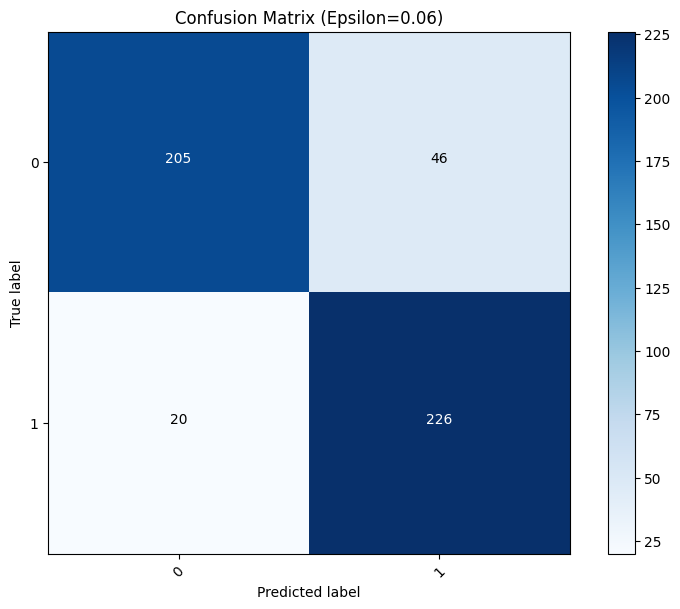

In [37]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.projected_gradient_descent import projected_gradient_descent
# Choose a batch size

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

batch_size = 20

# Define epsilon values
epsilon_values = [0.06]
#epsilon_values = [0.1]
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# List to store results for each epsilon
results_per_epsilon = []

for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  projected_gradient_descent(
            model_fn = resnet18,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/4,
            nb_iter=100,
            norm=np.inf,
            loss_fn=None,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=None,
            sanity_checks=False,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(resnet18.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })
    
    class_names =[0, 1]
    # Generate confusion matrix
    cm = confusion_matrix(y_test_one_hot.argmax(axis=1), y_pred_binary.argmax(axis=1))
    plt.figure()
    plot_confusion_matrix(cm, classes=class_names, title=f'Confusion Matrix (Epsilon={epsilon})')
    plt.savefig(f'UMAN_sars_cov2_pgd_confusion_matrix_epsilon_{epsilon}.png', dpi=1024)
    plt.savefig(f'UMAN_sars_cov2_pgd_confusion_matrix_epsilon_{epsilon}.pdf', dpi=1024)
    
# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


In [38]:
resnet18.evaluate(adversarial_examples_resnet, y_test_one_hot)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8766 - loss: 0.4186


[0.43340304493904114, 0.8672032356262207]

In [39]:
pred_adv = resnet18.predict(adversarial_examples)
pred_adv_resnet = resnet18_clean.predict(adversarial_examples_resnet)
pred_clean = resnet18.predict(images_test)
resnet18_clean_pred_clean = resnet18_clean.predict(images_test)

pred_adv.shape, pred_clean.shape, pred_adv_resnet.shape, resnet18_clean_pred_clean.shape

16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 797ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


((497, 2), (497, 2), (497, 2), (497, 2))

In [40]:

y_test_pred_adv = np.argmax(pred_adv, axis=1)
y_test_pred_adv_resnet = np.argmax(pred_adv_resnet, axis=1)
y_test_pred_clean = np.argmax(pred_clean, axis=1)
y_test_resnet18_clean_pred_clean = np.argmax(resnet18_clean_pred_clean, axis=1)

y_test_pred_adv.shape, y_test_pred_adv_resnet.shape,y_test_pred_clean.shape, y_test_resnet18_clean_pred_clean.shape

((497,), (497,), (497,), (497,))

In [41]:
adversarial_examples_resnet.shape

(497, 128, 128, 3)

In [67]:
random_indices = np.random.choice(497, 1, replace=False)
#adversarial_examples
X = images_test[random_indices]
adversarial_examples_X = adversarial_examples[random_indices]
adversarial_examples_resnet_X = adversarial_examples_resnet[random_indices]

y_test_one_hot1 = np.argmax(y_test_one_hot, axis=1)
y = y_test_one_hot1[random_indices]

y1 = y_test_pred_adv[random_indices]
y2 = y_test_pred_clean[random_indices]

y3 = y_test_pred_adv_resnet[random_indices]
y4 = y_test_resnet18_clean_pred_clean[random_indices]

X.shape, y.shape, adversarial_examples_X.shape, adversarial_examples_resnet_X.shape, y1.shape, y2.shape, y3.shape, y4.shape

((1, 128, 128, 3),
 (1,),
 (1, 128, 128, 3),
 (1, 128, 128, 3),
 (1,),
 (1,),
 (1,),
 (1,))

In [68]:
adversarial_examples_resnet_X.shape

(1, 128, 128, 3)

In [69]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(X)
grad_model = tf.keras.models.Model(
    resnet18.inputs, [resnet18.get_layer('trainable_combined_attention_layer_25').output, resnet18.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()


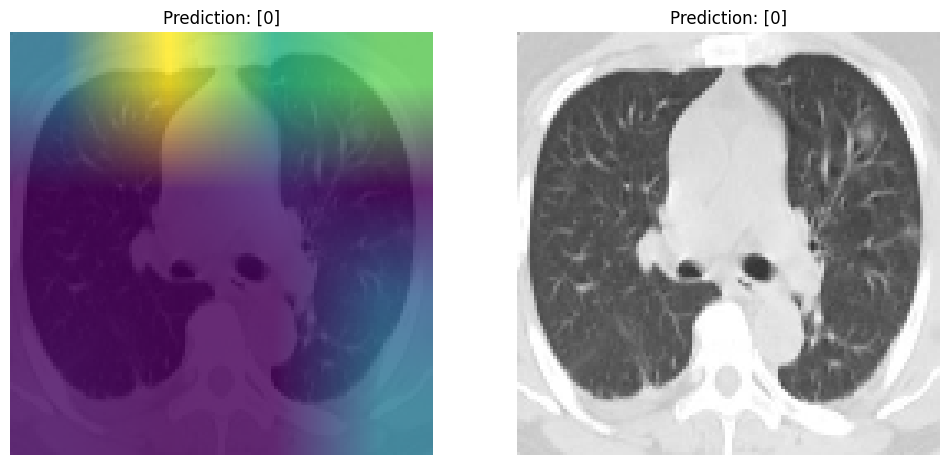

In [70]:


# Load the original image
import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Convert heatmap_rescaled to integers for indexing
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Index jet_colors using heatmap_indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, X.shape[1:3])
# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Ensure the superimposed image has the same shape as the original image
#superimposed_img_array = superimposed_img_array.numpy()#.astype(np.uint8)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y2}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

# Save the plot as PNG with DPI 1024
plt.savefig('clean_uman.png', dpi=1024)
plt.savefig('clean_uman.pdf', dpi=1024)

plt.show()

In [71]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(adversarial_examples_X)
grad_model = tf.keras.models.Model(
    resnet18.inputs, [resnet18.get_layer('trainable_combined_attention_layer_25').output, resnet18.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()


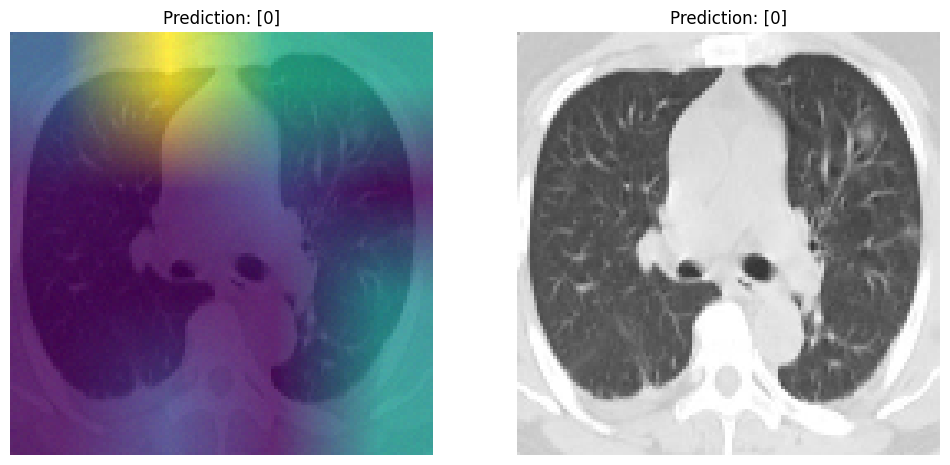

In [72]:

import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Convert heatmap_rescaled to integers for indexing
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Index jet_colors using heatmap_indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, adversarial_examples_X.shape[1:3])

# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(adversarial_examples_X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Ensure the superimposed image has the same shape as the original image
#superimposed_img_array = superimposed_img_array.numpy()#.astype(np.uint8)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y1}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

plt.savefig('pgd_denoised_uman.png', dpi=1024)
plt.savefig('pgd_denoised_uman.pdf', dpi=1024)

plt.show()

## resnet18 on adversarial examples and clean samples

In [130]:
resnet18_clean

<Functional name=functional_5, built=True>

In [86]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(X)
grad_model = tf.keras.models.Model(
    resnet18_clean.inputs, [resnet18_clean.get_layer('activation_17').output, 
                            resnet18_clean.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()


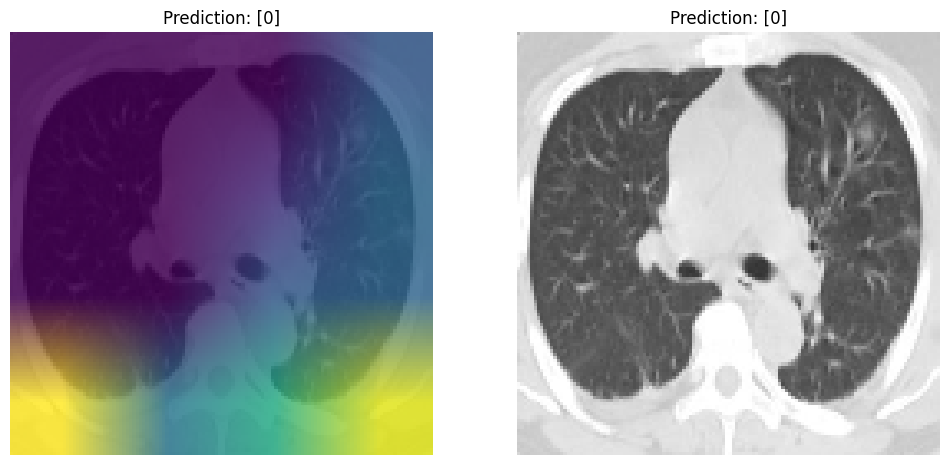

In [87]:

import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Round the rescaled heatmap to integer values
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Index jet_colors using rounded heatmap indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, X.shape[1:3])

# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y4}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

plt.savefig('clean_resnet18.png', dpi=1024)
plt.savefig('clean_resnet18.pdf', dpi=1024)

plt.show()


In [84]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(adversarial_examples_resnet_X)
grad_model = tf.keras.models.Model(
    resnet18_clean.inputs, [resnet18_clean.get_layer('activation_17').output, 
                            resnet18_clean.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()


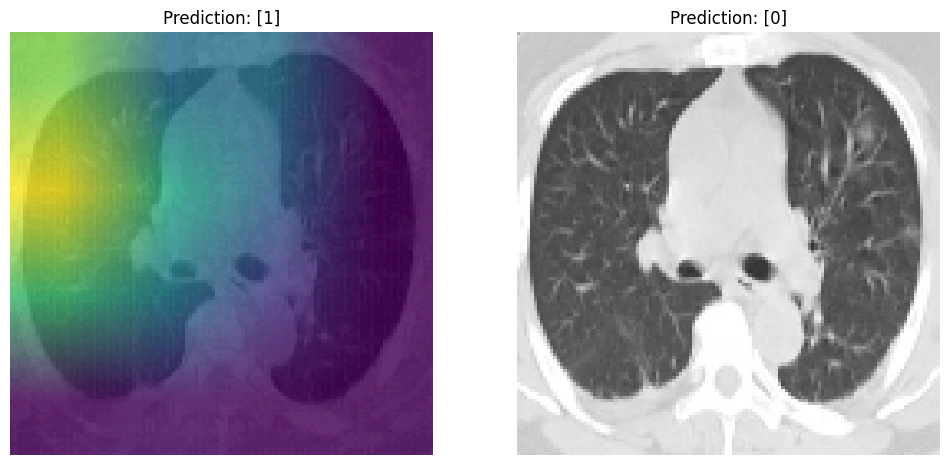

In [85]:

import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Round the rescaled heatmap to integer values
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Index jet_colors using rounded heatmap indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, adversarial_examples_resnet_X.shape[1:3])

# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(adversarial_examples_resnet_X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y3}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

plt.savefig('pgd_adv_resnet18.png', dpi=1024)
plt.savefig('pgd_adv_resnet18.pdf', dpi=1024)

plt.show()


In [88]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.momentum_iterative_method import momentum_iterative_method

# Choose a batch size
batch_size = 30

# Define epsilon values
epsilon_values = [0, 0.01,0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]
#epsilon_values = [0]
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# List to store results for each epsilon
results_per_epsilon = []
model = resnet18
for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        adv_batch = momentum_iterative_method(
            model_fn=resnet18,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/10,
            nb_iter=100,
            norm=np.inf,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            decay_factor=1.0,
            sanity_checks=True,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(resnet18.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Epsilon: 0
Accuracy: 89.93963782696177
Precision: 89.97910795841027
Recall: 90.1742993848257
F1 Score: 89.93046550829875
--------------------------------------------------
Epsilon: 0.01
Accuracy: 89.738430583501
Precision: 89.7718070806206
Recall: 89.90364304052517
F1 Score: 89.73244485852592
--------------------------------------------------
Epsilon: 0.02
Accuracy: 88.53118712273643
Precision: 88.56444142130664
Recall: 88.85626671886213
F1 Score: 88.61190031658414
------------------------------------

In [89]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.momentum_iterative_method import momentum_iterative_method

# Choose a batch size
batch_size = 30

# Define epsilon values
#epsilon_values = [0, 0.01,0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]
epsilon_values = [0.06]
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# List to store results for each epsilon
results_per_epsilon = []

for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        adv_batch = momentum_iterative_method(
            model_fn=resnet18,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/10,
            nb_iter=100,
            norm=np.inf,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            decay_factor=1.0,
            sanity_checks=True,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Epsilon: 0.06
Accuracy: 84.70824949698189
Precision: 84.9747352055194
Recall: 85.36205766710354
F1 Score: 84.77992979156363
--------------------------------------------------


In [90]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.momentum_iterative_method import momentum_iterative_method

# Choose a batch size
batch_size = 30

# Define epsilon values
#epsilon_values = [0, 0.01,0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]
epsilon_values = [0.06]
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# List to store results for each epsilon
results_per_epsilon = []
model = resnet18_clean
for epsilon in epsilon_values:
    adversarial_examples_resnet = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        adv_batch = momentum_iterative_method(
            model_fn=resnet18_clean,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/10,
            nb_iter=100,
            norm=np.inf,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            decay_factor=1.0,
            sanity_checks=True,
        )

        adversarial_examples_resnet.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples_resnet = np.concatenate(adversarial_examples_resnet, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples_resnet, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epsilon: 0.06
Accuracy: 23.943661971830984
Precision: 23.713276973407183
Recall: 16.940280267231547
F1 Score: 19.641207268247612
--------------------------------------------------


In [102]:
pred_adv = resnet18.predict(adversarial_examples)
pred_adv_resnet = resnet18_clean.predict(adversarial_examples_resnet)
pred_clean = resnet18.predict(images_test)
resnet18_clean_pred_clean = resnet18_clean.predict(images_test)

pred_adv.shape, pred_clean.shape, pred_adv_resnet.shape, resnet18_clean_pred_clean.shape
y_test_pred_adv = np.argmax(pred_adv, axis=1)
y_test_pred_adv_resnet = np.argmax(pred_adv_resnet, axis=1)
y_test_pred_clean = np.argmax(pred_clean, axis=1)
y_test_resnet18_clean_pred_clean = np.argmax(resnet18_clean_pred_clean, axis=1)

y_test_pred_adv.shape, y_test_pred_adv_resnet.shape,y_test_pred_clean.shape, y_test_resnet18_clean_pred_clean.shape

random_indices = np.random.choice(497, 1, replace=False)
#adversarial_examples
X = images_test[random_indices]
adversarial_examples_X = adversarial_examples[random_indices]
adversarial_examples_resnet_X = adversarial_examples_resnet[random_indices]

y_test_one_hot1 = np.argmax(y_test_one_hot, axis=1)
y = y_test_one_hot1[random_indices]

y1 = y_test_pred_adv[random_indices]
y2 = y_test_pred_clean[random_indices]

y3 = y_test_pred_adv_resnet[random_indices]
y4 = y_test_resnet18_clean_pred_clean[random_indices]

X.shape, y.shape, adversarial_examples_X.shape, adversarial_examples_resnet_X.shape, y1.shape, y2.shape, y3.shape, y4.shape

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


((1, 128, 128, 3),
 (1,),
 (1, 128, 128, 3),
 (1, 128, 128, 3),
 (1,),
 (1,),
 (1,),
 (1,))

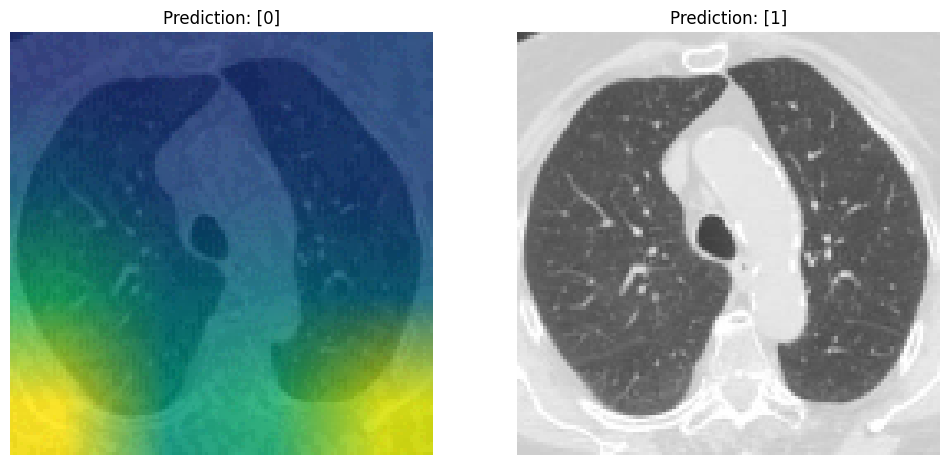

In [114]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(adversarial_examples_resnet_X)
grad_model = tf.keras.models.Model(
    resnet18_clean.inputs, [resnet18_clean.get_layer('activation_17').output, 
                            resnet18_clean.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Round the rescaled heatmap to integer values
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Index jet_colors using rounded heatmap indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, adversarial_examples_resnet_X.shape[1:3])

# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(adversarial_examples_resnet_X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y3}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

plt.savefig('mim_adv_resnet18.png', dpi=1024)
plt.savefig('mim_adv_resnet18.pdf', dpi=1024)

plt.show()


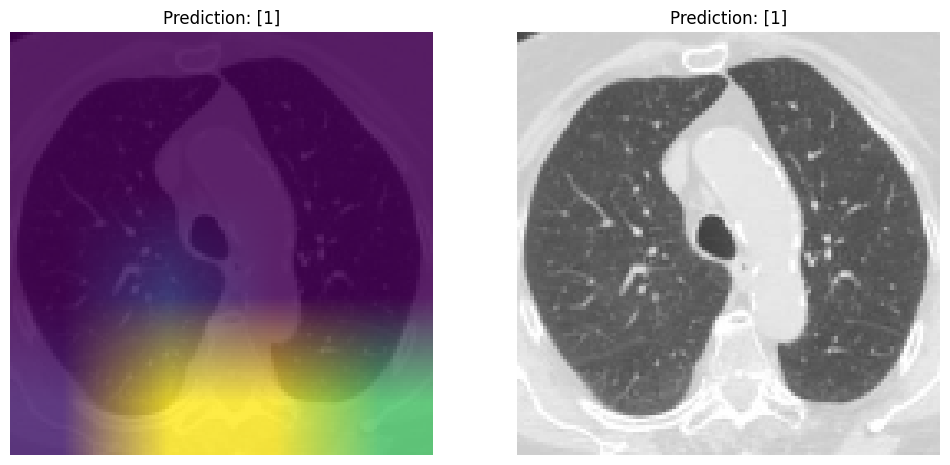

In [112]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(X)
grad_model = tf.keras.models.Model(
    resnet18_clean.inputs, [resnet18_clean.get_layer('conv2d_65').output, 
                            resnet18_clean.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Round the rescaled heatmap to integer values
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Index jet_colors using rounded heatmap indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, X.shape[1:3])

# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y4}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

plt.savefig('clean_resnet18_mim.png', dpi=1024)
plt.savefig('clean_resnet18_mim.pdf', dpi=1024)

plt.show()


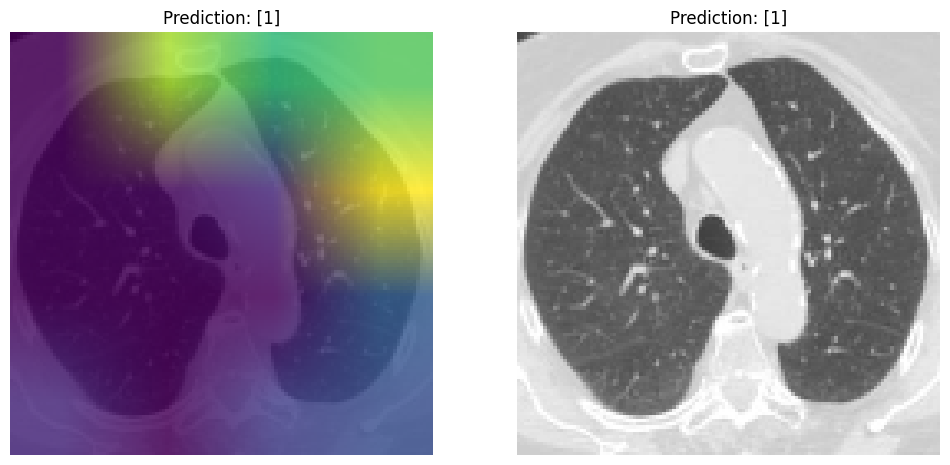

In [103]:

# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(X)
grad_model = tf.keras.models.Model(
    resnet18.inputs, [resnet18.get_layer('trainable_combined_attention_layer_25').output, resnet18.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

# Load the original image
import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Convert heatmap_rescaled to integers for indexing
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Index jet_colors using heatmap_indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, X.shape[1:3])
# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Ensure the superimposed image has the same shape as the original image
#superimposed_img_array = superimposed_img_array.numpy()#.astype(np.uint8)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y2}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

# Save the plot as PNG with DPI 1024
plt.savefig('clean_uman.png', dpi=1024)
plt.savefig('clean_uman.pdf', dpi=1024)

plt.show()

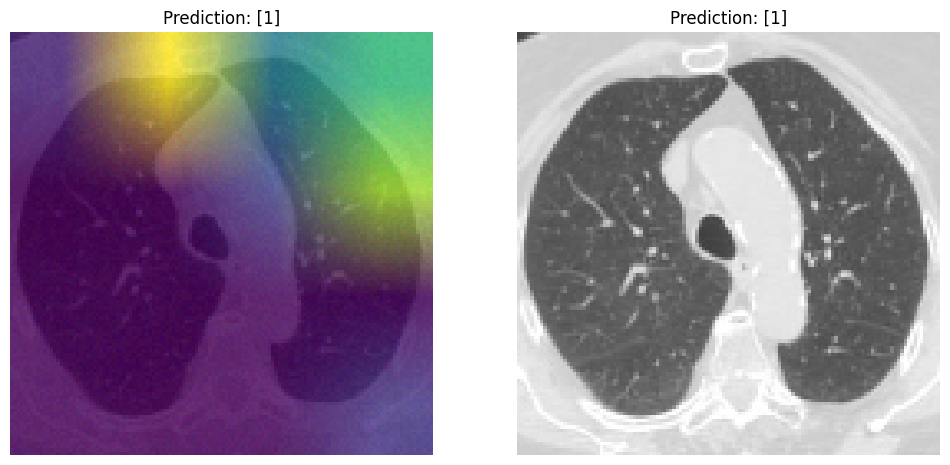

In [105]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(adversarial_examples_X)
grad_model = tf.keras.models.Model(
    resnet18.inputs, [resnet18.get_layer('trainable_combined_attention_layer_25').output, resnet18.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Convert heatmap_rescaled to integers for indexing
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Index jet_colors using heatmap_indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, adversarial_examples_X.shape[1:3])

# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(adversarial_examples_X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Ensure the superimposed image has the same shape as the original image
#superimposed_img_array = superimposed_img_array.numpy()#.astype(np.uint8)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y1}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

plt.savefig('mim_denoised_uman.png', dpi=1024)
plt.savefig('mim_denoised_uman.pdf', dpi=1024)

plt.show()

In [115]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.fast_gradient_method import fast_gradient_method
# Choose a batch size
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# Define epsilon values
epsilon_values = [0, 0.01,
                  
                  0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

# List to store results for each epsilon
results_per_epsilon = []
model = resnet18
for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        '''
        adv_batch = momentum_iterative_method(
            model_fn=model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/10,
            nb_iter=100,
            norm=np.inf,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            decay_factor=1.0,
            sanity_checks=True,
        )
        '''
        adv_batch =  fast_gradient_method(
            model_fn=model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            norm=np.inf,
            loss_fn=None,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            sanity_checks=False,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Epsilon: 0
Accuracy: 89.93963782696177
Precision: 89.99935218475692
Recall: 90.64664747017687
F1 Score: 90.00089462897296
--------------------------------------------------
Epsilon: 0.01
Accuracy: 87.92756539235413
Precision: 88.17008389207398
Recall: 88.22031148604802
F1 Score: 88.03036799145748
--------------------------------------------------
Epsilon: 0.02
Accuracy: 87.92756539235413
Precision: 87.96683185955365
Recall: 88.15219867851447
F1 Score: 87.9165586099585
--------------------------------------------------
Epsilon: 0.03
Accuracy: 91.54929577464789
Precision: 91.58

In [116]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.fast_gradient_method import fast_gradient_method
# Choose a batch size
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

# Define epsilon values
epsilon_values = [0, 0.01,
                  
                  0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

# List to store results for each epsilon
results_per_epsilon = []
model = resnet18_clean
for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        '''
        adv_batch = momentum_iterative_method(
            model_fn=model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/10,
            nb_iter=100,
            norm=np.inf,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            decay_factor=1.0,
            sanity_checks=True,
        )
        '''
        adv_batch =  fast_gradient_method(
            model_fn=model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            norm=np.inf,
            loss_fn=None,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            sanity_checks=False,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epsilon: 0
Accuracy: 97.78672032193158
Precision: 97.7885207138924
Recall: 97.78542510121457
F1 Score: 97.78657694752482
--------------------------------------------------
Epsilon: 0.01
Accuracy: 91.75050301810866
Precision: 91.7273993457066
Recall: 91.84667857722917
F1 Score: 91.74194437352332
--------------------------------------------------
Epsilon: 0.02
Accuracy: 77.46478873239437
Precision: 77.36533540634211
Recall: 78.54126549778724
F1 Score: 77.2055692055692
--------------------------------------------------
Epsilon: 0.03
Accuracy: 60.160965794768615
Precision: 60.165

In [118]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.basic_iterative_method import basic_iterative_method
# Choose a batch size
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

#adversarial_examples = []

# Define epsilon values
epsilon_values = [0, 0.01,
                  0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]

# List to store results for each epsilon
results_per_epsilon = []
model = resnet18
for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  basic_iterative_method(
            model_fn=model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/10,
            nb_iter=100,
            norm=np.inf,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=0.3,
            sanity_checks=True,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Epsilon: 0
Accuracy: 91.54929577464789
Precision: 91.58083114695688
Recall: 91.69969140815333
F1 Score: 91.54515407796248
--------------------------------------------------
Epsilon: 0.01
Accuracy: 88.73239436619718
Precision: 88.77579114436563
Recall: 89.01209020400182
F1 Score: 88.71919584954605
--------------------------------------------------
Epsilon: 0.02
Accuracy: 88.12877263581488
Precision: 88.17413273734331
Recall: 88.43181373508119
F1 Score: 88.11318077710439
--------------------------------

In [119]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.basic_iterative_method import basic_iterative_method
# Choose a batch size
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

#adversarial_examples = []

# Define epsilon values
epsilon_values = [0.06]

# List to store results for each epsilon
results_per_epsilon = []

for epsilon in epsilon_values:
    adversarial_examples = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  basic_iterative_method(
            model_fn=model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/10,
            nb_iter=100,
            norm=np.inf,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=0.3,
            sanity_checks=True,
        )

        adversarial_examples.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples = np.concatenate(adversarial_examples, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Epsilon: 0.06
Accuracy: 86.51911468812877
Precision: 86.56026301298868
Recall: 86.9172932330827
F1 Score: 86.59003053534305
--------------------------------------------------


In [121]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.basic_iterative_method import basic_iterative_method
# Choose a batch size
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

#adversarial_examples = []

# Define epsilon values
epsilon_values = [0, 0.01,
                  0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]

# List to store results for each epsilon
results_per_epsilon = []
model = resnet18_clean
for epsilon in epsilon_values:
    adversarial_examples_resnet = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  basic_iterative_method(
            model_fn=model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/10,
            nb_iter=100,
            norm=np.inf,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=0.3,
            sanity_checks=True,
        )

        adversarial_examples_resnet.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples_resnet = np.concatenate(adversarial_examples_resnet, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples_resnet, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epsilon: 0
Accuracy: 97.78672032193158
Precision: 97.7885207138924
Recall: 97.78542510121457
F1 Score: 97.78657694752482
--------------------------------------------------
Epsilon: 0.01
Accuracy: 91.14688128772636
Precision: 91.3289929712046
Recall: 91.21848739495799
F1 Score: 91.24710905532824
--------------------------------------------------
Epsilon: 0.02
Accuracy: 75.25150905432596
Precision: 75.15385612023451
Recall: 76.19051634008972
F1 Score: 74.97758948854914
----------------------------------

In [122]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from cleverhans.tf2.attacks.basic_iterative_method import basic_iterative_method
# Choose a batch size
batch_size = 20
num_samples = len(images_test)
num_batches = (num_samples + batch_size - 1) // batch_size

#adversarial_examples = []

# Define epsilon values
epsilon_values = [0.06]

# List to store results for each epsilon
results_per_epsilon = []
model = resnet18_clean
for epsilon in epsilon_values:
    adversarial_examples_resnet = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size if (i + 1) * batch_size < num_samples else num_samples

        # Generate adversarial examples for the current batch
        
        adv_batch =  basic_iterative_method(
            model_fn=model,
            x=images_test[start_idx:end_idx],
            eps=epsilon,
            eps_iter=epsilon/10,
            nb_iter=100,
            norm=np.inf,
            clip_min=None,
            clip_max=None,
            y=labels_test[start_idx:end_idx],
            targeted=False,
            rand_init=None,
            rand_minmax=0.3,
            sanity_checks=True,
        )

        adversarial_examples_resnet.append(adv_batch)

    # Concatenate the adversarial examples from all batches
    adversarial_examples_resnet = np.concatenate(adversarial_examples_resnet, axis=0)

    # Evaluate the model on the concatenated adversarial examples
    y_pred = tf.squeeze(model.predict(adversarial_examples_resnet, batch_size=128))
    y_pred_binary = y_pred >= 0.5
    y_pred_binary = np.array(y_pred_binary, dtype='int32')

    # Calculate evaluation metrics for the current epsilon
    accuracy = accuracy_score(y_pred_binary, y_test_one_hot) * 100
    precision = precision_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    recall = recall_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    f1 = f1_score(y_pred_binary, y_test_one_hot, average='macro') * 100
    #auc = roc_auc_score(y_pred, y_test_one_hot) * 100

    # Store results for the current epsilon
    results_per_epsilon.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        #'auc': auc
    })

# Print or use the results as needed
for result in results_per_epsilon:
    print(f"Epsilon: {result['epsilon']}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Precision: {result['precision']}")
    print(f"Recall: {result['recall']}")
    print(f"F1 Score: {result['f1']}")
    #print(f"AUC Score: {result['auc']}")
    print('-' * 50)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epsilon: 0.06
Accuracy: 24.346076458752517
Precision: 24.310886535160172
Recall: 17.2297851402329
F1 Score: 20.038510911424904
--------------------------------------------------


In [367]:
import os

# Specify the directory path
directory = '/kaggle/working'

# Get a list of all files and directories in the directory
files_and_dirs = os.listdir(directory)

# Iterate over each item and delete only files
for item in files_and_dirs:
    item_path = os.path.join(directory, item)
    if os.path.isfile(item_path):
        os.remove(item_path)

print("All files in the directory have been deleted.")


All files in the directory have been deleted.


In [214]:
pred_adv = resnet18.predict(adversarial_examples)
pred_adv_resnet = resnet18_clean.predict(adversarial_examples_resnet)
pred_clean = resnet18.predict(images_test)
resnet18_clean_pred_clean = resnet18_clean.predict(images_test)

pred_adv.shape, pred_clean.shape, pred_adv_resnet.shape, resnet18_clean_pred_clean.shape
y_test_pred_adv = np.argmax(pred_adv, axis=1)
y_test_pred_adv_resnet = np.argmax(pred_adv_resnet, axis=1)
y_test_pred_clean = np.argmax(pred_clean, axis=1)
y_test_resnet18_clean_pred_clean = np.argmax(resnet18_clean_pred_clean, axis=1)

y_test_pred_adv.shape, y_test_pred_adv_resnet.shape,y_test_pred_clean.shape, y_test_resnet18_clean_pred_clean.shape

random_indices = np.random.choice(600, 1, replace=False)
#adversarial_examples
X = images_test[random_indices]
adversarial_examples_X = adversarial_examples[random_indices]
adversarial_examples_resnet_X = adversarial_examples_resnet[random_indices]

y_test_one_hot1 = np.argmax(y_test_one_hot, axis=1)
y = y_test_one_hot1[random_indices]

y1 = y_test_pred_adv[random_indices]
y2 = y_test_pred_clean[random_indices]

y3 = y_test_pred_adv_resnet[random_indices]
y4 = y_test_resnet18_clean_pred_clean[random_indices]

X.shape, y.shape, adversarial_examples_X.shape, adversarial_examples_resnet_X.shape, y1.shape, y2.shape, y3.shape, y4.shape

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


((1, 128, 128, 3),
 (1,),
 (1, 128, 128, 3),
 (1, 128, 128, 3),
 (1,),
 (1,),
 (1,),
 (1,))

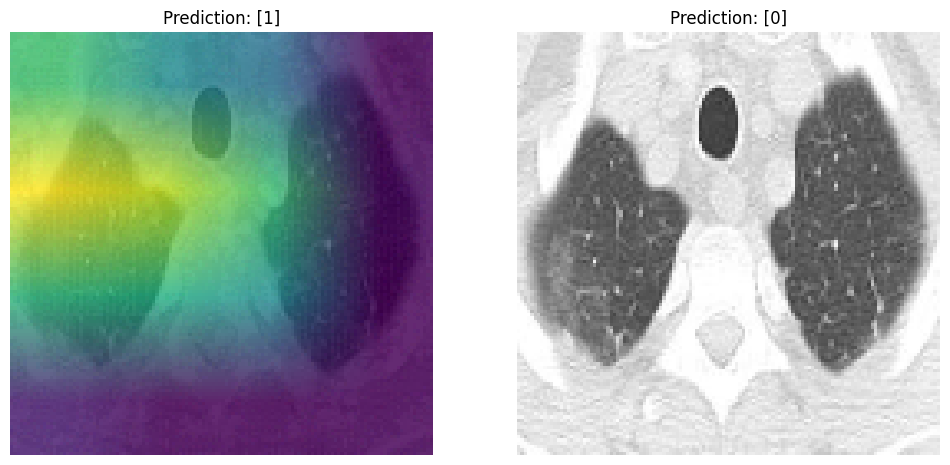

In [218]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(adversarial_examples_resnet_X)
grad_model = tf.keras.models.Model(
    resnet18_clean.inputs, [resnet18_clean.get_layer('conv2d_66').output, 
                            resnet18_clean.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Round the rescaled heatmap to integer values
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Index jet_colors using rounded heatmap indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, adversarial_examples_resnet_X.shape[1:3])

# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(adversarial_examples_resnet_X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y3}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

plt.savefig('bim_adv_resnet18.png', dpi=1024)
plt.savefig('bim_adv_resnet18.pdf', dpi=1024)

plt.show()


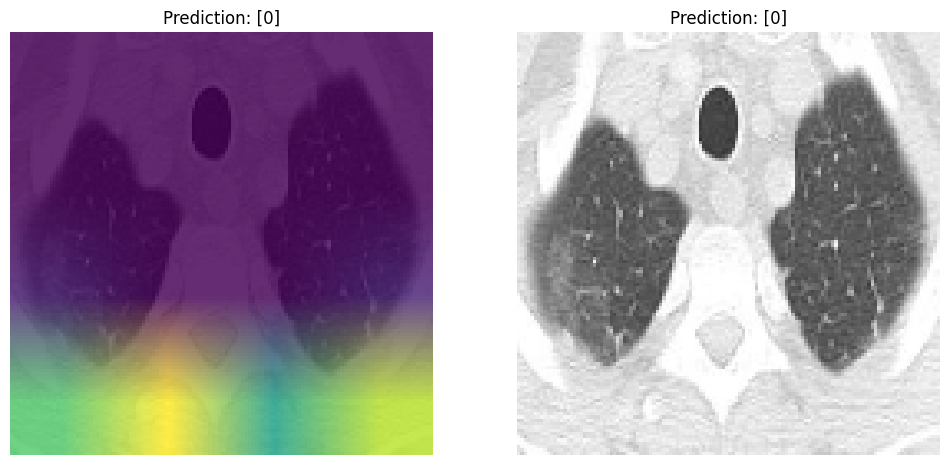

In [217]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(X)
grad_model = tf.keras.models.Model(
    resnet18_clean.inputs, [resnet18_clean.get_layer('conv2d_66').output, 
                            resnet18_clean.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Round the rescaled heatmap to integer values
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Index jet_colors using rounded heatmap indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, X.shape[1:3])

# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y4}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

plt.savefig('clean_resnet18_bim.png', dpi=1024)
plt.savefig('clean_resnet18_bim.pdf', dpi=1024)

plt.show()


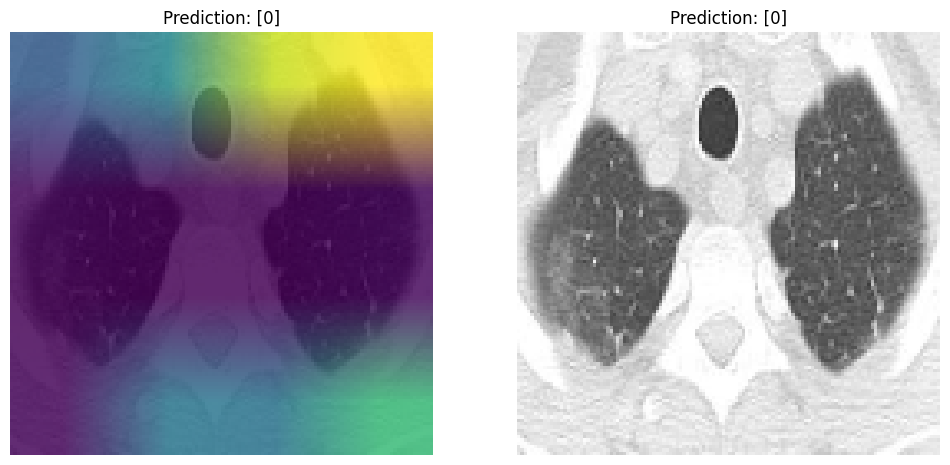

In [216]:

# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(X)
grad_model = tf.keras.models.Model(
    resnet18.inputs, [resnet18.get_layer('trainable_combined_attention_layer_25').output, resnet18.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

# Load the original image
import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Convert heatmap_rescaled to integers for indexing
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Index jet_colors using heatmap_indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, X.shape[1:3])
# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Ensure the superimposed image has the same shape as the original image
#superimposed_img_array = superimposed_img_array.numpy()#.astype(np.uint8)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y2}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

# Save the plot as PNG with DPI 1024
plt.savefig('clean_uman_bim.png', dpi=1024)
plt.savefig('clean_uman_bim.pdf', dpi=1024)

plt.show()

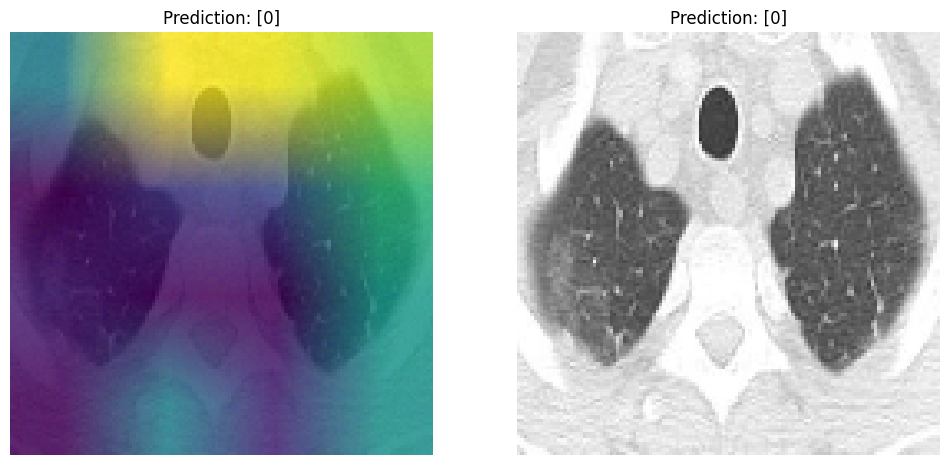

In [215]:
# First, we create a model that maps the input image to the activations
# of the last conv layer as well as the output predictions
X_tensor = tf.convert_to_tensor(adversarial_examples_X)
grad_model = tf.keras.models.Model(
    resnet18.inputs, [resnet18.get_layer('trainable_combined_attention_layer_25').output, resnet18.output]
)

# Then, we compute the gradient of the top predicted class for our input image
# with respect to the activations of the last conv layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(X_tensor)
    class_channel = preds[:, round(np.mean(tf.argmax(preds[0]).numpy()))]

# This is the gradient of the output neuron (top predicted or chosen)
# with regard to the output feature map of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# This is a vector where each entry is the mean intensity of the gradient
# over a specific feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the top predicted class
# then sum all the channels to obtain the heatmap class activation
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# For visualization purpose, we will also normalize the heatmap between 0 & 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

import matplotlib.cm as cm

# Rescale heatmap to a range 0-255
heatmap_rescaled = 255 * heatmap

# Use jet colormap to colorize heatmap
jet = cm.get_cmap("viridis")

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]

# Convert heatmap_rescaled to integers for indexing
heatmap_indices = np.round(heatmap_rescaled).astype(int)

# Index jet_colors using heatmap_indices
jet_heatmap = jet_colors[heatmap_indices]

# Resize the heatmap to match the original image size
heatmap_resized = tf.image.resize(jet_heatmap, adversarial_examples_X.shape[1:3])

# Convert the heatmap to an array
heatmap_array = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

# Convert X to a tensor
X_tensor = tf.convert_to_tensor(adversarial_examples_X, dtype=tf.float32)

# Normalize X_tensor to have values between 0 and 1
X_normalized = X_tensor / 255.0

# Blend the heatmap with the normalized original image
alpha = 0.8  # Adjust the transparency level
superimposed_img_array = (alpha * heatmap_array) + ((1 - alpha) * X_tensor)

# Ensure the superimposed image has the same shape as the original image
#superimposed_img_array = superimposed_img_array.numpy()#.astype(np.uint8)

# Convert the array back to an image
superimposed_img = tf.keras.preprocessing.image.array_to_img(tf.squeeze(superimposed_img_array))

# Plot the images
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(superimposed_img)
ax1.set_title(f'Prediction: {y1}')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(tf.squeeze(X))  # Squeeze the first dimension of X_tensor
ax2.set_title(f'Prediction: {y}')
ax2.axis('off')

plt.savefig('bim_denoised_uman.png', dpi=1024)
plt.savefig('bim_denoised_uman.pdf', dpi=1024)

plt.show()

In [28]:
import tensorflow as tf

# Load the model
loaded_model = tf.keras.models.load_model("your_model_name.tf")

# Now you can use the loaded model for inference or further training

In [35]:
import tensorflow as tf
loaded_model.save("resnet_train_sca_covid_ct1.h5")

In [21]:
loaded_model1 = tf.keras.models.load_model("resnet_train_sca_covid_ct1.h5", 
                                          custom_objects = {'TrainableCombinedAttentionLayer': TrainableCombinedAttentionLayer,
                                                            'CombinedAttentionNoiseLayer': CombinedAttentionNoiseLayer})

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'resnet_train_sca_covid_ct1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [20]:
loaded_model1.evaluate(images_test, y_test_one_hot)

NameError: name 'loaded_model1' is not defined

In [30]:
loaded_model.evaluate(images_test, y_test_one_hot)

16/16 [==============================] - 2s 31ms/step - loss: 0.4310 - accuracy: 0.8773


[0.4309694468975067, 0.877263605594635]

In [40]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

def residual_block(x, filters, strides=(1, 1), use_projection=False):
    shortcut = x

    # Define the first convolutional layer of the block
    x = Conv2D(filters=filters, kernel_size=(3, 3), strides=strides, padding='same', 
               activation = 'relu')(x)
    x = BatchNormalization()(x)
    #x = Activation('relu')(x)

    # Define the second convolutional layer of the block
    x = Conv2D(filters=filters, kernel_size=(3, 3), padding='same')(x)
    x = BatchNormalization()(x)

    # If the stride is not (1, 1), the dimensions need to be adjusted
    if strides != (1, 1) or use_projection:
        
        shortcut = Conv2D(filters=filters, kernel_size=(1, 1), strides=strides, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Add the shortcut (identity connection)
    
    x = tf.keras.layers.add([x, shortcut])
    
    x = Activation('relu')(x)
    return x

def build_resnet18(input_shape=(128, 128, 3), num_classes=2):
    inputs = Input(shape=input_shape)
    #input_data = Input(shape=input_shape, name='input_data')
    # Initial convolutional layer
    
    
    x = Conv2D(filters=64, kernel_size=(7, 7), strides=(2, 2), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)

    # Stack of residual blocks
    x = residual_block(x, filters=64)
    
    x = residual_block(x, filters=64)
    
    x = residual_block(x, filters=128, strides=(2, 2), use_projection=True)

    x = residual_block(x, filters=128)
    
    x = residual_block(x, filters=256, strides=(2, 2), use_projection=True)
    
    x = residual_block(x, filters=256)
    
    x = residual_block(x, filters=512, strides=(2, 2), use_projection=True)
    
    x = residual_block(x, filters=512)
    
    
    # Global average pooling and fully connected layer
    x = GlobalAveragePooling2D()(x)
    ##x = Dense(128, activation='selu')(x)
    outputs = Dense(2, activation='sigmoid')(x)

    # Create the model
    model = Model(inputs, outputs)
    return model

# Instantiate the ResNet-18 model
resnet18_clean = build_resnet18()

# Display the model summary
#resnet18.summary()
resnet18_clean.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
resnet18_clean.fit(images_train, y_train_one_hot, epochs=100, verbose=0, #callbacks = callbacks,
          validation_split=0.2)

In [43]:
resnet18_clean.fit(images_train, y_train_one_hot, epochs=100, verbose=0, #callbacks = callbacks,
          validation_split=0.2)

In [48]:
resnet18_clean.evaluate(images_test, y_test_one_hot)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9874 - loss: 0.0866


[0.06501815468072891, 0.9866666793823242]